In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
# Load
df = pd.read_csv('/kaggle/input/e-commerce-review-preprocessed/phase2_annotated_preprocessed_final.csv')

In [2]:
# CELL A — GridSearch per-aspect + combined (stacked) with full-metrics display and CSV outputs
import os, json, numpy as np, pandas as pd, ast
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, KFold, train_test_split
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, average_precision_score

# ========== CONFIG ==========
OUT_DIR = "/kaggle/working/gridsearch_results_tf-idf"
os.makedirs(OUT_DIR, exist_ok=True)

ASPECTS = ['Aplikasi','Pengiriman','Produk','Harga','Pembayaran','Layanan Pelanggan (CS)','Penjual']
TEXT_COL = 'content'
TEST_SIZE = 0.2
CV_FOLDS_DESIRED = 5
RANDOM_STATE = 42
N_JOBS = -1

TFIDF_PARAM_GRID = {
    'tfidf__max_features': [50, 100, 150, 200],
    'tfidf__ngram_range': [(1,1), (1,2), (1,3), (1,4)],
    'tfidf__min_df': [1,2,3],
    'tfidf__max_df': [0.70, 0.75, 0.80, 0.85, 0.90, 0.95],
    'clf__C': [0.01, 0.1, 1.0, 10.0],
    'clf__class_weight': ['balanced']
}

# scoring dict
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

# ========== HELPERS ==========
def safe_n_splits_for_counts(vc, desired):
    min_count = int(vc.min())
    if min_count < 2:
        return None
    return min(desired, min_count)

def build_cv_splits(X_train, y_train, aspect_train=None, desired=CV_FOLDS_DESIRED, random_state=RANDOM_STATE):
    """
    Prefer stratify by aspect|label (if feasible), else stratify by label, else KFold.
    Returns either an iterable of (train_idx, val_idx) or a splitter object.
    """
    # try aspect|label strata if aspect_train provided
    if aspect_train is not None:
        strata = np.array([f"{a}|{lab}" for a, lab in zip(aspect_train, y_train)])
        vc = pd.Series(strata).value_counts()
        n_splits = safe_n_splits_for_counts(vc, desired)
        if n_splits is not None:
            skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
            return list(skf.split(np.zeros(len(strata)), strata))
    # fallback stratify by label
    vc_lab = pd.Series(y_train).value_counts()
    n_splits_lab = safe_n_splits_for_counts(vc_lab, desired)
    if n_splits_lab is not None:
        return StratifiedKFold(n_splits=n_splits_lab, shuffle=True, random_state=random_state)
    # final fallback to KFold
    k = min(desired, max(2, len(X_train)))
    return KFold(n_splits=k, shuffle=True, random_state=random_state)

def rank_by_composite(res_df, metrics=['mean_test_accuracy','mean_test_precision','mean_test_recall','mean_test_f1','mean_test_roc_auc','mean_test_pr_auc']):
    df = res_df.copy()
    # ensure metric columns exist
    for m in metrics:
        if m not in df.columns:
            df[m] = np.nan
    # fill NaN with 0 for composite sum (policy: missing => 0). Adjust if you prefer penalizing.
    df['_composite_sum'] = df[metrics].fillna(0.0).sum(axis=1)
    df_sorted = df.sort_values('_composite_sum', ascending=False).reset_index(drop=True)
    return df_sorted

def safe_eval_params(s):
    try:
        return ast.literal_eval(s) if isinstance(s, str) else s
    except Exception:
        try:
            return eval(s)
        except Exception:
            return {}

# ========== CORE: per-aspect GridSearch ==========
summary = {}
# We'll also collect per-aspect train/hold splits to build COMBINED from train-only parts later
combined_train_parts_X = []
combined_train_parts_y = []
combined_train_parts_aspect = []
combined_hold_parts_X = []
combined_hold_parts_y = []
combined_hold_parts_aspect = []

for aspect in ASPECTS:
    print("\n" + "="*80)
    print("GRIDSEARCH — Aspect:", aspect)
    print("="*80)
    if aspect not in df.columns:
        print("  SKIP: aspect column not found")
        continue

    ser = df[aspect].map(lambda x: 'P' if str(x).strip().upper()=='P' else ('N' if str(x).strip().upper()=='N' else None))
    mask = ser.notna()
    X_all = df.loc[mask, TEXT_COL].fillna('').astype(str).values
    y_all = ser[mask].map({'P':1,'N':0}).astype(int).values
    n_total = len(y_all)
    if n_total < 10:
        print("  Too few samples; skipping")
        continue

    # IMPORTANT CHANGE: split per-aspect stratified BY LABEL (P/N) not by aspect
    try:
        X_train, X_hold, y_train, y_hold = train_test_split(X_all, y_all,
                                                            test_size=TEST_SIZE,
                                                            stratify=y_all,    # <<-- stratify by label P/N
                                                            random_state=RANDOM_STATE)
    except Exception:
        X_train, X_hold, y_train, y_hold = train_test_split(X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE)

    print(f"  Samples: {n_total}  Train: {len(y_train)}  Held-out test: {len(y_hold)}")

    # store parts for later combined building
    combined_train_parts_X.append(X_train)
    combined_train_parts_y.append(y_train)
    combined_train_parts_aspect.append(np.array([aspect]*len(y_train)))
    combined_hold_parts_X.append(X_hold)
    combined_hold_parts_y.append(y_hold)
    combined_hold_parts_aspect.append(np.array([aspect]*len(y_hold)))

    # pipeline
    pipe = Pipeline([('tfidf', TfidfVectorizer(norm='l2')), ('clf', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE))])

    # build CV splits (per-aspect run: aspect_train is None because all rows same aspect)
    cv_to_use = build_cv_splits(X_train, y_train, aspect_train=None, desired=CV_FOLDS_DESIRED, random_state=RANDOM_STATE)

    print("  Running GridSearchCV ...")
    gs = GridSearchCV(pipe, TFIDF_PARAM_GRID, scoring=scoring, refit='f1',
                      cv=cv_to_use, n_jobs=N_JOBS, verbose=1, return_train_score=True)
    gs.fit(X_train, y_train)

    res_df = pd.DataFrame(gs.cv_results_)
    out_csv = os.path.join(OUT_DIR, f"{aspect}_grid_cv_results.csv")
    res_df.to_csv(out_csv, index=False)
    print("  Saved CV results to:", out_csv)

    # rank by composite but show all metrics
    ranked = rank_by_composite(res_df)
    ranked_path = os.path.join(OUT_DIR, f"{aspect}_grid_ranked_by_composite.csv")
    ranked.to_csv(ranked_path, index=False)
    print("  Saved ranked-by-composite CSV to:", ranked_path)

    # Display top-10 with full metric columns for easy inspection
    display_cols = [c for c in ranked.columns if c.startswith('mean_test_') or c.startswith('std_test_') or c in ['rank_test_f1','params','_composite_sum']]
    print(f"  Top 10 candidate rows for aspect '{aspect}' :")
    display(ranked[display_cols].head(10))

    # keep best-by-f1 to summary
    summary[aspect] = {
        'best_by_f1': gs.best_params_,
        'best_index': gs.best_index_
    }

# ========== COMBINED (STACKED) GRIDSEARCH ==========
print("\n" + "="*80)
print("GRIDSEARCH — COMBINED (stacked across aspects) USING ONLY PER-ASPECT TRAIN PARTS")
print("="*80)

# build combined datasets FROM per-aspect TRAIN parts only, and holdout from per-aspect holdouts
if len(combined_train_parts_X) == 0:
    raise RuntimeError("No aspect train parts collected; ensure earlier per-aspect loops ran correctly.")

X_train_comb = np.concatenate(combined_train_parts_X)
y_train_comb = np.concatenate(combined_train_parts_y)
aspect_train_comb = np.concatenate(combined_train_parts_aspect)

X_hold_comb = np.concatenate(combined_hold_parts_X)
y_hold_comb = np.concatenate(combined_hold_parts_y)
aspect_hold_comb = np.concatenate(combined_hold_parts_aspect)

# For top-level printing, also compute totals (all data)
total_all = sum([len(arr) for arr in combined_train_parts_X]) + sum([len(arr) for arr in combined_hold_parts_X])
print(f"  COMBINED dataset (all aspects summed): Samples: {total_all}  (train parts + holdout parts)")
print(f"    Combined TRAIN (sum of per-aspect trains): {len(X_train_comb)}")
print(f"    Combined HOLDOUT (sum of per-aspect holdouts): {len(X_hold_comb)}")
print(f"    Confirm sum: {len(X_train_comb)+len(X_hold_comb)} samples")

# Now run GridSearch on X_train_comb with CV built to preserve aspect+label strata if possible
cv_to_use_comb = build_cv_splits(X_train_comb, y_train_comb, aspect_train=None, desired=CV_FOLDS_DESIRED, random_state=RANDOM_STATE)

pipe = Pipeline([('tfidf', TfidfVectorizer(norm='l2')), ('clf', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE))])
print("  Running GridSearchCV on combined (TRAIN parts only)...")
gs_comb = GridSearchCV(pipe, TFIDF_PARAM_GRID, scoring=scoring, refit='f1', cv=cv_to_use_comb, n_jobs=N_JOBS, verbose=1, return_train_score=True)
gs_comb.fit(X_train_comb, y_train_comb)

res_df_comb = pd.DataFrame(gs_comb.cv_results_)
combined_out = os.path.join(OUT_DIR, "COMBINED_grid_cv_results.csv")
res_df_comb.to_csv(combined_out, index=False)
print("  Saved combined grid results to:", combined_out)

ranked_combined = rank_by_composite(res_df_comb)
ranked_combined_path = os.path.join(OUT_DIR, "COMBINED_grid_ranked_by_composite.csv")
ranked_combined.to_csv(ranked_combined_path, index=False)
print("  Saved combined ranked-by-composite CSV to:", ranked_combined_path)

# Display combined top rows with full metrics
display_cols = [c for c in ranked_combined.columns if c.startswith('mean_test_') or c.startswith('std_test_') or c in ['rank_test_f1','params','_composite_sum']]
print("  Top 15 candidate rows for COMBINED:")
display(ranked_combined[display_cols].head(15))

# Save lightweight summary CSV listing best_by_f1 per aspect
summary_rows = []
for asp, v in summary.items():
    summary_rows.append({'aspect': asp, 'best_by_f1': str(v['best_by_f1']), 'best_index': v['best_index']})
pd.DataFrame(summary_rows).to_csv(os.path.join(OUT_DIR, "per_aspect_best_by_f1_summary.csv"), index=False)
print("Per-aspect best-by-f1 summary saved to:", os.path.join(OUT_DIR, "per_aspect_best_by_f1_summary.csv"))

print("\nGridSearch finished. All CSVs saved to:", OUT_DIR)


GRIDSEARCH — Aspect: Aplikasi
  Samples: 455  Train: 364  Held-out test: 91
  Running GridSearchCV ...
Fitting 5 folds for each of 1152 candidates, totalling 5760 fits
  Saved CV results to: /kaggle/working/gridsearch_results_tf-idf/Aplikasi_grid_cv_results.csv
  Saved ranked-by-composite CSV to: /kaggle/working/gridsearch_results_tf-idf/Aplikasi_grid_ranked_by_composite.csv
  Top 10 candidate rows for aspect 'Aplikasi' :


,params,mean_test_accuracy,std_test_accuracy,mean_test_precision,std_test_precision,mean_test_recall,std_test_recall,mean_test_f1,std_test_f1,rank_test_f1,mean_test_roc_auc,std_test_roc_auc,mean_test_pr_auc,std_test_pr_auc,_composite_sum
0,"{'clf__C': 10.0, 'clf__class_weight': 'balance...",0.898402,0.010562,0.941897,0.009916,0.897502,0.015539,0.919053,0.008619,1,0.959941,0.014220,0.977840,0.007991,5.594634
1,"{'clf__C': 10.0, 'clf__class_weight': 'balance...",0.898402,0.010562,0.941897,0.009916,0.897502,0.015539,0.919053,0.008619,1,0.959941,0.014220,0.977840,0.007991,5.594634
2,"{'clf__C': 10.0, 'clf__class_weight': 'balance...",0.898402,0.010562,0.941897,0.009916,0.897502,0.015539,0.919053,0.008619,1,0.959941,0.014220,0.977840,0.007991,5.594634
3,"{'clf__C': 10.0, 'clf__class_weight': 'balance...",0.898402,0.010562,0.941897,0.009916,0.897502,0.015539,0.919053,0.008619,1,0.959941,0.014220,0.977840,0.007991,5.594634
4,"{'clf__C': 10.0, 'clf__class_weight': 'balance...",0.898402,0.010562,0.941897,0.009916,0.897502,0.015539,0.919053,0.008619,1,0.959941,0.014220,0.977840,0.007991,5.594634
5,"{'clf__C': 10.0, 'clf__class_weight': 'balance...",0.898402,0.010562,0.941897,0.009916,0.897502,0.015539,0.919053,0.008619,1,0.959941,0.014220,0.977840,0.007991,5.594634
6,"{'clf__C': 10.0, 'clf__class_weight': 'balance...",0.898402,0.016176,0.941871,0.010021,0.897502,0.024569,0.918951,0.013553,7,0.958966,0.013364,0.977289,0.007534,5.592981
7,"{'clf__C': 10.0, 'clf__class_weight': 'balance...",0.898402,0.016176,0.941871,0.010021,0.897502,0.024569,0.918951,0.013553,7,0.958966,0.013364,0.977289,0.007534,5.592981
8,"{'clf__C': 10.0, 'clf__class_weight': 'balance...",0.898402,0.016176,0.941871,0.010021,0.897502,0.024569,0.918951,0.013553,7,0.958966,0.013364,0.977289,0.007534,5.592981
9,"{'clf__C': 10.0, 'clf__class_weight': 'balance...",0.898402,0.016176,0.941871,0.010021,0.897502,0.024569,0.918951,0.013553,7,0.958966,0.013364,0.977289,0.007534,5.592981



GRIDSEARCH — Aspect: Pengiriman
  Samples: 222  Train: 177  Held-out test: 45
  Running GridSearchCV ...
Fitting 5 folds for each of 1152 candidates, totalling 5760 fits
  Saved CV results to: /kaggle/working/gridsearch_results_tf-idf/Pengiriman_grid_cv_results.csv
  Saved ranked-by-composite CSV to: /kaggle/working/gridsearch_results_tf-idf/Pengiriman_grid_ranked_by_composite.csv
  Top 10 candidate rows for aspect 'Pengiriman' :


,params,mean_test_accuracy,std_test_accuracy,mean_test_precision,std_test_precision,mean_test_recall,std_test_recall,mean_test_f1,std_test_f1,rank_test_f1,mean_test_roc_auc,std_test_roc_auc,mean_test_pr_auc,std_test_pr_auc,_composite_sum
0,"{'clf__C': 10.0, 'clf__class_weight': 'balance...",0.937778,0.021145,0.963137,0.047939,0.894167,0.053980,0.925080,0.025616,1,0.968542,0.030991,0.972038,0.023803,5.660742
1,"{'clf__C': 10.0, 'clf__class_weight': 'balance...",0.937778,0.021145,0.963137,0.047939,0.894167,0.053980,0.925080,0.025616,1,0.968542,0.030991,0.972038,0.023803,5.660742
2,"{'clf__C': 10.0, 'clf__class_weight': 'balance...",0.937778,0.021145,0.963137,0.047939,0.894167,0.053980,0.925080,0.025616,1,0.968542,0.030991,0.972038,0.023803,5.660742
3,"{'clf__C': 10.0, 'clf__class_weight': 'balance...",0.937778,0.021145,0.963137,0.047939,0.894167,0.053980,0.925080,0.025616,1,0.968542,0.030991,0.972038,0.023803,5.660742
4,"{'clf__C': 10.0, 'clf__class_weight': 'balance...",0.937778,0.021145,0.963137,0.047939,0.894167,0.053980,0.925080,0.025616,1,0.968542,0.030991,0.972038,0.023803,5.660742
5,"{'clf__C': 10.0, 'clf__class_weight': 'balance...",0.937778,0.021145,0.963137,0.047939,0.894167,0.053980,0.925080,0.025616,1,0.968542,0.030991,0.972038,0.023803,5.660742
6,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.932063,0.038021,0.953333,0.065320,0.894167,0.080433,0.918693,0.044547,25,0.969792,0.026021,0.973041,0.018832,5.641089
7,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.932063,0.038021,0.953333,0.065320,0.894167,0.080433,0.918693,0.044547,25,0.969792,0.026021,0.973041,0.018832,5.641089
8,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.932063,0.038021,0.953333,0.065320,0.894167,0.080433,0.918693,0.044547,25,0.969792,0.026021,0.973041,0.018832,5.641089
9,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.932063,0.038021,0.953333,0.065320,0.894167,0.080433,0.918693,0.044547,25,0.969792,0.026021,0.973041,0.018832,5.641089



GRIDSEARCH — Aspect: Produk
  Samples: 135  Train: 108  Held-out test: 27
  Running GridSearchCV ...
Fitting 5 folds for each of 1152 candidates, totalling 5760 fits
  Saved CV results to: /kaggle/working/gridsearch_results_tf-idf/Produk_grid_cv_results.csv
  Saved ranked-by-composite CSV to: /kaggle/working/gridsearch_results_tf-idf/Produk_grid_ranked_by_composite.csv
  Top 10 candidate rows for aspect 'Produk' :


...


GRIDSEARCH — Aspect: Penjual
  Samples: 52  Train: 41  Held-out test: 11
  Running GridSearchCV ...
Fitting 5 folds for each of 1152 candidates, totalling 5760 fits
  Saved CV results to: /kaggle/working/gridsearch_results_tf-idf/Penjual_grid_cv_results.csv
  Saved ranked-by-composite CSV to: /kaggle/working/gridsearch_results_tf-idf/Penjual_grid_ranked_by_composite.csv
  Top 10 candidate rows for aspect 'Penjual' :


,params,mean_test_accuracy,std_test_accuracy,mean_test_precision,std_test_precision,mean_test_recall,std_test_recall,mean_test_f1,std_test_f1,rank_test_f1,mean_test_roc_auc,std_test_roc_auc,mean_test_pr_auc,std_test_pr_auc,_composite_sum
0,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.830556,0.096385,0.4,0.374166,0.5,0.447214,0.433333,0.38873,85,0.880952,0.159186,0.798333,0.248126,3.843175
1,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.830556,0.096385,0.4,0.374166,0.5,0.447214,0.433333,0.38873,85,0.880952,0.159186,0.798333,0.248126,3.843175
2,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.830556,0.096385,0.4,0.374166,0.5,0.447214,0.433333,0.38873,85,0.880952,0.159186,0.798333,0.248126,3.843175
3,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.830556,0.096385,0.4,0.374166,0.5,0.447214,0.433333,0.38873,85,0.880952,0.159186,0.798333,0.248126,3.843175
4,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.830556,0.096385,0.4,0.374166,0.5,0.447214,0.433333,0.38873,85,0.880952,0.159186,0.798333,0.248126,3.843175
5,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.830556,0.096385,0.4,0.374166,0.5,0.447214,0.433333,0.38873,85,0.880952,0.159186,0.798333,0.248126,3.843175
6,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.830556,0.096385,0.4,0.374166,0.5,0.447214,0.433333,0.38873,85,0.880952,0.159186,0.798333,0.248126,3.843175
7,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.830556,0.096385,0.4,0.374166,0.5,0.447214,0.433333,0.38873,85,0.880952,0.159186,0.798333,0.248126,3.843175
8,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.830556,0.096385,0.4,0.374166,0.5,0.447214,0.433333,0.38873,85,0.880952,0.159186,0.798333,0.248126,3.843175
9,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.830556,0.096385,0.4,0.374166,0.5,0.447214,0.433333,0.38873,85,0.880952,0.159186,0.798333,0.248126,3.843175



GRIDSEARCH — COMBINED (stacked across aspects) USING ONLY PER-ASPECT TRAIN PARTS
  COMBINED dataset (all aspects summed): Samples: 1304  (train parts + holdout parts)
    Combined TRAIN (sum of per-aspect trains): 1041
    Combined HOLDOUT (sum of per-aspect holdouts): 263
    Confirm sum: 1304 samples
  Running GridSearchCV on combined (TRAIN parts only)...
Fitting 5 folds for each of 1152 candidates, totalling 5760 fits
  Saved combined grid results to: /kaggle/working/gridsearch_results_tf-idf/COMBINED_grid_cv_results.csv
  Saved combined ranked-by-composite CSV to: /kaggle/working/gridsearch_results_tf-idf/COMBINED_grid_ranked_by_composite.csv
  Top 15 candidate rows for COMBINED:


,params,mean_test_accuracy,std_test_accuracy,mean_test_precision,std_test_precision,mean_test_recall,std_test_recall,mean_test_f1,std_test_f1,rank_test_f1,mean_test_roc_auc,std_test_roc_auc,mean_test_pr_auc,std_test_pr_auc,_composite_sum
0,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.882835,0.017893,0.933425,0.021261,0.882963,0.029407,0.907013,0.015151,1,0.947456,0.010124,0.970905,0.005415,5.524597
1,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.882835,0.017893,0.933425,0.021261,0.882963,0.029407,0.907013,0.015151,1,0.947456,0.010124,0.970905,0.005415,5.524597
2,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.882835,0.017893,0.933425,0.021261,0.882963,0.029407,0.907013,0.015151,1,0.947456,0.010124,0.970905,0.005415,5.524597
3,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.882835,0.017893,0.933425,0.021261,0.882963,0.029407,0.907013,0.015151,1,0.947456,0.010124,0.970905,0.005415,5.524597
4,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.882835,0.017893,0.933425,0.021261,0.882963,0.029407,0.907013,0.015151,1,0.947456,0.010124,0.970905,0.005415,5.524597
5,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.882835,0.017893,0.933425,0.021261,0.882963,0.029407,0.907013,0.015151,1,0.947456,0.010124,0.970905,0.005415,5.524597
6,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.880912,0.017596,0.925062,0.017269,0.888889,0.032118,0.906132,0.015196,13,0.948742,0.011551,0.971769,0.007179,5.521506
7,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.880912,0.017596,0.925062,0.017269,0.888889,0.032118,0.906132,0.015196,13,0.948742,0.011551,0.971769,0.007179,5.521506
8,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.880912,0.017596,0.925062,0.017269,0.888889,0.032118,0.906132,0.015196,13,0.948742,0.011551,0.971769,0.007179,5.521506
9,"{'clf__C': 1.0, 'clf__class_weight': 'balanced...",0.880912,0.017596,0.925062,0.017269,0.888889,0.032118,0.906132,0.015196,13,0.948742,0.011551,0.971769,0.007179,5.521506


Per-aspect best-by-f1 summary saved to: /kaggle/working/gridsearch_results_tf-idf/per_aspect_best_by_f1_summary.csv

GridSearch finished. All CSVs saved to: /kaggle/working/gridsearch_results_tf-idf


In [ ]:
# CELL C (FINALIZED) — Full CV debug matching Cell A splitting & parameter choices
import os, ast, json
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, KFold, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix)

# ---------------- CONFIG (match Cell A) ----------------
OUT_DIR = "/kaggle/working/gridsearch_results_tf-idf"   # where Cell A saved CSVs
CV_OUT_DIR = "/kaggle/working/cv_debug_final"
os.makedirs(CV_OUT_DIR, exist_ok=True)

ASPECTS = ['Aplikasi','Pengiriman','Produk','Harga','Pembayaran','Layanan Pelanggan (CS)','Penjual']
TEXT_COL = 'content'
TEST_SIZE = 0.2
CV_FOLDS_DESIRED = 5
RANDOM_STATE = 42
# ---------------- load grid-results folder (Cell A outputs) ----------------
ASPECT_CSV_DIR = OUT_DIR  # path where Cell A saved CSV files, e.g. "Aplikasi_grid_cv_results.csv" etc.
COMBINED_CV_RESULTS = os.path.join(ASPECT_CSV_DIR, "COMBINED_grid_cv_results.csv")

def safe_load_best_params_from_cv_results(path_csv):
    # baca csv (asumsi kolom yang diperlukan ada)
    df = pd.read_csv(path_csv)

    # helper internal: konversi aman ke numeric
    def numeric_col(s):
        return pd.to_numeric(s, errors='coerce')

    # ambil kandidat rank_test_f1 == 1
    candidates = df[numeric_col(df['rank_test_f1']) == 1].copy()

    # jika lebih dari satu kandidat, tie-break
    if len(candidates) > 1:
        cur = candidates
        for col in ('mean_test_roc_auc', 'mean_test_pr_auc'):
            vals = numeric_col(cur[col])
            best_val = vals.max()
            cur = cur[vals == best_val].copy()
            if len(cur) == 1:
                break
        cur = cur.sort_index()
        chosen_row = cur.iloc[0]
    else:
        chosen_row = candidates.iloc[0]

    # parse params (menggunakan ast.literal_eval)
    params_raw = chosen_row['params']
    if isinstance(params_raw, str):
        params = ast.literal_eval(params_raw)
    else:
        params = dict(params_raw)

    # split params berdasarkan prefix tfidf__ / clf__
    tfidf_args = {k.replace('tfidf__', '', 1): v for k, v in params.items() if isinstance(k, str) and k.startswith('tfidf__')}
    clf_args   = {k.replace('clf__', '', 1): v for k, v in params.items() if isinstance(k, str) and k.startswith('clf__')}

    return tfidf_args, clf_args

def compute_fold_metrics(y_true, y_pred, y_proba=None):
    m = {}
    m['accuracy']  = float(accuracy_score(y_true, y_pred))
    m['precision'] = float(precision_score(y_true, y_pred, zero_division=0))
    m['recall']    = float(recall_score(y_true, y_pred, zero_division=0))
    m['f1']        = float(f1_score(y_true, y_pred, zero_division=0))
    m['confusion_matrix'] = confusion_matrix(y_true, y_pred).tolist()
    m['roc_auc'] = np.nan
    m['pr_auc']  = np.nan
    if y_proba is not None and len(np.unique(y_true)) >= 2:
        try:
            probs = np.asarray(y_proba, dtype=float).ravel()
            m['roc_auc'] = float(roc_auc_score(y_true, probs))
            m['pr_auc']  = float(average_precision_score(y_true, probs))
        except Exception:
            pass
    return m

# ---------------- PART 0: Recreate per-aspect splits exactly as in Cell A ----------------
print("\n" + "#"*120)
print("RECONSTRUCT PER-ASPECT TRAIN / HOLD splits (same logic as Cell A: stratify by label for each aspect)")
print("#"*120)

per_aspect_splits = {}  # store for later combined construction
per_aspect_best_params = {}

for aspect in ASPECTS:
    print("\n" + "="*100)
    print("Preparing aspect:", aspect)
    print("="*100)
    if aspect not in df.columns:
        print("  SKIP: aspect column not found in df")
        continue

    ser = df[aspect].map(lambda x: 'P' if str(x).strip().upper()=='P' else ('N' if str(x).strip().upper()=='N' else None))
    mask = ser.notna()
    X_all = df.loc[mask, TEXT_COL].fillna('').astype(str).values
    y_all = ser[mask].map({'P':1,'N':0}).astype(int).values
    n_total = len(y_all)
    if n_total < 10:
        print("  Too few samples; skipping")
        continue

    # split per-aspect exactly like Cell A (stratify by label)
    try:
        X_train, X_hold, y_train, y_hold = train_test_split(X_all, y_all, test_size=TEST_SIZE,
                                                            stratify=y_all, random_state=RANDOM_STATE)
    except Exception:
        X_train, X_hold, y_train, y_hold = train_test_split(X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE)

    print(f"  Samples: {n_total}  Train (for CV): {len(y_train)}  Held-out (kept aside): {len(y_hold)}")

    per_aspect_splits[aspect] = {
        'X_train': np.array(X_train),
        'y_train': np.array(y_train),
        'X_hold':  np.array(X_hold),
        'y_hold':  np.array(y_hold)
    }

    # load best per-aspect params from per-aspect CSV (prefer rank_test_f1 == 1)
    aspect_cv_csv = os.path.join(ASPECT_CSV_DIR, f"{aspect}_grid_cv_results.csv")
    best = safe_load_best_params_from_cv_results(aspect_cv_csv)
    per_aspect_best_params[aspect] = best
    print("  Loaded best params for aspect (tfidf args, clf args):", best)

# ---------------- PART 1: PER-ASPECT CV (use per-aspect best params) ----------------
print("\n" + "#"*120)
print("PER-ASPECT CV DEBUG (CV on TRAIN only; per-aspect held-out kept aside)")
print("#"*120)

all_per_aspect_foldrows = []

for aspect in ASPECTS:
    if aspect not in per_aspect_splits:
        continue

    X_train = per_aspect_splits[aspect]['X_train']
    y_train = per_aspect_splits[aspect]['y_train']
    X_hold  = per_aspect_splits[aspect]['X_hold']
    y_hold  = per_aspect_splits[aspect]['y_hold']

    tfidf_args, clf_args = per_aspect_best_params[aspect]

    print("\n" + "="*100)
    print("CV DEBUG — Aspect:", aspect)
    print("="*100)
    print(f"  Samples: {len(X_train)+len(X_hold)}  Train (for CV): {len(X_train)}  Held-out (kept aside): {len(X_hold)}")
    print("  Using TFIDF args:", tfidf_args, " LR args:", clf_args)

    # build CV splits
    cv_to_use = build_cv_splits(X_train, y_train, aspect_train=None, desired=CV_FOLDS_DESIRED, random_state=RANDOM_STATE)
    if isinstance(cv_to_use, list):
        n_splits = len(cv_to_use)
    else:
        n_splits = getattr(cv_to_use, 'n_splits', CV_FOLDS_DESIRED)
    print("  Using StratifiedKFold with n_splits={}".format(n_splits))
    
    # iterate folds
    fold_rows = []
    if isinstance(cv_to_use, list):
        folds_iter = enumerate(cv_to_use, start=1)
        split_generator = lambda pair: pair
    else:
        folds_iter = enumerate(cv_to_use.split(X_train, y_train), start=1)
        split_generator = lambda pair: pair

    for fold_idx, split in folds_iter:
        if isinstance(cv_to_use, list):
            tr_idx, val_idx = split
        else:
            tr_idx, val_idx = split
        print(f"\n  --- Fold {fold_idx}/{n_splits} ---")
        X_tr = X_train[tr_idx]; y_tr = y_train[tr_idx]
        X_val = X_train[val_idx]; y_val = y_train[val_idx]

        vect = TfidfVectorizer(**tfidf_args)
        X_tr_vec = vect.fit_transform(X_tr)
        X_val_vec = vect.transform(X_val)

        clf = LogisticRegression(solver='liblinear', **clf_args, max_iter=1000, random_state=RANDOM_STATE)
        clf.fit(X_tr_vec, y_tr)

        y_val_pred = clf.predict(X_val_vec)
        y_val_prob = None
        if hasattr(clf, "predict_proba"):
            try:
                y_val_prob = clf.predict_proba(X_val_vec)[:,1]
            except Exception:
                y_val_prob = None
        elif hasattr(clf, "decision_function"):
            try:
                y_val_prob = clf.decision_function(X_val_vec)
            except Exception:
                y_val_prob = None

        fm = compute_fold_metrics(y_val, y_val_pred, y_val_prob)
        fold_rows.append(fm)
        all_per_aspect_foldrows.append(dict(aspect=aspect, fold=fold_idx, **fm))

        # print fold metrics
        for k in ['accuracy','precision','recall','f1','roc_auc','pr_auc']:
            v = fm.get(k, np.nan)
            if isinstance(v, float) and np.isnan(v):
                print(f"    {k}: NaN")
            else:
                print(f"    {k}: {round(v,4) if k!='confusion_matrix' else v}")

    # dataframe of fold metrics and mean
    df_folds = pd.DataFrame(fold_rows)
    print("\n  => Fold-level metrics (each row = fold):")
    display(df_folds)
    print("  => Mean across folds (AUCs use nan-mean if some folds lacked them):")
    display(df_folds.mean(numeric_only=True).to_frame().T)

    # Evaluate final model trained on full train (X_train) against held-out X_hold
    vect_final = TfidfVectorizer(**tfidf_args)
    X_train_vec_full = vect_final.fit_transform(X_train)
    X_hold_vec = vect_final.transform(X_hold)

    clf_final = LogisticRegression(solver='liblinear', **clf_args, max_iter=1000, random_state=RANDOM_STATE)
    clf_final.fit(X_train_vec_full, y_train)

    y_test_pred = clf_final.predict(X_hold_vec)
    y_test_prob = None
    if hasattr(clf_final, "predict_proba"):
        try:
            y_test_prob = clf_final.predict_proba(X_hold_vec)[:,1]
        except Exception:
            y_test_prob = None
    elif hasattr(clf_final, "decision_function"):
        try:
            y_test_prob = clf_final.decision_function(X_hold_vec)
        except Exception:
            y_test_prob = None

    test_metrics = compute_fold_metrics(y_hold, y_test_pred, y_test_prob)
    print("\n  Held-out TEST metrics (aspect: {}):".format(aspect))
    for k in ['accuracy','precision','recall','f1','roc_auc','pr_auc','confusion_matrix']:
        v = test_metrics.get(k, np.nan)
        print(f"    {k}: {v if k=='confusion_matrix' else (round(v,4) if not (isinstance(v,float) and np.isnan(v)) else 'NaN')}")

# Save per-aspect per-fold CSV for inspection
if all_per_aspect_foldrows:
    pd.DataFrame(all_per_aspect_foldrows).to_csv(os.path.join(CV_OUT_DIR, "per_aspect_all_fold_metrics.csv"), index=False)
    print("\nSaved per-aspect per-fold metrics to:", os.path.join(CV_OUT_DIR, "per_aspect_all_fold_metrics.csv"))

# ---------------- PART 2: True COMBINED CV (concat per-aspect TRAIN parts) ----------------
print("\n" + "#"*120)
print("COMBINED CV DEBUG (ALL ASPECTS CONCATENATED) — CV on TRAIN only, held-out kept aside")
print("#"*120)

# Build combined dataset from per-aspect splits reconstructed above
train_parts_X = []
train_parts_y = []
train_parts_aspect = []

hold_parts_X = []
hold_parts_y = []
hold_parts_aspect = []

for aspect, parts in per_aspect_splits.items():
    train_parts_X.append(parts['X_train'])
    train_parts_y.append(parts['y_train'])
    train_parts_aspect.append(np.array([aspect]*len(parts['y_train'])))

    hold_parts_X.append(parts['X_hold'])
    hold_parts_y.append(parts['y_hold'])
    hold_parts_aspect.append(np.array([aspect]*len(parts['y_hold'])))

X_train_comb = np.concatenate(train_parts_X)
y_train_comb = np.concatenate(train_parts_y)
aspect_train_comb = np.concatenate(train_parts_aspect)

X_hold_comb = np.concatenate(hold_parts_X)
y_hold_comb = np.concatenate(hold_parts_y)
aspect_hold_comb = np.concatenate(hold_parts_aspect)

print(f"  COMBINED dataset: Samples: {len(X_train_comb)+len(X_hold_comb)}  Pos: {int(y_train_comb.sum()+y_hold_comb.sum())}  Neg: {int((len(X_train_comb)+len(X_hold_comb)) - (y_train_comb.sum()+y_hold_comb.sum()))}")
print(f"  After split -> Train: {len(X_train_comb)}  Holdout(kept aside): {len(X_hold_comb)}")

# load combined best params (prefer rank_test_f1==1 from COMBINED_grid_cv_results.csv)
combined_cv_csv = os.path.join(ASPECT_CSV_DIR, "COMBINED_grid_cv_results.csv")
best_combined = safe_load_best_params_from_cv_results(combined_cv_csv)
tfidf_args_c, clf_args_c = best_combined
print("  Using TFIDF args universal", tfidf_args_c, " LR args (combined):", clf_args_c)

# build CV splits for combined (prefer aspect|label strata if feasible)
cv_to_use_comb = build_cv_splits(X_train_comb, y_train_comb, aspect_train=None, desired=CV_FOLDS_DESIRED, random_state=RANDOM_STATE)
if isinstance(cv_to_use_comb, list):
    n_splits_comb = len(cv_to_use_comb)
else:
    n_splits_comb = getattr(cv_to_use_comb, 'n_splits', CV_FOLDS_DESIRED)
print("  StratifiedKFold n_splits chosen for combined:", n_splits_comb)

# run combined CV (collect per-fold, and aggregated concatenated predictions)
fold_rows_comb = []
all_val_y = []
all_val_pred = []
all_val_prob = []

if isinstance(cv_to_use_comb, list):
    splits_iter = enumerate(cv_to_use_comb, start=1)
else:
    splits_iter = enumerate(cv_to_use_comb.split(X_train_comb, y_train_comb), start=1)

for fold_idx, split in splits_iter:
    if isinstance(cv_to_use_comb, list):
        tr_idx, val_idx = split
    else:
        tr_idx, val_idx = split

    print(f"\n--- Combined Fold {fold_idx}/{n_splits_comb} ---")
    X_tr = X_train_comb[tr_idx]; y_tr = y_train_comb[tr_idx]
    X_val = X_train_comb[val_idx]; y_val = y_train_comb[val_idx]

    vect = TfidfVectorizer(**tfidf_args_c)
    X_tr_vec = vect.fit_transform(X_tr)
    X_val_vec = vect.transform(X_val)

    clf = LogisticRegression(solver='liblinear', **clf_args_c, max_iter=1000, random_state=RANDOM_STATE)
    clf.fit(X_tr_vec, y_tr)

    y_val_pred = clf.predict(X_val_vec)
    y_val_prob = None
    if hasattr(clf, "predict_proba"):
        try:
            y_val_prob = clf.predict_proba(X_val_vec)[:,1]
        except Exception:
            y_val_prob = None
    elif hasattr(clf, "decision_function"):
        try:
            y_val_prob = clf.decision_function(X_val_vec)
        except Exception:
            y_val_prob = None

    fm = compute_fold_metrics(y_val, y_val_pred, y_val_prob)
    fold_rows_comb.append({'fold': fold_idx, **fm})

    # print per-fold
    for k in ['accuracy','precision','recall','f1','roc_auc','pr_auc']:
        v = fm.get(k, np.nan)
        if isinstance(v, float) and np.isnan(v):
            print(f"  {k}: NaN")
        else:
            print(f"  {k}: {round(v,4)}")

    # accumulate for aggregated metrics
    all_val_y.extend(list(y_val))
    all_val_pred.extend(list(y_val_pred))
    if y_val_prob is not None:
        all_val_prob.extend(list(y_val_prob))
    else:
        all_val_prob.extend([np.nan]*len(y_val))

# per-fold table and mean
df_folds_comb = pd.DataFrame(fold_rows_comb)
print("\nPer-fold metrics (combined CV):")
display(df_folds_comb)
print("\nMean across folds (combined CV):")
display(df_folds_comb.mean(numeric_only=True).to_frame().T)

# aggregated concatenated metrics across all validation folds
all_val_y = np.array(all_val_y)
all_val_pred = np.array(all_val_pred)
all_val_prob = np.array(all_val_prob)
mask_prob = ~np.isnan(all_val_prob)
agg_roc = np.nan
agg_pr  = np.nan
if mask_prob.sum() > 0 and len(np.unique(all_val_y[mask_prob])) > 1:
    agg_roc = float(roc_auc_score(all_val_y[mask_prob], all_val_prob[mask_prob]))
    agg_pr  = float(average_precision_score(all_val_y[mask_prob], all_val_prob[mask_prob]))

agg_metrics = {
    'accuracy': float(accuracy_score(all_val_y, all_val_pred)),
    'precision': float(precision_score(all_val_y, all_val_pred, zero_division=0)),
    'recall': float(recall_score(all_val_y, all_val_pred, zero_division=0)),
    'f1': float(f1_score(all_val_y, all_val_pred, zero_division=0)),
    'roc_auc': agg_roc,
    'pr_auc': agg_pr,
    'confusion_matrix': confusion_matrix(all_val_y, all_val_pred).tolist()
}

print("\nAGGREGATE (concatenated validation folds) METRICS:")
for k,v in agg_metrics.items():
    if isinstance(v, float) and np.isnan(v):
        print(f"  {k}: NaN")
    else:
        print(f"  {k}: {v if k=='confusion_matrix' else round(v,4)}")

# Final model: train on full X_train_comb and evaluate on held-out X_hold_comb
print("\nTraining final model on full X_train_comb and evaluating on held-out test set...")
vect_final = TfidfVectorizer(**tfidf_args_c)
X_train_vec_full = vect_final.fit_transform(X_train_comb)
X_hold_vec = vect_final.transform(X_hold_comb)

clf_final = LogisticRegression(solver='liblinear', **clf_args_c, max_iter=1000, random_state=RANDOM_STATE)
clf_final.fit(X_train_vec_full, y_train_comb)

y_test_pred = clf_final.predict(X_hold_vec)
y_test_prob = None
if hasattr(clf_final, "predict_proba"):
    try:
        y_test_prob = clf_final.predict_proba(X_hold_vec)[:,1]
    except Exception:
        y_test_prob = None
elif hasattr(clf_final, "decision_function"):
    try:
        y_test_prob = clf_final.decision_function(X_hold_vec)
    except Exception:
        y_test_prob = None

test_metrics = compute_fold_metrics(y_hold_comb, y_test_pred, y_test_prob)
print("\nHeld-out TEST metrics (COMBINED):")
for k in ['accuracy','precision','recall','f1','roc_auc','pr_auc','confusion_matrix']:
    v = test_metrics.get(k, np.nan)
    print(f"  {k}: {v if k=='confusion_matrix' else (round(v,4) if not (isinstance(v,float) and np.isnan(v)) else 'NaN')}")

# Save combined fold-level and aggregated metrics
pd.DataFrame(fold_rows_comb).to_csv(os.path.join(CV_OUT_DIR, "combined_cv_per_fold_metrics.csv"), index=False)
with open(os.path.join(CV_OUT_DIR, "combined_cv_agg_metrics.json"), "w") as f:
    json.dump({k:(None if (isinstance(v,float) and np.isnan(v)) else v) for k,v in agg_metrics.items()}, f, indent=2)
with open(os.path.join(CV_OUT_DIR, "combined_holdout_test_metrics.json"), "w") as f:
    json.dump({k:(None if (isinstance(v,float) and np.isnan(v)) else v) for k,v in test_metrics.items()}, f, indent=2)

print("\nSaved combined CV artifacts to:", CV_OUT_DIR)
print("\nDONE: Full CV debug (per-aspect + combined) executed.")


########################################################################################################################
RECONSTRUCT PER-ASPECT TRAIN / HOLD splits (same logic as Cell A: stratify by label for each aspect)
########################################################################################################################

Preparing aspect: Aplikasi
  Samples: 455  Train (for CV): 364  Held-out (kept aside): 91
  Loaded best params for aspect (tfidf args, clf args): ({'max_df': 0.7, 'max_features': 200, 'min_df': 3, 'ngram_range': (1, 4)}, {'C': 10.0, 'class_weight': 'balanced'})

Preparing aspect: Pengiriman
  Samples: 222  Train (for CV): 177  Held-out (kept aside): 45
  Loaded best params for aspect (tfidf args, clf args): ({'max_df': 0.7, 'max_features': 200, 'min_df': 1, 'ngram_range': (1, 1)}, {'C': 10.0, 'class_weight': 'balanced'})

Preparing aspect: Produk
  Samples: 135  Train (for CV): 108  Held-out (kept aside): 27
  Loaded best params for aspect (tfidf 

,accuracy,precision,recall,f1,confusion_matrix,roc_auc,pr_auc
0,0.904110,0.934783,0.914894,0.924731,"[[23, 3], [4, 43]]",0.965630,0.980421
1,0.890411,0.933333,0.893617,0.913043,"[[23, 3], [5, 42]]",0.965630,0.980226
2,0.890411,0.933333,0.893617,0.913043,"[[23, 3], [5, 42]]",0.963175,0.980553
3,0.890411,0.953488,0.872340,0.911111,"[[24, 2], [6, 41]]",0.972995,0.985619
4,0.916667,0.954545,0.913043,0.933333,"[[24, 2], [4, 42]]",0.932274,0.962380


  => Mean across folds (AUCs use nan-mean if some folds lacked them):


,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.898402,0.941897,0.897502,0.919053,0.959941,0.97784



  Held-out TEST metrics (aspect: Aplikasi):
    accuracy: 0.8571
    precision: 0.8814
    recall: 0.8966
    f1: 0.8889
    roc_auc: 0.9289
    pr_auc: 0.9474
    confusion_matrix: [[26, 7], [6, 52]]

CV DEBUG — Aspect: Pengiriman
  Samples: 222  Train (for CV): 177  Held-out (kept aside): 45
  Using TFIDF args: {'max_df': 0.7, 'max_features': 200, 'min_df': 1, 'ngram_range': (1, 1)}  LR args: {'C': 10.0, 'class_weight': 'balanced'}
  Using StratifiedKFold with n_splits=5

  --- Fold 1/5 ---
    accuracy: 0.9722
    precision: 1.0
    recall: 0.9333
    f1: 0.9655
    roc_auc: 1.0
    pr_auc: 1.0

  --- Fold 2/5 ---
    accuracy: 0.9167
    precision: 0.8824
    recall: 0.9375
    f1: 0.9091
    roc_auc: 0.9594
    pr_auc: 0.9516

  --- Fold 3/5 ---
    accuracy: 0.9429
    precision: 0.9333
    recall: 0.9333
    f1: 0.9333
    roc_auc: 0.9933
    pr_auc: 0.9922

  --- Fold 4/5 ---
    accuracy: 0.9143
    precision: 1.0
    recall: 0.8
    f1: 0.8889
    roc_auc: 0.9133
    pr_auc:

...


  Held-out TEST metrics (aspect: Penjual):
    accuracy: 0.8182
    precision: 0.5
    recall: 1.0
    f1: 0.6667
    roc_auc: 1.0
    pr_auc: 1.0
    confusion_matrix: [[7, 2], [0, 2]]

Saved per-aspect per-fold metrics to: /kaggle/working/cv_debug_final/per_aspect_all_fold_metrics.csv

########################################################################################################################
COMBINED CV DEBUG (ALL ASPECTS CONCATENATED) — CV on TRAIN only, held-out kept aside
########################################################################################################################
  COMBINED dataset: Samples: 1304  Pos: 844  Neg: 460
  After split -> Train: 1041  Holdout(kept aside): 263
  Using TFIDF args universal {'max_df': 0.7, 'max_features': 200, 'min_df': 1, 'ngram_range': (1, 1)}  LR args (combined): {'C': 1.0, 'class_weight': 'balanced'}
  StratifiedKFold n_splits chosen for combined: 5

--- Combined Fold 1/5 ---
  accuracy: 0.8517
  precision: 0.9

,fold,accuracy,precision,recall,f1,confusion_matrix,roc_auc,pr_auc
0,1,0.851675,0.919355,0.844444,0.880309,"[[64, 10], [21, 114]]",0.937988,0.963681
1,2,0.889423,0.959016,0.866667,0.910506,"[[68, 5], [18, 117]]",0.948605,0.970570
2,3,0.875000,0.916031,0.888889,0.902256,"[[62, 11], [15, 120]]",0.934247,0.966418
3,4,0.899038,0.959677,0.881481,0.918919,"[[68, 5], [16, 119]]",0.955454,0.976040
4,5,0.899038,0.913043,0.933333,0.923077,"[[61, 12], [9, 126]]",0.960984,0.977819



Mean across folds (combined CV):


,fold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,3.0,0.882835,0.933425,0.882963,0.907013,0.947456,0.970905



AGGREGATE (concatenated validation folds) METRICS:
  accuracy: 0.8828
  precision: 0.9327
  recall: 0.883
  f1: 0.9072
  roc_auc: 0.9471
  pr_auc: 0.9705
  confusion_matrix: [[323, 43], [79, 596]]

Training final model on full X_train_comb and evaluating on held-out test set...

Held-out TEST metrics (COMBINED):
  accuracy: 0.8935
  precision: 0.9608
  recall: 0.8698
  f1: 0.913
  roc_auc: 0.9595
  pr_auc: 0.9796
  confusion_matrix: [[88, 6], [22, 147]]

Saved combined CV artifacts to: /kaggle/working/cv_debug_final

DONE: Full CV debug (per-aspect + combined) executed.


In [4]:
# CELL C TF-IDF Universal Parameter
import os, ast, json
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, KFold, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix)

# ---------------- CONFIG (match Cell A) ----------------
OUT_DIR = "/kaggle/working/gridsearch_results_tf-idf"   # where Cell A saved CSVs
CV_OUT_DIR = "/kaggle/working/cv_debug_final"
os.makedirs(CV_OUT_DIR, exist_ok=True)

ASPECTS = ['Aplikasi','Pengiriman','Produk','Harga','Pembayaran','Layanan Pelanggan (CS)','Penjual']
TEXT_COL = 'content'
TEST_SIZE = 0.2
CV_FOLDS_DESIRED = 5
RANDOM_STATE = 42

# ---------------- load grid-results folder (Cell A outputs) ----------------
ASPECT_CSV_DIR = OUT_DIR  # path where Cell A saved CSV files, e.g. "Aplikasi_grid_cv_results.csv" etc.

# load combined best params (prefer rank_test_f1==1 from COMBINED_grid_cv_results.csv)
combined_cv_csv = os.path.join(ASPECT_CSV_DIR, "COMBINED_grid_cv_results.csv")
best_combined = safe_load_best_params_from_cv_results(combined_cv_csv)
tfidf_args, clf_args = best_combined
print("  Using TFIDF args universal", tfidf_args, " LR args (combined):", clf_args)

# ---------------- PART 0: Recreate per-aspect splits exactly as in Cell A ----------------
print("\n" + "#"*120)
print("RECONSTRUCT PER-ASPECT TRAIN / HOLD splits (same logic as Cell A: stratify by label for each aspect)")
print("#"*120)

per_aspect_splits = {}  # store for later combined construction
per_aspect_best_params = {}

for aspect in ASPECTS:
    print("\n" + "="*100)
    print("Preparing aspect:", aspect)
    print("="*100)
    if aspect not in df.columns:
        print("  SKIP: aspect column not found in df")
        continue

    ser = df[aspect].map(lambda x: 'P' if str(x).strip().upper()=='P' else ('N' if str(x).strip().upper()=='N' else None))
    mask = ser.notna()
    X_all = df.loc[mask, TEXT_COL].fillna('').astype(str).values
    y_all = ser[mask].map({'P':1,'N':0}).astype(int).values
    n_total = len(y_all)
    if n_total < 10:
        print("  Too few samples; skipping")
        continue

    # split per-aspect exactly like Cell A (stratify by label)
    try:
        X_train, X_hold, y_train, y_hold = train_test_split(X_all, y_all, test_size=TEST_SIZE,
                                                            stratify=y_all, random_state=RANDOM_STATE)
    except Exception:
        X_train, X_hold, y_train, y_hold = train_test_split(X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE)

    print(f"  Samples: {n_total}  Train (for CV): {len(y_train)}  Held-out (kept aside): {len(y_hold)}")

    per_aspect_splits[aspect] = {
        'X_train': np.array(X_train),
        'y_train': np.array(y_train),
        'X_hold':  np.array(X_hold),
        'y_hold':  np.array(y_hold)
    }

    # load best per-aspect params from per-aspect CSV (prefer rank_test_f1 == 1)
    per_aspect_best_params[aspect] = (tfidf_args, clf_args)
    print("  Using UNIVERSAL params (from combined) for aspect:", (tfidf_args, clf_args))

# ---------------- PART 1: PER-ASPECT CV (use per-aspect best params) ----------------
print("\n" + "#"*120)
print("PER-ASPECT CV DEBUG (CV on TRAIN only; per-aspect held-out kept aside)")
print("#"*120)

all_per_aspect_foldrows = []

for aspect in ASPECTS:
    if aspect not in per_aspect_splits:
        continue

    X_train = per_aspect_splits[aspect]['X_train']
    y_train = per_aspect_splits[aspect]['y_train']
    X_hold  = per_aspect_splits[aspect]['X_hold']
    y_hold  = per_aspect_splits[aspect]['y_hold']

    tfidf_args, clf_args = per_aspect_best_params[aspect]

    print("\n" + "="*100)
    print("CV DEBUG — Aspect:", aspect)
    print("="*100)
    print(f"  Samples: {len(X_train)+len(X_hold)}  Train (for CV): {len(X_train)}  Held-out (kept aside): {len(X_hold)}")
    print("  Using TFIDF args:", tfidf_args, " LR args:", clf_args)

    # build CV splits
    cv_to_use = build_cv_splits(X_train, y_train, aspect_train=None, desired=CV_FOLDS_DESIRED, random_state=RANDOM_STATE)
    if isinstance(cv_to_use, list):
        n_splits = len(cv_to_use)
    else:
        n_splits = getattr(cv_to_use, 'n_splits', CV_FOLDS_DESIRED)
    print("  Using StratifiedKFold with n_splits={}".format(n_splits))

    # iterate folds
    fold_rows = []
    if isinstance(cv_to_use, list):
        folds_iter = enumerate(cv_to_use, start=1)
        split_generator = lambda pair: pair
    else:
        folds_iter = enumerate(cv_to_use.split(X_train, y_train), start=1)
        split_generator = lambda pair: pair

    for fold_idx, split in folds_iter:
        if isinstance(cv_to_use, list):
            tr_idx, val_idx = split
        else:
            tr_idx, val_idx = split
        print(f"\n  --- Fold {fold_idx}/{n_splits} ---")
        X_tr = X_train[tr_idx]; y_tr = y_train[tr_idx]
        X_val = X_train[val_idx]; y_val = y_train[val_idx]

        vect = TfidfVectorizer(**tfidf_args)
        X_tr_vec = vect.fit_transform(X_tr)
        X_val_vec = vect.transform(X_val)

        clf = LogisticRegression(solver='liblinear', **clf_args, max_iter=1000, random_state=RANDOM_STATE)
        clf.fit(X_tr_vec, y_tr)

        y_val_pred = clf.predict(X_val_vec)
        y_val_prob = None
        if hasattr(clf, "predict_proba"):
            try:
                y_val_prob = clf.predict_proba(X_val_vec)[:,1]
            except Exception:
                y_val_prob = None
        elif hasattr(clf, "decision_function"):
            try:
                y_val_prob = clf.decision_function(X_val_vec)
            except Exception:
                y_val_prob = None

        fm = compute_fold_metrics(y_val, y_val_pred, y_val_prob)
        fold_rows.append(fm)
        all_per_aspect_foldrows.append(dict(aspect=aspect, fold=fold_idx, **fm))

        # print fold metrics
        for k in ['accuracy','precision','recall','f1','roc_auc','pr_auc']:
            v = fm.get(k, np.nan)
            if isinstance(v, float) and np.isnan(v):
                print(f"    {k}: NaN")
            else:
                print(f"    {k}: {round(v,4) if k!='confusion_matrix' else v}")

    # dataframe of fold metrics and mean
    df_folds = pd.DataFrame(fold_rows)
    print("\n  => Fold-level metrics (each row = fold):")
    display(df_folds)
    print("  => Mean across folds (AUCs use nan-mean if some folds lacked them):")
    display(df_folds.mean(numeric_only=True).to_frame().T)

    # Evaluate final model trained on full train (X_train) against held-out X_hold
    vect_final = TfidfVectorizer(**tfidf_args)
    X_train_vec_full = vect_final.fit_transform(X_train)
    X_hold_vec = vect_final.transform(X_hold)

    clf_final = LogisticRegression(solver='liblinear', **clf_args, max_iter=1000, random_state=RANDOM_STATE)
    clf_final.fit(X_train_vec_full, y_train)

    y_test_pred = clf_final.predict(X_hold_vec)
    y_test_prob = None
    if hasattr(clf_final, "predict_proba"):
        try:
            y_test_prob = clf_final.predict_proba(X_hold_vec)[:,1]
        except Exception:
            y_test_prob = None
    elif hasattr(clf_final, "decision_function"):
        try:
            y_test_prob = clf_final.decision_function(X_hold_vec)
        except Exception:
            y_test_prob = None

    test_metrics = compute_fold_metrics(y_hold, y_test_pred, y_test_prob)
    print("\n  Held-out TEST metrics (aspect: {}):".format(aspect))
    for k in ['accuracy','precision','recall','f1','roc_auc','pr_auc','confusion_matrix']:
        v = test_metrics.get(k, np.nan)
        print(f"    {k}: {v if k=='confusion_matrix' else (round(v,4) if not (isinstance(v,float) and np.isnan(v)) else 'NaN')}")

# Save per-aspect per-fold CSV for inspection
if all_per_aspect_foldrows:
    pd.DataFrame(all_per_aspect_foldrows).to_csv(os.path.join(CV_OUT_DIR, "per_aspect_all_fold_metrics.csv"), index=False)
    print("\nSaved per-aspect per-fold metrics to:", os.path.join(CV_OUT_DIR, "per_aspect_all_fold_metrics.csv"))
    
print("  Using TFIDF args universal", tfidf_args, " LR args (combined):", clf_args)
# ---------------- PART 2: True COMBINED CV (concat per-aspect TRAIN parts) ----------------
print("\n" + "#"*120)
print("COMBINED CV DEBUG (ALL ASPECTS CONCATENATED) — CV on TRAIN only, held-out kept aside")
print("#"*120)

# Build combined dataset from per-aspect splits reconstructed above
train_parts_X = []
train_parts_y = []
train_parts_aspect = []

hold_parts_X = []
hold_parts_y = []
hold_parts_aspect = []

for aspect, parts in per_aspect_splits.items():
    train_parts_X.append(parts['X_train'])
    train_parts_y.append(parts['y_train'])
    train_parts_aspect.append(np.array([aspect]*len(parts['y_train'])))

    hold_parts_X.append(parts['X_hold'])
    hold_parts_y.append(parts['y_hold'])
    hold_parts_aspect.append(np.array([aspect]*len(parts['y_hold'])))

X_train_comb = np.concatenate(train_parts_X)
y_train_comb = np.concatenate(train_parts_y)
aspect_train_comb = np.concatenate(train_parts_aspect)

X_hold_comb = np.concatenate(hold_parts_X)
y_hold_comb = np.concatenate(hold_parts_y)
aspect_hold_comb = np.concatenate(hold_parts_aspect)

print(f"  COMBINED dataset: Samples: {len(X_train_comb)+len(X_hold_comb)}  Pos: {int(y_train_comb.sum()+y_hold_comb.sum())}  Neg: {int((len(X_train_comb)+len(X_hold_comb)) - (y_train_comb.sum()+y_hold_comb.sum()))}")
print(f"  After split -> Train: {len(X_train_comb)}  Holdout(kept aside): {len(X_hold_comb)}")

# build CV splits for combined (prefer aspect|label strata if feasible)
cv_to_use_comb = build_cv_splits(X_train_comb, y_train_comb, aspect_train=None, desired=CV_FOLDS_DESIRED, random_state=RANDOM_STATE)
if isinstance(cv_to_use_comb, list):
    n_splits_comb = len(cv_to_use_comb)
else:
    n_splits_comb = getattr(cv_to_use_comb, 'n_splits', CV_FOLDS_DESIRED)
print("  StratifiedKFold n_splits chosen for combined:", n_splits_comb)

# run combined CV (collect per-fold, and aggregated concatenated predictions)
fold_rows_comb = []
all_val_y = []
all_val_pred = []
all_val_prob = []

if isinstance(cv_to_use_comb, list):
    splits_iter = enumerate(cv_to_use_comb, start=1)
else:
    splits_iter = enumerate(cv_to_use_comb.split(X_train_comb, y_train_comb), start=1)

for fold_idx, split in splits_iter:
    if isinstance(cv_to_use_comb, list):
        tr_idx, val_idx = split
    else:
        tr_idx, val_idx = split

    print(f"\n--- Combined Fold {fold_idx}/{n_splits_comb} ---")
    X_tr = X_train_comb[tr_idx]; y_tr = y_train_comb[tr_idx]
    X_val = X_train_comb[val_idx]; y_val = y_train_comb[val_idx]

    vect = TfidfVectorizer(**tfidf_args_c)
    X_tr_vec = vect.fit_transform(X_tr)
    X_val_vec = vect.transform(X_val)

    clf = LogisticRegression(solver='liblinear', **clf_args_c, max_iter=1000, random_state=RANDOM_STATE)
    clf.fit(X_tr_vec, y_tr)

    y_val_pred = clf.predict(X_val_vec)
    y_val_prob = None
    if hasattr(clf, "predict_proba"):
        try:
            y_val_prob = clf.predict_proba(X_val_vec)[:,1]
        except Exception:
            y_val_prob = None
    elif hasattr(clf, "decision_function"):
        try:
            y_val_prob = clf.decision_function(X_val_vec)
        except Exception:
            y_val_prob = None

    fm = compute_fold_metrics(y_val, y_val_pred, y_val_prob)
    fold_rows_comb.append({'fold': fold_idx, **fm})

    # print per-fold
    for k in ['accuracy','precision','recall','f1','roc_auc','pr_auc']:
        v = fm.get(k, np.nan)
        if isinstance(v, float) and np.isnan(v):
            print(f"  {k}: NaN")
        else:
            print(f"  {k}: {round(v,4)}")

    # accumulate for aggregated metrics
    all_val_y.extend(list(y_val))
    all_val_pred.extend(list(y_val_pred))
    if y_val_prob is not None:
        all_val_prob.extend(list(y_val_prob))
    else:
        all_val_prob.extend([np.nan]*len(y_val))

# per-fold table and mean
df_folds_comb = pd.DataFrame(fold_rows_comb)
print("\nPer-fold metrics (combined CV):")
display(df_folds_comb)
print("\nMean across folds (combined CV):")
display(df_folds_comb.mean(numeric_only=True).to_frame().T)

# aggregated concatenated metrics across all validation folds
all_val_y = np.array(all_val_y)
all_val_pred = np.array(all_val_pred)
all_val_prob = np.array(all_val_prob)
mask_prob = ~np.isnan(all_val_prob)
agg_roc = np.nan
agg_pr  = np.nan
if mask_prob.sum() > 0 and len(np.unique(all_val_y[mask_prob])) > 1:
    agg_roc = float(roc_auc_score(all_val_y[mask_prob], all_val_prob[mask_prob]))
    agg_pr  = float(average_precision_score(all_val_y[mask_prob], all_val_prob[mask_prob]))

agg_metrics = {
    'accuracy': float(accuracy_score(all_val_y, all_val_pred)),
    'precision': float(precision_score(all_val_y, all_val_pred, zero_division=0)),
    'recall': float(recall_score(all_val_y, all_val_pred, zero_division=0)),
    'f1': float(f1_score(all_val_y, all_val_pred, zero_division=0)),
    'roc_auc': agg_roc,
    'pr_auc': agg_pr,
    'confusion_matrix': confusion_matrix(all_val_y, all_val_pred).tolist()
}

print("\nAGGREGATE (concatenated validation folds) METRICS:")
for k,v in agg_metrics.items():
    if isinstance(v, float) and np.isnan(v):
        print(f"  {k}: NaN")
    else:
        print(f"  {k}: {v if k=='confusion_matrix' else round(v,4)}")

# Final model: train on full X_train_comb and evaluate on held-out X_hold_comb
print("\nTraining final model on full X_train_comb and evaluating on held-out test set...")
vect_final = TfidfVectorizer(**tfidf_args_c)
X_train_vec_full = vect_final.fit_transform(X_train_comb)
X_hold_vec = vect_final.transform(X_hold_comb)

clf_final = LogisticRegression(solver='liblinear', **clf_args_c, max_iter=1000, random_state=RANDOM_STATE)
clf_final.fit(X_train_vec_full, y_train_comb)

y_test_pred = clf_final.predict(X_hold_vec)
y_test_prob = None
if hasattr(clf_final, "predict_proba"):
    try:
        y_test_prob = clf_final.predict_proba(X_hold_vec)[:,1]
    except Exception:
        y_test_prob = None
elif hasattr(clf_final, "decision_function"):
    try:
        y_test_prob = clf_final.decision_function(X_hold_vec)
    except Exception:
        y_test_prob = None

test_metrics = compute_fold_metrics(y_hold_comb, y_test_pred, y_test_prob)
print("\nHeld-out TEST metrics (COMBINED):")
for k in ['accuracy','precision','recall','f1','roc_auc','pr_auc','confusion_matrix']:
    v = test_metrics.get(k, np.nan)
    print(f"  {k}: {v if k=='confusion_matrix' else (round(v,4) if not (isinstance(v,float) and np.isnan(v)) else 'NaN')}")

# Save combined fold-level and aggregated metrics
pd.DataFrame(fold_rows_comb).to_csv(os.path.join(CV_OUT_DIR, "combined_cv_per_fold_metrics.csv"), index=False)
with open(os.path.join(CV_OUT_DIR, "combined_cv_agg_metrics.json"), "w") as f:
    json.dump({k:(None if (isinstance(v,float) and np.isnan(v)) else v) for k,v in agg_metrics.items()}, f, indent=2)
with open(os.path.join(CV_OUT_DIR, "combined_holdout_test_metrics.json"), "w") as f:
    json.dump({k:(None if (isinstance(v,float) and np.isnan(v)) else v) for k,v in test_metrics.items()}, f, indent=2)

print("\nSaved combined CV artifacts to:", CV_OUT_DIR)
print("\nDONE: Full CV debug (per-aspect + combined) executed.")

  Using TFIDF args universal {'max_df': 0.7, 'max_features': 200, 'min_df': 1, 'ngram_range': (1, 1)}  LR args (combined): {'C': 1.0, 'class_weight': 'balanced'}

########################################################################################################################
RECONSTRUCT PER-ASPECT TRAIN / HOLD splits (same logic as Cell A: stratify by label for each aspect)
########################################################################################################################

Preparing aspect: Aplikasi
  Samples: 455  Train (for CV): 364  Held-out (kept aside): 91
  Using UNIVERSAL params (from combined) for aspect: ({'max_df': 0.7, 'max_features': 200, 'min_df': 1, 'ngram_range': (1, 1)}, {'C': 1.0, 'class_weight': 'balanced'})

Preparing aspect: Pengiriman
  Samples: 222  Train (for CV): 177  Held-out (kept aside): 45
  Using UNIVERSAL params (from combined) for aspect: ({'max_df': 0.7, 'max_features': 200, 'min_df': 1, 'ngram_range': (1, 1)}, {'C': 1.0, 'cl

,accuracy,precision,recall,f1,confusion_matrix,roc_auc,pr_auc
0,0.917808,0.936170,0.936170,0.936170,"[[23, 3], [3, 44]]",0.976678,0.987384
1,0.876712,0.952381,0.851064,0.898876,"[[24, 2], [7, 40]]",0.966448,0.980909
2,0.876712,0.952381,0.851064,0.898876,"[[24, 2], [7, 40]]",0.960720,0.979884
3,0.904110,0.976190,0.872340,0.921348,"[[25, 1], [6, 41]]",0.984452,0.991587
4,0.861111,0.950000,0.826087,0.883721,"[[24, 2], [8, 38]]",0.945652,0.969774


  => Mean across folds (AUCs use nan-mean if some folds lacked them):


,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.887291,0.953425,0.867345,0.907798,0.96679,0.981908



  Held-out TEST metrics (aspect: Aplikasi):
    accuracy: 0.8681
    precision: 0.8966
    recall: 0.8966
    f1: 0.8966
    roc_auc: 0.9357
    pr_auc: 0.9609
    confusion_matrix: [[27, 6], [6, 52]]

CV DEBUG — Aspect: Pengiriman
  Samples: 222  Train (for CV): 177  Held-out (kept aside): 45
  Using TFIDF args: {'max_df': 0.7, 'max_features': 200, 'min_df': 1, 'ngram_range': (1, 1)}  LR args: {'C': 1.0, 'class_weight': 'balanced'}
  Using StratifiedKFold with n_splits=5

  --- Fold 1/5 ---
    accuracy: 0.9722
    precision: 1.0
    recall: 0.9333
    f1: 0.9655
    roc_auc: 0.9968
    pr_auc: 0.9958

  --- Fold 2/5 ---
    accuracy: 0.8889
    precision: 0.8333
    recall: 0.9375
    f1: 0.8824
    roc_auc: 0.9594
    pr_auc: 0.9533

  --- Fold 3/5 ---
    accuracy: 0.9429
    precision: 0.9333
    recall: 0.9333
    f1: 0.9333
    roc_auc: 0.98
    pr_auc: 0.981

  --- Fold 4/5 ---
    accuracy: 0.9143
    precision: 1.0
    recall: 0.8
    f1: 0.8889
    roc_auc: 0.9167
    pr_au

...


  Held-out TEST metrics (aspect: Penjual):
    accuracy: 0.9091
    precision: 0.6667
    recall: 1.0
    f1: 0.8
    roc_auc: 1.0
    pr_auc: 1.0
    confusion_matrix: [[8, 1], [0, 2]]

Saved per-aspect per-fold metrics to: /kaggle/working/cv_debug_final/per_aspect_all_fold_metrics.csv
  Using TFIDF args universal {'max_df': 0.7, 'max_features': 200, 'min_df': 1, 'ngram_range': (1, 1)}  LR args (combined): {'C': 1.0, 'class_weight': 'balanced'}

########################################################################################################################
COMBINED CV DEBUG (ALL ASPECTS CONCATENATED) — CV on TRAIN only, held-out kept aside
########################################################################################################################
  COMBINED dataset: Samples: 1304  Pos: 844  Neg: 460
  After split -> Train: 1041  Holdout(kept aside): 263
  StratifiedKFold n_splits chosen for combined: 5

--- Combined Fold 1/5 ---
  accuracy: 0.8517
  precision: 0.9

,fold,accuracy,precision,recall,f1,confusion_matrix,roc_auc,pr_auc
0,1,0.851675,0.919355,0.844444,0.880309,"[[64, 10], [21, 114]]",0.937988,0.963681
1,2,0.889423,0.959016,0.866667,0.910506,"[[68, 5], [18, 117]]",0.948605,0.970570
2,3,0.875000,0.916031,0.888889,0.902256,"[[62, 11], [15, 120]]",0.934247,0.966418
3,4,0.899038,0.959677,0.881481,0.918919,"[[68, 5], [16, 119]]",0.955454,0.976040
4,5,0.899038,0.913043,0.933333,0.923077,"[[61, 12], [9, 126]]",0.960984,0.977819



Mean across folds (combined CV):


,fold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,3.0,0.882835,0.933425,0.882963,0.907013,0.947456,0.970905



AGGREGATE (concatenated validation folds) METRICS:
  accuracy: 0.8828
  precision: 0.9327
  recall: 0.883
  f1: 0.9072
  roc_auc: 0.9471
  pr_auc: 0.9705
  confusion_matrix: [[323, 43], [79, 596]]

Training final model on full X_train_comb and evaluating on held-out test set...

Held-out TEST metrics (COMBINED):
  accuracy: 0.8935
  precision: 0.9608
  recall: 0.8698
  f1: 0.913
  roc_auc: 0.9595
  pr_auc: 0.9796
  confusion_matrix: [[88, 6], [22, 147]]

Saved combined CV artifacts to: /kaggle/working/cv_debug_final

DONE: Full CV debug (per-aspect + combined) executed.


In [5]:
# CELL A (SBERT) — GridSearch per-aspect + combined (stacked) with full-metrics display and CSV outputs
# IMPORTANT: preserves your exact per-aspect splitting logic (stratify by label),
#           constructs combined TRAIN by concatenating per-aspect TRAIN parts (no re-split on combined).
# Requires: sentence-transformers installed.
import os, json, time, ast
import numpy as np, pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, KFold, train_test_split
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import Normalizer

# ========== CONFIG ==========
OUT_DIR = "/kaggle/working/gridsearch_results_sbert"
os.makedirs(OUT_DIR, exist_ok=True)

ASPECTS = ['Aplikasi','Pengiriman','Produk','Harga','Pembayaran','Layanan Pelanggan (CS)','Penjual']
TEXT_COL = 'content'
TEST_SIZE = 0.2
CV_FOLDS_DESIRED = 5
RANDOM_STATE = 42
N_JOBS = -1

# SBERT model
SBERT_NAME = "naufalihsan/indonesian-sbert-large"
DEVICE = "cuda"  # set to "cpu" if no GPU

# CLASSIFIER param grid (we only gridsearch classifier-related params for SBERT)
CLASS_PARAM_GRID = {
    'clf__C': [0.01, 0.1, 1.0, 10.0],
    'clf__class_weight': ['balanced']
}

# scoring dict (same metrics you used)
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

# ========== PREP: load SBERT model ==========
print("Loading SBERT model:", SBERT_NAME, "device=", DEVICE)
sbert = SentenceTransformer(SBERT_NAME, device=DEVICE)

# ========== CORE: per-aspect GridSearch (on embeddings) ==========
summary = {}
# collect per-aspect train/hold parts for combined construction (train parts only used for combined CV)
combined_train_parts_X = []
combined_train_parts_y = []
combined_train_parts_aspect = []
combined_hold_parts_X = []
combined_hold_parts_y = []
combined_hold_parts_aspect = []

for aspect in ASPECTS:
    print("\n" + "="*80)
    print("GRIDSEARCH (SBERT) — Aspect:", aspect)
    print("="*80)
    if aspect not in df.columns:
        print("  SKIP: aspect column not found")
        continue

    ser = df[aspect].map(lambda x: 'P' if str(x).strip().upper()=='P' else ('N' if str(x).strip().upper()=='N' else None))
    mask = ser.notna()
    X_all = df.loc[mask, TEXT_COL].fillna('').astype(str).values
    y_all = ser[mask].map({'P':1,'N':0}).astype(int).values
    n_total = len(y_all)
    if n_total < 10:
        print("  Too few samples; skipping")
        continue

    # split per-aspect stratified by label (preserve your logic)
    try:
        X_train, X_hold, y_train, y_hold = train_test_split(X_all, y_all,
                                                            test_size=TEST_SIZE,
                                                            stratify=y_all,
                                                            random_state=RANDOM_STATE)
    except Exception:
        X_train, X_hold, y_train, y_hold = train_test_split(X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE)

    print(f"  Samples: {n_total}  Train: {len(y_train)}  Held-out test: {len(y_hold)}")

    # store parts for later combined building (train parts used for combined)
    combined_train_parts_X.append(X_train)
    combined_train_parts_y.append(y_train)
    combined_train_parts_aspect.append(np.array([aspect]*len(y_train)))
    combined_hold_parts_X.append(X_hold)
    combined_hold_parts_y.append(y_hold)
    combined_hold_parts_aspect.append(np.array([aspect]*len(y_hold)))

    # Precompute embeddings for X_train (and optionally X_hold)
    t0 = time.time()
    X_train_emb = sbert.encode(list(X_train), convert_to_numpy=True, show_progress_bar=False)
    t1 = time.time()
    print(f"  Precomputed embeddings for train shape: {X_train_emb.shape}  (took {t1-t0:.1f}s)")

    # pipeline: scaler + logistic (we search over classifier params only)
    pipe = Pipeline([('norm', Normalizer(norm='l2')), ('clf', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE))])

    # Build CV splits for this per-aspect TRAIN embeddings (same rules as before)
    cv_to_use = build_cv_splits(X_train, y_train, aspect_train=None, desired=CV_FOLDS_DESIRED, random_state=RANDOM_STATE)

    print("  Running GridSearchCV ...")
    gs = GridSearchCV(pipe, CLASS_PARAM_GRID, scoring=scoring, refit='f1',
                      cv=cv_to_use, n_jobs=N_JOBS, verbose=1, return_train_score=True)
    gs.fit(X_train_emb, y_train)

    # save results
    res_df = pd.DataFrame(gs.cv_results_)
    out_csv = os.path.join(OUT_DIR, f"{aspect}_grid_cv_results_sbert.csv")
    res_df.to_csv(out_csv, index=False)
    print("  Saved CV results to:", out_csv)

    ranked = rank_by_composite(res_df)
    ranked_path = os.path.join(OUT_DIR, f"{aspect}_grid_ranked_by_composite_sbert.csv")
    ranked.to_csv(ranked_path, index=False)
    print("  Saved ranked-by-composite CSV to:", ranked_path)

    # show top rows (display same metrics as TF-IDF version)
    display_cols = [c for c in ranked.columns if c.startswith('mean_test_') or c.startswith('std_test_') or c in ['rank_test_f1','params','_composite_sum']]
    print(f"  Top 10 candidate rows for aspect '{aspect}' :")
    display(ranked[display_cols].head(10))

    # keep best-by-f1 to summary (params refer to classifier; no tfidf params here)
    summary[aspect] = {
        'best_by_f1': gs.best_params_,
        'best_index': gs.best_index_
    }

# ========== COMBINED (STACKED) GRIDSEARCH (using ONLY per-aspect TRAIN parts) ==========
print("\n" + "="*80)
print("GRIDSEARCH (SBERT) — COMBINED (stacked across aspects) using per-aspect train parts")
print("="*80)

if len(combined_train_parts_X) == 0:
    raise RuntimeError("No aspect train parts collected; ensure earlier per-aspect loops ran correctly.")

X_train_comb = np.concatenate(combined_train_parts_X)
y_train_comb = np.concatenate(combined_train_parts_y)
aspect_train_comb = np.concatenate(combined_train_parts_aspect)

X_hold_comb = np.concatenate(combined_hold_parts_X)
y_hold_comb = np.concatenate(combined_hold_parts_y)
aspect_hold_comb = np.concatenate(combined_hold_parts_aspect)

total_all = sum([len(arr) for arr in combined_train_parts_X]) + sum([len(arr) for arr in combined_hold_parts_X])
print(f"  COMBINED dataset (sum): Samples: {total_all}  (train parts + holdout parts)")
print(f"    Combined TRAIN (sum of per-aspect trains): {len(X_train_comb)}")
print(f"    Combined HOLDOUT (sum of per-aspect holdouts): {len(X_hold_comb)}")
print(f"    Confirm sum: {len(X_train_comb)+len(X_hold_comb)} samples")

# Precompute combined train embeddings (only on TRAIN parts, as requested)
t0 = time.time()
X_train_comb_emb = sbert.encode(list(X_train_comb), convert_to_numpy=True, show_progress_bar=False)
t1 = time.time()
print("  Precomputed combined train embeddings shape:", X_train_comb_emb.shape, f"(took {t1-t0:.1f}s)")

# build CV for combined (preserve aspect|label stratification if feasible)
cv_to_use_comb = build_cv_splits(X_train_comb, y_train_comb, aspect_train=None, desired=CV_FOLDS_DESIRED, random_state=RANDOM_STATE)

pipe = Pipeline([('norm', Normalizer(norm='l2')), ('clf', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE))])
print("  Running GridSearchCV on combined (TRAIN parts only)...")
gs_comb = GridSearchCV(pipe, CLASS_PARAM_GRID, scoring=scoring, refit='f1', cv=cv_to_use_comb, n_jobs=N_JOBS, verbose=1, return_train_score=True)
gs_comb.fit(X_train_comb_emb, y_train_comb)

res_df_comb = pd.DataFrame(gs_comb.cv_results_)
combined_out = os.path.join(OUT_DIR, "COMBINED_grid_cv_results_sbert.csv")
res_df_comb.to_csv(combined_out, index=False)
print("  Saved combined grid results to:", combined_out)

ranked_combined = rank_by_composite(res_df_comb)
ranked_combined_path = os.path.join(OUT_DIR, "COMBINED_grid_ranked_by_composite_sbert.csv")
ranked_combined.to_csv(ranked_combined_path, index=False)
print("  Saved combined ranked-by-composite CSV to:", ranked_combined_path)

# display combined top rows
display_cols = [c for c in ranked_combined.columns if c.startswith('mean_test_') or c.startswith('std_test_') or c in ['rank_test_f1','params','_composite_sum']]
print("  Top 15 candidate rows for COMBINED:")
display(ranked_combined[display_cols].head(15))

# save per-aspect summary
summary_rows = []
for asp, v in summary.items():
    summary_rows.append({'aspect': asp, 'best_by_f1': str(v['best_by_f1']), 'best_index': v['best_index']})
pd.DataFrame(summary_rows).to_csv(os.path.join(OUT_DIR, "per_aspect_best_by_f1_summary_sbert.csv"), index=False)
print("Per-aspect best-by-f1 summary saved to:", os.path.join(OUT_DIR, "per_aspect_best_by_f1_summary_sbert.csv"))

print("\nGridSearch (SBERT) finished. All CSVs saved to:", OUT_DIR)

2025-12-26 12:58:52.827091: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766753933.025247      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766753933.079370      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...


GRIDSEARCH (SBERT) — Aspect: Penjual
  Samples: 52  Train: 41  Held-out test: 11
  Precomputed embeddings for train shape: (41, 1024)  (took 0.4s)
  Running GridSearchCV ...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
  Saved CV results to: /kaggle/working/gridsearch_results_sbert/Penjual_grid_cv_results_sbert.csv
  Saved ranked-by-composite CSV to: /kaggle/working/gridsearch_results_sbert/Penjual_grid_ranked_by_composite_sbert.csv
  Top 10 candidate rows for aspect 'Penjual' :


,params,mean_test_accuracy,std_test_accuracy,mean_test_precision,std_test_precision,mean_test_recall,std_test_recall,mean_test_f1,std_test_f1,rank_test_f1,mean_test_roc_auc,std_test_roc_auc,mean_test_pr_auc,std_test_pr_auc,_composite_sum
0,"{'clf__C': 0.01, 'clf__class_weight': 'balanced'}",0.902778,0.048908,1.0,0.0,0.6,0.2,0.733333,0.133333,1,0.969048,0.038095,0.933333,0.08165,5.138492
1,"{'clf__C': 0.1, 'clf__class_weight': 'balanced'}",0.902778,0.048908,1.0,0.0,0.6,0.2,0.733333,0.133333,1,0.969048,0.038095,0.933333,0.08165,5.138492
2,"{'clf__C': 1.0, 'clf__class_weight': 'balanced'}",0.880556,0.070601,0.9,0.2,0.6,0.2,0.700000,0.163299,3,0.969048,0.038095,0.933333,0.08165,4.982937
3,"{'clf__C': 10.0, 'clf__class_weight': 'balanced'}",0.880556,0.070601,0.9,0.2,0.6,0.2,0.700000,0.163299,3,0.969048,0.038095,0.933333,0.08165,4.982937



GRIDSEARCH (SBERT) — COMBINED (stacked across aspects) using per-aspect train parts
  COMBINED dataset (sum): Samples: 1304  (train parts + holdout parts)
    Combined TRAIN (sum of per-aspect trains): 1041
    Combined HOLDOUT (sum of per-aspect holdouts): 263
    Confirm sum: 1304 samples
  Precomputed combined train embeddings shape: (1041, 1024) (took 4.2s)
  Running GridSearchCV on combined (TRAIN parts only)...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
  Saved combined grid results to: /kaggle/working/gridsearch_results_sbert/COMBINED_grid_cv_results_sbert.csv
  Saved combined ranked-by-composite CSV to: /kaggle/working/gridsearch_results_sbert/COMBINED_grid_ranked_by_composite_sbert.csv
  Top 15 candidate rows for COMBINED:


,params,mean_test_accuracy,std_test_accuracy,mean_test_precision,std_test_precision,mean_test_recall,std_test_recall,mean_test_f1,std_test_f1,rank_test_f1,mean_test_roc_auc,std_test_roc_auc,mean_test_pr_auc,std_test_pr_auc,_composite_sum
0,"{'clf__C': 1.0, 'clf__class_weight': 'balanced'}",0.904886,0.009914,0.950300,0.009176,0.900741,0.023704,0.924571,0.008961,1,0.958495,0.008457,0.977720,0.004686,5.616711
1,"{'clf__C': 0.1, 'clf__class_weight': 'balanced'}",0.900078,0.019401,0.949722,0.006777,0.893333,0.032660,0.920312,0.016889,2,0.955849,0.009719,0.976378,0.005763,5.595673
2,"{'clf__C': 10.0, 'clf__class_weight': 'balanced'}",0.898160,0.013488,0.938622,0.011849,0.902222,0.023141,0.919821,0.011237,3,0.958230,0.005827,0.977416,0.002988,5.594471
3,"{'clf__C': 0.01, 'clf__class_weight': 'balanced'}",0.893352,0.017668,0.954808,0.006618,0.877037,0.025054,0.914111,0.015123,4,0.953000,0.011200,0.974754,0.006744,5.567061


Per-aspect best-by-f1 summary saved to: /kaggle/working/gridsearch_results_sbert/per_aspect_best_by_f1_summary_sbert.csv

GridSearch (SBERT) finished. All CSVs saved to: /kaggle/working/gridsearch_results_sbert


In [6]:
# CELL C (SBERT) — Full CV debug matching Cell A (SBERT) splits & best params

import os, ast, json, time
import numpy as np, pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import StratifiedKFold, KFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix)

# CONFIG
OUT_DIR = "/kaggle/working/gridsearch_results_sbert"   # where SBERT Cell A saved CSVs
CV_OUT_DIR = "/kaggle/working/cv_debug_sbert"
os.makedirs(CV_OUT_DIR, exist_ok=True)

ASPECTS = ['Aplikasi','Pengiriman','Produk','Harga','Pembayaran','Layanan Pelanggan (CS)','Penjual']
TEXT_COL = 'content'
TEST_SIZE = 0.2
CV_FOLDS_DESIRED = 5
RANDOM_STATE = 42

def safe_load_best_params_from_cv_results(path_csv):
    # baca csv (asumsi kolom yang diperlukan ada)
    df = pd.read_csv(path_csv)

    # helper internal: konversi aman ke numeric
    def numeric_col(s):
        return pd.to_numeric(s, errors='coerce')

    # ambil kandidat rank_test_f1 == 1
    candidates = df[numeric_col(df['rank_test_f1']) == 1].copy()

    # jika lebih dari satu kandidat, tie-break
    if len(candidates) > 1:
        cur = candidates
        for col in ('mean_test_roc_auc', 'mean_test_pr_auc'):
            vals = numeric_col(cur[col])
            best_val = vals.max()
            cur = cur[vals == best_val].copy()
            if len(cur) == 1:
                break
        cur = cur.sort_index()
        chosen_row = cur.iloc[0]
    else:
        chosen_row = candidates.iloc[0]

    # parse params (menggunakan ast.literal_eval)
    params_raw = chosen_row['params']
    if isinstance(params_raw, str):
        params = ast.literal_eval(params_raw)
    else:
        params = dict(params_raw)

    # split params berdasarkan prefix clf__
    clf_args   = {k.replace('clf__', '', 1): v for k, v in params.items() if isinstance(k, str) and k.startswith('clf__')}

    return clf_args

def compute_fold_metrics(y_true, y_pred, y_proba=None):
    m = {}
    m['accuracy']  = float(accuracy_score(y_true, y_pred))
    m['precision'] = float(precision_score(y_true, y_pred, zero_division=0))
    m['recall']    = float(recall_score(y_true, y_pred, zero_division=0))
    m['f1']        = float(f1_score(y_true, y_pred, zero_division=0))
    m['confusion_matrix'] = confusion_matrix(y_true, y_pred).tolist()
    m['roc_auc'] = np.nan
    m['pr_auc']  = np.nan
    if y_proba is not None and len(np.unique(y_true)) >= 2:
        try:
            probs = np.asarray(y_proba, dtype=float).ravel()
            m['roc_auc'] = float(roc_auc_score(y_true, probs))
            m['pr_auc']  = float(average_precision_score(y_true, probs))
        except Exception:
            pass
    return m

# load SBERT
print("Loading SBERT:", SBERT_NAME, "device=", DEVICE)
sbert = SentenceTransformer(SBERT_NAME, device=DEVICE)

# ---------------- PART 0: Recreate per-aspect splits EXACTLY like Cell A (SBERT) ----------------
print("\n" + "#"*120)
print("RECONSTRUCT PER-ASPECT TRAIN / HOLD splits (same logic as SBERT Cell A: stratify by label per-aspect)")
print("#"*120)

per_aspect_splits = {}
per_aspect_best_params = {}

for aspect in ASPECTS:
    print("\n" + "="*100)
    print("Preparing aspect:", aspect)
    print("="*100)
    if aspect not in df.columns:
        print("  SKIP: aspect column not found in df")
        continue

    ser = df[aspect].map(lambda x: 'P' if str(x).strip().upper()=='P' else ('N' if str(x).strip().upper()=='N' else None))
    mask = ser.notna()
    X_all = df.loc[mask, TEXT_COL].fillna('').astype(str).values
    y_all = ser[mask].map({'P':1,'N':0}).astype(int).values
    n_total = len(y_all)
    if n_total < 10:
        print("  Too few samples; skipping")
        continue

    try:
        X_train, X_hold, y_train, y_hold = train_test_split(X_all, y_all, test_size=TEST_SIZE,
                                                            stratify=y_all, random_state=RANDOM_STATE)
    except Exception:
        X_train, X_hold, y_train, y_hold = train_test_split(X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE)

    print(f"  Samples: {n_total}  Train (for CV): {len(y_train)}  Held-out (kept aside): {len(y_hold)}")

    per_aspect_splits[aspect] = {
        'X_train': np.array(X_train),
        'y_train': np.array(y_train),
        'X_hold':  np.array(X_hold),
        'y_hold':  np.array(y_hold)
    }

    # load best per-aspect params from CSVs produced by Cell A (SBERT)
    aspect_cv_csv = os.path.join(OUT_DIR, f"{aspect}_grid_cv_results_sbert.csv")
    best = safe_load_best_params_from_cv_results(aspect_cv_csv)
    per_aspect_best_params[aspect] = best
    print("  Loaded best params for aspect for SBERT, clf args:", best)

# ---------------- PART 1: PER-ASPECT CV (use per-aspect best clf params), using SBERT embeddings ----------------
print("\n" + "#"*120)
print("PER-ASPECT CV DEBUG (CV on TRAIN only; per-aspect held-out kept aside) - SBERT")
print("#"*120)

all_per_aspect_foldrows = []

for aspect in ASPECTS:
    if aspect not in per_aspect_splits:
        continue

    X_train = per_aspect_splits[aspect]['X_train']
    y_train = per_aspect_splits[aspect]['y_train']
    X_hold  = per_aspect_splits[aspect]['X_hold']
    y_hold  = per_aspect_splits[aspect]['y_hold']

    clf_args = per_aspect_best_params.get(aspect, {'C':1.0,'class_weight':'balanced'})

    print("\n" + "="*100)
    print("CV DEBUG — Aspect:", aspect)
    print("="*100)
    print(f"  Samples: {len(X_train)+len(X_hold)}  Train (for CV): {len(X_train)}  Held-out (kept aside): {len(X_hold)}")
    print(f"  Using ASPECT-SPECIFIC best LR params for '{aspect}': {clf_args}")

    # precompute embeddings for entire X_train (we will slice for folds)
    X_train_emb = sbert.encode(list(X_train), convert_to_numpy=True, show_progress_bar=False)
    # build CV splits
    cv_to_use = build_cv_splits(X_train, y_train, aspect_train=None, desired=CV_FOLDS_DESIRED, random_state=RANDOM_STATE)
    if isinstance(cv_to_use, list):
        n_splits = len(cv_to_use)
    else:
        n_splits = getattr(cv_to_use, 'n_splits', CV_FOLDS_DESIRED)
    print("  Using StratifiedKFold with n_splits={}".format(n_splits))

    fold_rows = []
    if isinstance(cv_to_use, list):
        folds_iter = enumerate(cv_to_use, start=1)
    else:
        folds_iter = enumerate(cv_to_use.split(X_train, y_train), start=1)

    for fold_idx, split in folds_iter:
        if isinstance(cv_to_use, list):
            tr_idx, val_idx = split
        else:
            tr_idx, val_idx = split

        print(f"\n  --- Fold {fold_idx}/{n_splits} ---")
        X_tr_emb = X_train_emb[tr_idx]; y_tr = y_train[tr_idx]
        X_val_emb = X_train_emb[val_idx]; y_val = y_train[val_idx]

        # scaler + LR using clf_args
        scaler = Normalizer(norm='l2')
        X_tr_s = scaler.transform(X_tr_emb)
        X_val_s = scaler.transform(X_val_emb)

        clf = LogisticRegression(**clf_args, max_iter=1000, random_state=RANDOM_STATE, solver='liblinear')
        clf.fit(X_tr_s, y_tr)

        y_val_pred = clf.predict(X_val_s)
        y_val_prob = None
        try:
            y_val_prob = clf.predict_proba(X_val_s)[:,1]
        except Exception:
            try:
                y_val_prob = clf.decision_function(X_val_s)
            except Exception:
                y_val_prob = None

        fm = compute_fold_metrics(y_val, y_val_pred, y_val_prob)
        fold_rows.append(fm)
        all_per_aspect_foldrows.append(dict(aspect=aspect, fold=fold_idx, **fm))

        # print fold metrics
        for k in ['accuracy','precision','recall','f1','roc_auc','pr_auc']:
            v = fm.get(k, np.nan)
            if isinstance(v, float) and np.isnan(v):
                print(f"    {k}: NaN")
            else:
                print(f"    {k}: {round(v,4) if k!='confusion_matrix' else v}")

    df_folds = pd.DataFrame(fold_rows)
    print("\n  => Fold-level metrics (each row = fold):")
    display(df_folds)
    print("  => Mean across folds (AUCs use nan-mean if some folds lacked them):")
    display(df_folds.mean(numeric_only=True).to_frame().T)

    # Evaluate final model trained on full train (X_train) against held-out X_hold
    X_hold_emb = sbert.encode(list(X_hold), convert_to_numpy=True, show_progress_bar=False)
    scaler_full = Normalizer(norm='l2')
    X_train_full_s = scaler_full.transform(X_train_emb)
    X_hold_s = scaler_full.transform(X_hold_emb)

    clf_final = LogisticRegression(**clf_args, max_iter=1000, random_state=RANDOM_STATE, solver='liblinear')
    clf_final.fit(X_train_full_s, y_train)

    y_test_pred = clf_final.predict(X_hold_s)
    y_test_prob = None
    try:
        y_test_prob = clf_final.predict_proba(X_hold_s)[:,1]
    except Exception:
        try:
            y_test_prob = clf_final.decision_function(X_hold_s)
        except Exception:
            y_test_prob = None

    test_metrics = compute_fold_metrics(y_hold, y_test_pred, y_test_prob)
    print("\n  Held-out TEST metrics (aspect: {}):".format(aspect))
    for k in ['accuracy','precision','recall','f1','roc_auc','pr_auc','confusion_matrix']:
        v = test_metrics.get(k, np.nan)
        print(f"    {k}: {v if k=='confusion_matrix' else (round(v,4) if not (isinstance(v,float) and np.isnan(v)) else 'NaN')}")

# Save per-aspect per-fold CSV
if all_per_aspect_foldrows:
    pd.DataFrame(all_per_aspect_foldrows).to_csv(os.path.join(CV_OUT_DIR, "per_aspect_all_fold_metrics_sbert.csv"), index=False)
    print("\nSaved per-aspect per-fold metrics to:", os.path.join(CV_OUT_DIR, "per_aspect_all_fold_metrics_sbert.csv"))

# ---------------- PART 2: True COMBINED CV (concat per-aspect TRAIN parts) - SBERT ----------------
print("\n" + "#"*120)
print("COMBINED CV DEBUG (ALL ASPECTS CONCATENATED) — CV on TRAIN only, held-out kept aside (SBERT)")
print("#"*120)

# build combined dataset from per-aspect reconstructed splits
train_parts_X = []
train_parts_y = []
train_parts_aspect = []
hold_parts_X = []
hold_parts_y = []
hold_parts_aspect = []

for aspect, parts in per_aspect_splits.items():
    train_parts_X.append(parts['X_train'])
    train_parts_y.append(parts['y_train'])
    train_parts_aspect.append(np.array([aspect]*len(parts['y_train'])))

    hold_parts_X.append(parts['X_hold'])
    hold_parts_y.append(parts['y_hold'])
    hold_parts_aspect.append(np.array([aspect]*len(parts['y_hold'])))

X_train_comb = np.concatenate(train_parts_X)
y_train_comb = np.concatenate(train_parts_y)
aspect_train_comb = np.concatenate(train_parts_aspect)

X_hold_comb = np.concatenate(hold_parts_X)
y_hold_comb = np.concatenate(hold_parts_y)

print(f"  COMBINED dataset: Samples: {len(X_train_comb)+len(X_hold_comb)}  Pos: {int(y_train_comb.sum()+y_hold_comb.sum())}  Neg: {int((len(X_train_comb)+len(X_hold_comb)) - (y_train_comb.sum()+y_hold_comb.sum()))}")
print(f"  After split -> Train: {len(X_train_comb)}  Holdout(kept aside): {len(X_hold_comb)}")

# load best combined params (from SBERT Cell A combined CSV)
combined_cv_csv = os.path.join(OUT_DIR, "COMBINED_grid_cv_results_sbert.csv")
best_combined = safe_load_best_params_from_cv_results(combined_cv_csv)
clf_args_c = best_combined
print("  Using LR args (combined):", clf_args_c)

# precompute combined train embeddings (note: only TRAIN parts per requirement)
X_train_comb_emb = sbert.encode(list(X_train_comb), convert_to_numpy=True, show_progress_bar=False)
print("  Precomputed combined train embeddings shape:", X_train_comb_emb.shape)

# build CV splits (prefer aspect|label)
cv_to_use_comb = build_cv_splits(X_train_comb, y_train_comb, aspect_train=None, desired=CV_FOLDS_DESIRED, random_state=RANDOM_STATE)
if isinstance(cv_to_use_comb, list):
    n_splits_comb = len(cv_to_use_comb)
else:
    n_splits_comb = getattr(cv_to_use_comb, 'n_splits', CV_FOLDS_DESIRED)
print("  StratifiedKFold n_splits chosen for combined:", n_splits_comb)

fold_rows_comb = []
all_val_y = []
all_val_pred = []
all_val_prob = []

if isinstance(cv_to_use_comb, list):
    splits_iter = enumerate(cv_to_use_comb, start=1)
else:
    splits_iter = enumerate(cv_to_use_comb.split(X_train_comb, y_train_comb), start=1)

for fold_idx, split in splits_iter:
    if isinstance(cv_to_use_comb, list):
        tr_idx, val_idx = split
    else:
        tr_idx, val_idx = split

    print(f"\n--- Combined Fold {fold_idx}/{n_splits_comb} ---")
    X_tr_emb = X_train_comb_emb[tr_idx]; y_tr = y_train_comb[tr_idx]
    X_val_emb = X_train_comb_emb[val_idx]; y_val = y_train_comb[val_idx]

    scaler = Normalizer(norm='l2')
    X_tr_s = scaler.transform(X_tr_emb)
    X_val_s = scaler.transform(X_val_emb)

    clf = LogisticRegression(**clf_args_c, max_iter=1000, random_state=RANDOM_STATE, solver='liblinear')
    clf.fit(X_tr_s, y_tr)

    y_val_pred = clf.predict(X_val_s)
    y_val_prob = None
    try:
        y_val_prob = clf.predict_proba(X_val_s)[:,1]
    except Exception:
        try:
            y_val_prob = clf.decision_function(X_val_s)
        except Exception:
            y_val_prob = None

    fm = compute_fold_metrics(y_val, y_val_pred, y_val_prob)
    fold_rows_comb.append({'fold': fold_idx, **fm})

    # print per-fold
    for k in ['accuracy','precision','recall','f1','roc_auc','pr_auc']:
        v = fm.get(k, np.nan)
        if isinstance(v, float) and np.isnan(v):
            print(f"  {k}: NaN")
        else:
            print(f"  {k}: {round(v,4)}")

    # accumulate for aggregated metrics
    all_val_y.extend(list(y_val))
    all_val_pred.extend(list(y_val_pred))
    if y_val_prob is not None:
        all_val_prob.extend(list(y_val_prob))
    else:
        all_val_prob.extend([np.nan]*len(y_val))

# per-fold table and mean
df_folds_comb = pd.DataFrame(fold_rows_comb)
print("\nPer-fold metrics (combined CV):")
display(df_folds_comb)
print("\nMean across folds (combined CV):")
display(df_folds_comb.mean(numeric_only=True).to_frame().T)

# aggregated (concatenated validation folds)
all_val_y = np.array(all_val_y)
all_val_pred = np.array(all_val_pred)
all_val_prob = np.array(all_val_prob)
mask_prob = ~np.isnan(all_val_prob)
agg_roc = np.nan
agg_pr  = np.nan
if mask_prob.sum() > 0 and len(np.unique(all_val_y[mask_prob])) > 1:
    agg_roc = float(roc_auc_score(all_val_y[mask_prob], all_val_prob[mask_prob]))
    agg_pr  = float(average_precision_score(all_val_y[mask_prob], all_val_prob[mask_prob]))

agg_metrics = {
    'accuracy': float(accuracy_score(all_val_y, all_val_pred)),
    'precision': float(precision_score(all_val_y, all_val_pred, zero_division=0)),
    'recall': float(recall_score(all_val_y, all_val_pred, zero_division=0)),
    'f1': float(f1_score(all_val_y, all_val_pred, zero_division=0)),
    'roc_auc': agg_roc,
    'pr_auc': agg_pr,
    'confusion_matrix': confusion_matrix(all_val_y, all_val_pred).tolist()
}

print("\nAGGREGATE (concatenated validation folds) METRICS:")
for k,v in agg_metrics.items():
    if isinstance(v, float) and np.isnan(v):
        print(f"  {k}: NaN")
    else:
        print(f"  {k}: {v if k=='confusion_matrix' else round(v,4)}")

# Final model: train on full X_train_comb and evaluate on held-out X_hold_comb
print("\nTraining final model on full X_train_comb and evaluating on held-out test set...")
X_hold_emb = sbert.encode(list(X_hold_comb), convert_to_numpy=True, show_progress_bar=False)
scaler_full = Normalizer(norm='l2')
X_train_full_s = scaler_full.transform(X_train_comb_emb)
X_hold_s = scaler_full.transform(X_hold_emb)

clf_final = LogisticRegression(**clf_args_c, max_iter=1000, random_state=RANDOM_STATE, solver='liblinear')
clf_final.fit(X_train_full_s, y_train_comb)

y_test_pred = clf_final.predict(X_hold_s)
y_test_prob = None
try:
    y_test_prob = clf_final.predict_proba(X_hold_s)[:,1]
except Exception:
    try:
        y_test_prob = clf_final.decision_function(X_hold_s)
    except Exception:
        y_test_prob = None

test_metrics = compute_fold_metrics(y_hold_comb, y_test_pred, y_test_prob)
print("\nHeld-out TEST metrics (COMBINED):")
for k in ['accuracy','precision','recall','f1','roc_auc','pr_auc','confusion_matrix']:
    v = test_metrics.get(k, np.nan)
    print(f"  {k}: {v if k=='confusion_matrix' else (round(v,4) if not (isinstance(v,float) and np.isnan(v)) else 'NaN')}")

# Save artifacts
pd.DataFrame(fold_rows_comb).to_csv(os.path.join(CV_OUT_DIR, "combined_cv_per_fold_metrics_sbert.csv"), index=False)
with open(os.path.join(CV_OUT_DIR, "combined_cv_agg_metrics_sbert.json"), "w") as f:
    json.dump({k:(None if (isinstance(v,float) and np.isnan(v)) else v) for k,v in agg_metrics.items()}, f, indent=2)
with open(os.path.join(CV_OUT_DIR, "combined_holdout_test_metrics_sbert.json"), "w") as f:
    json.dump({k:(None if (isinstance(v,float) and np.isnan(v)) else v) for k,v in test_metrics.items()}, f, indent=2)

print("\nSaved combined CV artifacts to:", CV_OUT_DIR)
print("\nDONE: Full CV debug (per-aspect + combined) executed (SBERT).")

Loading SBERT: naufalihsan/indonesian-sbert-large device= cuda

########################################################################################################################
RECONSTRUCT PER-ASPECT TRAIN / HOLD splits (same logic as SBERT Cell A: stratify by label per-aspect)
########################################################################################################################

Preparing aspect: Aplikasi
  Samples: 455  Train (for CV): 364  Held-out (kept aside): 91
  Loaded best params for aspect for SBERT, clf args: {'C': 10.0, 'class_weight': 'balanced'}

Preparing aspect: Pengiriman
  Samples: 222  Train (for CV): 177  Held-out (kept aside): 45
  Loaded best params for aspect for SBERT, clf args: {'C': 1.0, 'class_weight': 'balanced'}

Preparing aspect: Produk
  Samples: 135  Train (for CV): 108  Held-out (kept aside): 27
  Loaded best params for aspect for SBERT, clf args: {'C': 10.0, 'class_weight': 'balanced'}

Preparing aspect: Harga
  Samples: 258  

,accuracy,precision,recall,f1,confusion_matrix,roc_auc,pr_auc
0,0.958904,0.978261,0.957447,0.967742,"[[25, 1], [2, 45]]",0.967267,0.987113
1,0.958904,0.978261,0.957447,0.967742,"[[25, 1], [2, 45]]",0.992635,0.996252
2,0.958904,0.978261,0.957447,0.967742,"[[25, 1], [2, 45]]",0.992635,0.995633
3,0.917808,0.955556,0.914894,0.934783,"[[24, 2], [4, 43]]",0.973813,0.987158
4,0.916667,0.976190,0.891304,0.931818,"[[25, 1], [5, 41]]",0.959030,0.981260


  => Mean across folds (AUCs use nan-mean if some folds lacked them):


,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.942237,0.973306,0.935708,0.953965,0.977076,0.989483



  Held-out TEST metrics (aspect: Aplikasi):
    accuracy: 0.9121
    precision: 0.8906
    recall: 0.9828
    f1: 0.9344
    roc_auc: 0.9817
    pr_auc: 0.9906
    confusion_matrix: [[26, 7], [1, 57]]

CV DEBUG — Aspect: Pengiriman
  Samples: 222  Train (for CV): 177  Held-out (kept aside): 45
  Using ASPECT-SPECIFIC best LR params for 'Pengiriman': {'C': 1.0, 'class_weight': 'balanced'}
  Using StratifiedKFold with n_splits=5

  --- Fold 1/5 ---
    accuracy: 0.9444
    precision: 0.8824
    recall: 1.0
    f1: 0.9375
    roc_auc: 0.9746
    pr_auc: 0.9595

  --- Fold 2/5 ---
    accuracy: 0.9167
    precision: 0.8421
    recall: 1.0
    f1: 0.9143
    roc_auc: 0.975
    pr_auc: 0.9618

  --- Fold 3/5 ---
    accuracy: 0.9429
    precision: 0.9333
    recall: 0.9333
    f1: 0.9333
    roc_auc: 0.9767
    pr_auc: 0.9765

  --- Fold 4/5 ---
    accuracy: 0.9714
    precision: 1.0
    recall: 0.9333
    f1: 0.9655
    roc_auc: 0.9633
    pr_auc: 0.9718

  --- Fold 5/5 ---
    accuracy: 

...


  Held-out TEST metrics (aspect: Penjual):
    accuracy: 1.0
    precision: 1.0
    recall: 1.0
    f1: 1.0
    roc_auc: 1.0
    pr_auc: 1.0
    confusion_matrix: [[9, 0], [0, 2]]

Saved per-aspect per-fold metrics to: /kaggle/working/cv_debug_sbert/per_aspect_all_fold_metrics_sbert.csv

########################################################################################################################
COMBINED CV DEBUG (ALL ASPECTS CONCATENATED) — CV on TRAIN only, held-out kept aside (SBERT)
########################################################################################################################
  COMBINED dataset: Samples: 1304  Pos: 844  Neg: 460
  After split -> Train: 1041  Holdout(kept aside): 263
  Using LR args (combined): {'C': 1.0, 'class_weight': 'balanced'}
  Precomputed combined train embeddings shape: (1041, 1024)
  StratifiedKFold n_splits chosen for combined: 5

--- Combined Fold 1/5 ---
  accuracy: 0.9187
  precision: 0.947
  recall: 0.9259
  f1: 0

,fold,accuracy,precision,recall,f1,confusion_matrix,roc_auc,pr_auc
0,1,0.918660,0.946970,0.925926,0.936330,"[[67, 7], [10, 125]]",0.956907,0.972699
1,2,0.894231,0.966942,0.866667,0.914062,"[[69, 4], [18, 117]]",0.948808,0.973870
2,3,0.894231,0.952000,0.881481,0.915385,"[[67, 6], [16, 119]]",0.950381,0.975303
3,4,0.903846,0.945736,0.903704,0.924242,"[[66, 7], [13, 122]]",0.966261,0.983003
4,5,0.913462,0.939850,0.925926,0.932836,"[[65, 8], [10, 125]]",0.970117,0.983723



Mean across folds (combined CV):


,fold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,3.0,0.904886,0.9503,0.900741,0.924571,0.958495,0.97772



AGGREGATE (concatenated validation folds) METRICS:
  accuracy: 0.9049
  precision: 0.95
  recall: 0.9007
  f1: 0.9247
  roc_auc: 0.958
  pr_auc: 0.9778
  confusion_matrix: [[334, 32], [67, 608]]

Training final model on full X_train_comb and evaluating on held-out test set...

Held-out TEST metrics (COMBINED):
  accuracy: 0.9316
  precision: 0.9871
  recall: 0.9053
  f1: 0.9444
  roc_auc: 0.9787
  pr_auc: 0.9895
  confusion_matrix: [[92, 2], [16, 153]]

Saved combined CV artifacts to: /kaggle/working/cv_debug_sbert

DONE: Full CV debug (per-aspect + combined) executed (SBERT).


In [7]:
# CELL C (SBERT) — Universal Parameter

import os, ast, json, time
import numpy as np, pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import StratifiedKFold, KFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix)

# CONFIG
OUT_DIR = "/kaggle/working/gridsearch_results_sbert"   # where SBERT Cell A saved CSVs
CV_OUT_DIR = "/kaggle/working/cv_debug_sbert"
os.makedirs(CV_OUT_DIR, exist_ok=True)

ASPECTS = ['Aplikasi','Pengiriman','Produk','Harga','Pembayaran','Layanan Pelanggan (CS)','Penjual']
TEXT_COL = 'content'
TEST_SIZE = 0.2
CV_FOLDS_DESIRED = 5
RANDOM_STATE = 42


# load SBERT
print("Loading SBERT:", SBERT_NAME, "device=", DEVICE)
sbert = SentenceTransformer(SBERT_NAME, device=DEVICE)

combined_cv_csv = os.path.join(OUT_DIR, "COMBINED_grid_cv_results_sbert.csv")
best = safe_load_best_params_from_cv_results(combined_cv_csv)
per_aspect_best_params[aspect] = best
print("  Loaded best Universal for SBERT, clf args:", best)

# ---------------- PART 0: Recreate per-aspect splits EXACTLY like Cell A (SBERT) ----------------
print("\n" + "#"*120)
print("RECONSTRUCT PER-ASPECT TRAIN / HOLD splits (same logic as SBERT Cell A: stratify by label per-aspect)")
print("#"*120)

per_aspect_splits = {}
per_aspect_best_params = {}

for aspect in ASPECTS:
    print("\n" + "="*100)
    print("Preparing aspect:", aspect)
    print("="*100)
    if aspect not in df.columns:
        print("  SKIP: aspect column not found in df")
        continue

    ser = df[aspect].map(lambda x: 'P' if str(x).strip().upper()=='P' else ('N' if str(x).strip().upper()=='N' else None))
    mask = ser.notna()
    X_all = df.loc[mask, TEXT_COL].fillna('').astype(str).values
    y_all = ser[mask].map({'P':1,'N':0}).astype(int).values
    n_total = len(y_all)
    if n_total < 10:
        print("  Too few samples; skipping")
        continue

    try:
        X_train, X_hold, y_train, y_hold = train_test_split(X_all, y_all, test_size=TEST_SIZE,
                                                            stratify=y_all, random_state=RANDOM_STATE)
    except Exception:
        X_train, X_hold, y_train, y_hold = train_test_split(X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE)

    print(f"  Samples: {n_total}  Train (for CV): {len(y_train)}  Held-out (kept aside): {len(y_hold)}")

    per_aspect_splits[aspect] = {
        'X_train': np.array(X_train),
        'y_train': np.array(y_train),
        'X_hold':  np.array(X_hold),
        'y_hold':  np.array(y_hold)
    }

    # load best per-aspect params from CSVs produced by Cell A (SBERT)
    print("  Loaded best params for aspect for SBERT, clf args:", best)

# ---------------- PART 1: PER-ASPECT CV (use per-aspect best clf params), using SBERT embeddings ----------------
print("\n" + "#"*120)
print("PER-ASPECT CV DEBUG (CV on TRAIN only; per-aspect held-out kept aside) - SBERT")
print("#"*120)

all_per_aspect_foldrows = []

for aspect in ASPECTS:
    if aspect not in per_aspect_splits:
        continue

    X_train = per_aspect_splits[aspect]['X_train']
    y_train = per_aspect_splits[aspect]['y_train']
    X_hold  = per_aspect_splits[aspect]['X_hold']
    y_hold  = per_aspect_splits[aspect]['y_hold']

    clf_args = best

    print("\n" + "="*100)
    print("CV DEBUG — Aspect:", aspect)
    print("="*100)
    print(f"  Samples: {len(X_train)+len(X_hold)}  Train (for CV): {len(X_train)}  Held-out (kept aside): {len(X_hold)}")
    print(f"  Using ASPECT-SPECIFIC best LR params for '{aspect}': {clf_args}")

    # precompute embeddings for entire X_train (we will slice for folds)
    X_train_emb = sbert.encode(list(X_train), convert_to_numpy=True, show_progress_bar=False)
    # build CV splits
    cv_to_use = build_cv_splits(X_train, y_train, aspect_train=None, desired=CV_FOLDS_DESIRED, random_state=RANDOM_STATE)
    if isinstance(cv_to_use, list):
        n_splits = len(cv_to_use)
    else:
        n_splits = getattr(cv_to_use, 'n_splits', CV_FOLDS_DESIRED)
    print("  Using StratifiedKFold with n_splits={}".format(n_splits))

    fold_rows = []
    if isinstance(cv_to_use, list):
        folds_iter = enumerate(cv_to_use, start=1)
    else:
        folds_iter = enumerate(cv_to_use.split(X_train, y_train), start=1)

    for fold_idx, split in folds_iter:
        if isinstance(cv_to_use, list):
            tr_idx, val_idx = split
        else:
            tr_idx, val_idx = split

        print(f"\n  --- Fold {fold_idx}/{n_splits} ---")
        X_tr_emb = X_train_emb[tr_idx]; y_tr = y_train[tr_idx]
        X_val_emb = X_train_emb[val_idx]; y_val = y_train[val_idx]

        # scaler + LR using clf_args
        scaler = Normalizer(norm='l2')
        X_tr_s = scaler.transform(X_tr_emb)
        X_val_s = scaler.transform(X_val_emb)

        clf = LogisticRegression(**clf_args, max_iter=1000, random_state=RANDOM_STATE, solver='liblinear')
        clf.fit(X_tr_s, y_tr)

        y_val_pred = clf.predict(X_val_s)
        y_val_prob = None
        try:
            y_val_prob = clf.predict_proba(X_val_s)[:,1]
        except Exception:
            try:
                y_val_prob = clf.decision_function(X_val_s)
            except Exception:
                y_val_prob = None

        fm = compute_fold_metrics(y_val, y_val_pred, y_val_prob)
        fold_rows.append(fm)
        all_per_aspect_foldrows.append(dict(aspect=aspect, fold=fold_idx, **fm))

        # print fold metrics
        for k in ['accuracy','precision','recall','f1','roc_auc','pr_auc']:
            v = fm.get(k, np.nan)
            if isinstance(v, float) and np.isnan(v):
                print(f"    {k}: NaN")
            else:
                print(f"    {k}: {round(v,4) if k!='confusion_matrix' else v}")

    df_folds = pd.DataFrame(fold_rows)
    print("\n  => Fold-level metrics (each row = fold):")
    display(df_folds)
    print("  => Mean across folds (AUCs use nan-mean if some folds lacked them):")
    display(df_folds.mean(numeric_only=True).to_frame().T)

    # Evaluate final model trained on full train (X_train) against held-out X_hold
    X_hold_emb = sbert.encode(list(X_hold), convert_to_numpy=True, show_progress_bar=False)
    scaler_full = Normalizer(norm='l2')
    X_train_full_s = scaler_full.transform(X_train_emb)
    X_hold_s = scaler_full.transform(X_hold_emb)

    clf_final = LogisticRegression(**clf_args, max_iter=1000, random_state=RANDOM_STATE, solver='liblinear')
    clf_final.fit(X_train_full_s, y_train)

    y_test_pred = clf_final.predict(X_hold_s)
    y_test_prob = None
    try:
        y_test_prob = clf_final.predict_proba(X_hold_s)[:,1]
    except Exception:
        try:
            y_test_prob = clf_final.decision_function(X_hold_s)
        except Exception:
            y_test_prob = None

    test_metrics = compute_fold_metrics(y_hold, y_test_pred, y_test_prob)
    print("\n  Held-out TEST metrics (aspect: {}):".format(aspect))
    for k in ['accuracy','precision','recall','f1','roc_auc','pr_auc','confusion_matrix']:
        v = test_metrics.get(k, np.nan)
        print(f"    {k}: {v if k=='confusion_matrix' else (round(v,4) if not (isinstance(v,float) and np.isnan(v)) else 'NaN')}")

# Save per-aspect per-fold CSV
if all_per_aspect_foldrows:
    pd.DataFrame(all_per_aspect_foldrows).to_csv(os.path.join(CV_OUT_DIR, "per_aspect_all_fold_metrics_sbert.csv"), index=False)
    print("\nSaved per-aspect per-fold metrics to:", os.path.join(CV_OUT_DIR, "per_aspect_all_fold_metrics_sbert.csv"))

# ---------------- PART 2: True COMBINED CV (concat per-aspect TRAIN parts) - SBERT ----------------
print("\n" + "#"*120)
print("COMBINED CV DEBUG (ALL ASPECTS CONCATENATED) — CV on TRAIN only, held-out kept aside (SBERT)")
print("#"*120)

# build combined dataset from per-aspect reconstructed splits
train_parts_X = []
train_parts_y = []
train_parts_aspect = []
hold_parts_X = []
hold_parts_y = []
hold_parts_aspect = []

for aspect, parts in per_aspect_splits.items():
    train_parts_X.append(parts['X_train'])
    train_parts_y.append(parts['y_train'])
    train_parts_aspect.append(np.array([aspect]*len(parts['y_train'])))

    hold_parts_X.append(parts['X_hold'])
    hold_parts_y.append(parts['y_hold'])
    hold_parts_aspect.append(np.array([aspect]*len(parts['y_hold'])))

X_train_comb = np.concatenate(train_parts_X)
y_train_comb = np.concatenate(train_parts_y)
aspect_train_comb = np.concatenate(train_parts_aspect)

X_hold_comb = np.concatenate(hold_parts_X)
y_hold_comb = np.concatenate(hold_parts_y)
aspect_hold_comb = np.concatenate(hold_parts_aspect)

print(f"  COMBINED dataset: Samples: {len(X_train_comb)+len(X_hold_comb)}  Pos: {int(y_train_comb.sum()+y_hold_comb.sum())}  Neg: {int((len(X_train_comb)+len(X_hold_comb)) - (y_train_comb.sum()+y_hold_comb.sum()))}")
print(f"  After split -> Train: {len(X_train_comb)}  Holdout(kept aside): {len(X_hold_comb)}")
clf_args_c = best
print("  Using LR args (combined):", clf_args_c)

# precompute combined train embeddings (note: only TRAIN parts per requirement)
X_train_comb_emb = sbert.encode(list(X_train_comb), convert_to_numpy=True, show_progress_bar=False)
print("  Precomputed combined train embeddings shape:", X_train_comb_emb.shape)

# build CV splits (prefer aspect|label)
cv_to_use_comb = build_cv_splits(X_train_comb, y_train_comb, aspect_train=None, desired=CV_FOLDS_DESIRED, random_state=RANDOM_STATE)
if isinstance(cv_to_use_comb, list):
    n_splits_comb = len(cv_to_use_comb)
else:
    n_splits_comb = getattr(cv_to_use_comb, 'n_splits', CV_FOLDS_DESIRED)
print("  StratifiedKFold n_splits chosen for combined:", n_splits_comb)

fold_rows_comb = []
all_val_y = []
all_val_pred = []
all_val_prob = []

if isinstance(cv_to_use_comb, list):
    splits_iter = enumerate(cv_to_use_comb, start=1)
else:
    splits_iter = enumerate(cv_to_use_comb.split(X_train_comb, y_train_comb), start=1)

for fold_idx, split in splits_iter:
    if isinstance(cv_to_use_comb, list):
        tr_idx, val_idx = split
    else:
        tr_idx, val_idx = split

    print(f"\n--- Combined Fold {fold_idx}/{n_splits_comb} ---")
    X_tr_emb = X_train_comb_emb[tr_idx]; y_tr = y_train_comb[tr_idx]
    X_val_emb = X_train_comb_emb[val_idx]; y_val = y_train_comb[val_idx]

    scaler = Normalizer(norm='l2')
    X_tr_s = scaler.transform(X_tr_emb)
    X_val_s = scaler.transform(X_val_emb)

    clf = LogisticRegression(**clf_args_c, max_iter=1000, random_state=RANDOM_STATE, solver='liblinear')
    clf.fit(X_tr_s, y_tr)

    y_val_pred = clf.predict(X_val_s)
    y_val_prob = None
    try:
        y_val_prob = clf.predict_proba(X_val_s)[:,1]
    except Exception:
        try:
            y_val_prob = clf.decision_function(X_val_s)
        except Exception:
            y_val_prob = None

    fm = compute_fold_metrics(y_val, y_val_pred, y_val_prob)
    fold_rows_comb.append({'fold': fold_idx, **fm})

    # print per-fold
    for k in ['accuracy','precision','recall','f1','roc_auc','pr_auc']:
        v = fm.get(k, np.nan)
        if isinstance(v, float) and np.isnan(v):
            print(f"  {k}: NaN")
        else:
            print(f"  {k}: {round(v,4)}")
    # accumulate for aggregated metrics
    all_val_y.extend(list(y_val))
    all_val_pred.extend(list(y_val_pred))
    if y_val_prob is not None:
        all_val_prob.extend(list(y_val_prob))
    else:
        all_val_prob.extend([np.nan]*len(y_val))

# per-fold table and mean
df_folds_comb = pd.DataFrame(fold_rows_comb)
print("\nPer-fold metrics (combined CV):")
display(df_folds_comb)
print("\nMean across folds (combined CV):")
display(df_folds_comb.mean(numeric_only=True).to_frame().T)

# aggregated (concatenated validation folds)
all_val_y = np.array(all_val_y)
all_val_pred = np.array(all_val_pred)
all_val_prob = np.array(all_val_prob)
mask_prob = ~np.isnan(all_val_prob)
agg_roc = np.nan
agg_pr  = np.nan
if mask_prob.sum() > 0 and len(np.unique(all_val_y[mask_prob])) > 1:
    agg_roc = float(roc_auc_score(all_val_y[mask_prob], all_val_prob[mask_prob]))
    agg_pr  = float(average_precision_score(all_val_y[mask_prob], all_val_prob[mask_prob]))

agg_metrics = {
    'accuracy': float(accuracy_score(all_val_y, all_val_pred)),
    'precision': float(precision_score(all_val_y, all_val_pred, zero_division=0)),
    'recall': float(recall_score(all_val_y, all_val_pred, zero_division=0)),
    'f1': float(f1_score(all_val_y, all_val_pred, zero_division=0)),
    'roc_auc': agg_roc,
    'pr_auc': agg_pr,
    'confusion_matrix': confusion_matrix(all_val_y, all_val_pred).tolist()
}

print("\nAGGREGATE (concatenated validation folds) METRICS:")
for k,v in agg_metrics.items():
    if isinstance(v, float) and np.isnan(v):
        print(f"  {k}: NaN")
    else:
        print(f"  {k}: {v if k=='confusion_matrix' else round(v,4)}")

# Final model: train on full X_train_comb and evaluate on held-out X_hold_comb
print("\nTraining final model on full X_train_comb and evaluating on held-out test set...")
X_hold_emb = sbert.encode(list(X_hold_comb), convert_to_numpy=True, show_progress_bar=False)
scaler_full = Normalizer(norm='l2')
X_train_full_s = scaler_full.transform(X_train_comb_emb)
X_hold_s = scaler_full.transform(X_hold_emb)

clf_final = LogisticRegression(**clf_args_c, max_iter=1000, random_state=RANDOM_STATE, solver='liblinear')
clf_final.fit(X_train_full_s, y_train_comb)

y_test_pred = clf_final.predict(X_hold_s)
y_test_prob = None
try:
    y_test_prob = clf_final.predict_proba(X_hold_s)[:,1]
except Exception:
    try:
        y_test_prob = clf_final.decision_function(X_hold_s)
    except Exception:
        y_test_prob = None

test_metrics = compute_fold_metrics(y_hold_comb, y_test_pred, y_test_prob)
print("\nHeld-out TEST metrics (COMBINED):")
for k in ['accuracy','precision','recall','f1','roc_auc','pr_auc','confusion_matrix']:
    v = test_metrics.get(k, np.nan)
    print(f"  {k}: {v if k=='confusion_matrix' else (round(v,4) if not (isinstance(v,float) and np.isnan(v)) else 'NaN')}")

# Save artifacts
pd.DataFrame(fold_rows_comb).to_csv(os.path.join(CV_OUT_DIR, "combined_cv_per_fold_metrics_sbert.csv"), index=False)
with open(os.path.join(CV_OUT_DIR, "combined_cv_agg_metrics_sbert.json"), "w") as f:
    json.dump({k:(None if (isinstance(v,float) and np.isnan(v)) else v) for k,v in agg_metrics.items()}, f, indent=2)
with open(os.path.join(CV_OUT_DIR, "combined_holdout_test_metrics_sbert.json"), "w") as f:
    json.dump({k:(None if (isinstance(v,float) and np.isnan(v)) else v) for k,v in test_metrics.items()}, f, indent=2)

print("\nSaved combined CV artifacts to:", CV_OUT_DIR)
print("\nDONE: Full CV debug (per-aspect + combined) executed (SBERT).")

Loading SBERT: naufalihsan/indonesian-sbert-large device= cuda
  Loaded best Universal for SBERT, clf args: {'C': 1.0, 'class_weight': 'balanced'}

########################################################################################################################
RECONSTRUCT PER-ASPECT TRAIN / HOLD splits (same logic as SBERT Cell A: stratify by label per-aspect)
########################################################################################################################

Preparing aspect: Aplikasi
  Samples: 455  Train (for CV): 364  Held-out (kept aside): 91
  Loaded best params for aspect for SBERT, clf args: {'C': 1.0, 'class_weight': 'balanced'}

Preparing aspect: Pengiriman
  Samples: 222  Train (for CV): 177  Held-out (kept aside): 45
  Loaded best params for aspect for SBERT, clf args: {'C': 1.0, 'class_weight': 'balanced'}

Preparing aspect: Produk
  Samples: 135  Train (for CV): 108  Held-out (kept aside): 27
  Loaded best params for aspect for SBERT, clf args

,accuracy,precision,recall,f1,confusion_matrix,roc_auc,pr_auc
0,0.972603,1.000000,0.957447,0.978261,"[[26, 0], [2, 45]]",0.968085,0.987734
1,0.945205,0.977778,0.936170,0.956522,"[[25, 1], [3, 44]]",0.982815,0.990770
2,0.945205,0.957447,0.957447,0.957447,"[[24, 2], [2, 45]]",0.986088,0.992780
3,0.917808,0.976744,0.893617,0.933333,"[[25, 1], [5, 42]]",0.972177,0.987042
4,0.888889,1.000000,0.826087,0.904762,"[[26, 0], [8, 38]]",0.937291,0.972936


  => Mean across folds (AUCs use nan-mean if some folds lacked them):


,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.933942,0.982394,0.914154,0.946065,0.969291,0.986252



  Held-out TEST metrics (aspect: Aplikasi):
    accuracy: 0.8901
    precision: 0.9138
    recall: 0.9138
    f1: 0.9138
    roc_auc: 0.9666
    pr_auc: 0.9837
    confusion_matrix: [[28, 5], [5, 53]]

CV DEBUG — Aspect: Pengiriman
  Samples: 222  Train (for CV): 177  Held-out (kept aside): 45
  Using ASPECT-SPECIFIC best LR params for 'Pengiriman': {'C': 1.0, 'class_weight': 'balanced'}
  Using StratifiedKFold with n_splits=5

  --- Fold 1/5 ---
    accuracy: 0.9444
    precision: 0.8824
    recall: 1.0
    f1: 0.9375
    roc_auc: 0.9746
    pr_auc: 0.9595

  --- Fold 2/5 ---
    accuracy: 0.9167
    precision: 0.8421
    recall: 1.0
    f1: 0.9143
    roc_auc: 0.975
    pr_auc: 0.9618

  --- Fold 3/5 ---
    accuracy: 0.9429
    precision: 0.9333
    recall: 0.9333
    f1: 0.9333
    roc_auc: 0.9767
    pr_auc: 0.9765

  --- Fold 4/5 ---
    accuracy: 0.9714
    precision: 1.0
    recall: 0.9333
    f1: 0.9655
    roc_auc: 0.9633
    pr_auc: 0.9718

  --- Fold 5/5 ---
    accuracy: 

...


  Held-out TEST metrics (aspect: Penjual):
    accuracy: 0.9091
    precision: 0.6667
    recall: 1.0
    f1: 0.8
    roc_auc: 1.0
    pr_auc: 1.0
    confusion_matrix: [[8, 1], [0, 2]]

Saved per-aspect per-fold metrics to: /kaggle/working/cv_debug_sbert/per_aspect_all_fold_metrics_sbert.csv

########################################################################################################################
COMBINED CV DEBUG (ALL ASPECTS CONCATENATED) — CV on TRAIN only, held-out kept aside (SBERT)
########################################################################################################################
  COMBINED dataset: Samples: 1304  Pos: 844  Neg: 460
  After split -> Train: 1041  Holdout(kept aside): 263
  Using LR args (combined): {'C': 1.0, 'class_weight': 'balanced'}
  Precomputed combined train embeddings shape: (1041, 1024)
  StratifiedKFold n_splits chosen for combined: 5

--- Combined Fold 1/5 ---
  accuracy: 0.9187
  precision: 0.947
  recall: 0.9259
 

,fold,accuracy,precision,recall,f1,confusion_matrix,roc_auc,pr_auc
0,1,0.918660,0.946970,0.925926,0.936330,"[[67, 7], [10, 125]]",0.956907,0.972699
1,2,0.894231,0.966942,0.866667,0.914062,"[[69, 4], [18, 117]]",0.948808,0.973870
2,3,0.894231,0.952000,0.881481,0.915385,"[[67, 6], [16, 119]]",0.950381,0.975303
3,4,0.903846,0.945736,0.903704,0.924242,"[[66, 7], [13, 122]]",0.966261,0.983003
4,5,0.913462,0.939850,0.925926,0.932836,"[[65, 8], [10, 125]]",0.970117,0.983723



Mean across folds (combined CV):


,fold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,3.0,0.904886,0.9503,0.900741,0.924571,0.958495,0.97772



AGGREGATE (concatenated validation folds) METRICS:
  accuracy: 0.9049
  precision: 0.95
  recall: 0.9007
  f1: 0.9247
  roc_auc: 0.958
  pr_auc: 0.9778
  confusion_matrix: [[334, 32], [67, 608]]

Training final model on full X_train_comb and evaluating on held-out test set...

Held-out TEST metrics (COMBINED):
  accuracy: 0.9316
  precision: 0.9871
  recall: 0.9053
  f1: 0.9444
  roc_auc: 0.9787
  pr_auc: 0.9895
  confusion_matrix: [[92, 2], [16, 153]]

Saved combined CV artifacts to: /kaggle/working/cv_debug_sbert

DONE: Full CV debug (per-aspect + combined) executed (SBERT).


Loading SBERT model: naufalihsan/indonesian-sbert-large

PART 1: PER-ASPECT McNEMAR TEST (TF-IDF vs SBERT)

----------------------------------------------------------------------------------------------------
Aspect: Aplikasi
----------------------------------------------------------------------------------------------------
  Samples - Train: 364, Test: 91
  TF-IDF params: {'max_df': 0.7, 'max_features': 200, 'min_df': 3, 'ngram_range': (1, 4)}, LR: {'C': 10.0, 'class_weight': 'balanced'}
  TF-IDF - Acc: 0.8571, P: 0.8814, R: 0.8966, F1: 0.8889, ROC-AUC: 0.9289, PR-AUC: 0.9474
  SBERT LR params: {'C': 10.0, 'class_weight': 'balanced'}
  SBERT - Acc: 0.9121, P: 0.8906, R: 0.9828, F1: 0.9344, ROC-AUC: 0.9817, PR-AUC: 0.9906

  McNemar Test Results:
    Statistic: 1.0667
    P-value: 0.3017 ns
    Interpretation: not significant
    Better model: SBERT

  Contingency Table:
    Both correct: 73
    TF-IDF correct, SBERT wrong: 5
    TF-IDF wrong, SBERT correct: 10
    Both wrong: 3

----

,aspect,n_test,tfidf_accuracy,tfidf_precision,tfidf_recall,tfidf_f1,tfidf_roc_auc,tfidf_pr_auc,sbert_accuracy,sbert_precision,...,sbert_roc_auc,sbert_pr_auc,mcnemar_statistic,mcnemar_p_value,significance,better_model,n00,n01,n10,n11
0,Aplikasi,91,0.857143,0.881356,0.896552,0.888889,0.928945,0.947399,0.912088,0.890625,...,0.981714,0.990566,1.066667,0.301700,ns,SBERT,73,5,10,3
1,Pengiriman,45,0.933333,1.000000,0.842105,0.914286,0.983806,0.981674,0.933333,1.000000,...,0.993927,0.991674,0.500000,0.479500,ns,Tie,41,1,1,2
2,Produk,27,0.925926,1.000000,0.904762,0.950000,0.960317,0.989719,0.962963,1.000000,...,1.000000,1.000000,0.000000,1.000000,ns,SBERT,25,0,1,1
3,Harga,52,0.923077,0.956522,0.956522,0.956522,0.956522,0.994113,0.980769,1.000000,...,0.989130,0.998669,1.333333,0.248213,ns,SBERT,48,0,3,1
4,Pembayaran,12,0.833333,0.714286,1.000000,0.833333,0.885714,0.876190,1.000000,1.000000,...,1.000000,1.000000,0.500000,0.479500,ns,SBERT,10,0,2,0
5,Layanan Pelanggan (CS),25,0.840000,0.850000,0.944444,0.894737,0.873016,0.954798,0.960000,1.000000,...,0.992063,0.997076,0.800000,0.371093,ns,SBERT,20,1,4,0
6,Penjual,11,0.818182,0.500000,1.000000,0.666667,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,0.500000,0.479500,ns,SBERT,9,0,2,0



PART 2: COMBINED MODEL McNEMAR TEST (TF-IDF vs SBERT)
Combined dataset - Train: 1041, Test: 263
TF-IDF Combined params: {'max_df': 0.7, 'max_features': 200, 'min_df': 1, 'ngram_range': (1, 1)}, LR: {'C': 1.0, 'class_weight': 'balanced'}
TF-IDF Combined - Acc: 0.8935, P: 0.9608, R: 0.8698, F1: 0.9130, ROC-AUC: 0.9595, PR-AUC: 0.9796
SBERT Combined LR params: {'C': 1.0, 'class_weight': 'balanced'}
SBERT Combined - Acc: 0.9316, P: 0.9871, R: 0.9053, F1: 0.9444, ROC-AUC: 0.9787, PR-AUC: 0.9895

Combined McNemar Test Results:
  Statistic: 3.6818
  P-value: 0.0550 ns
  Interpretation: not significant
  Better model: SBERT

Contingency Table:
  Both correct: 229
  TF-IDF correct, SBERT wrong: 6
  TF-IDF wrong, SBERT correct: 16
  Both wrong: 12

Combined results saved to: /kaggle/working/mcnemar_results/combined_mcnemar_results.csv

GENERATING VISUALIZATIONS
Saved visualization to: /kaggle/working/mcnemar_results/mcnemar_comparison_per_aspect.png


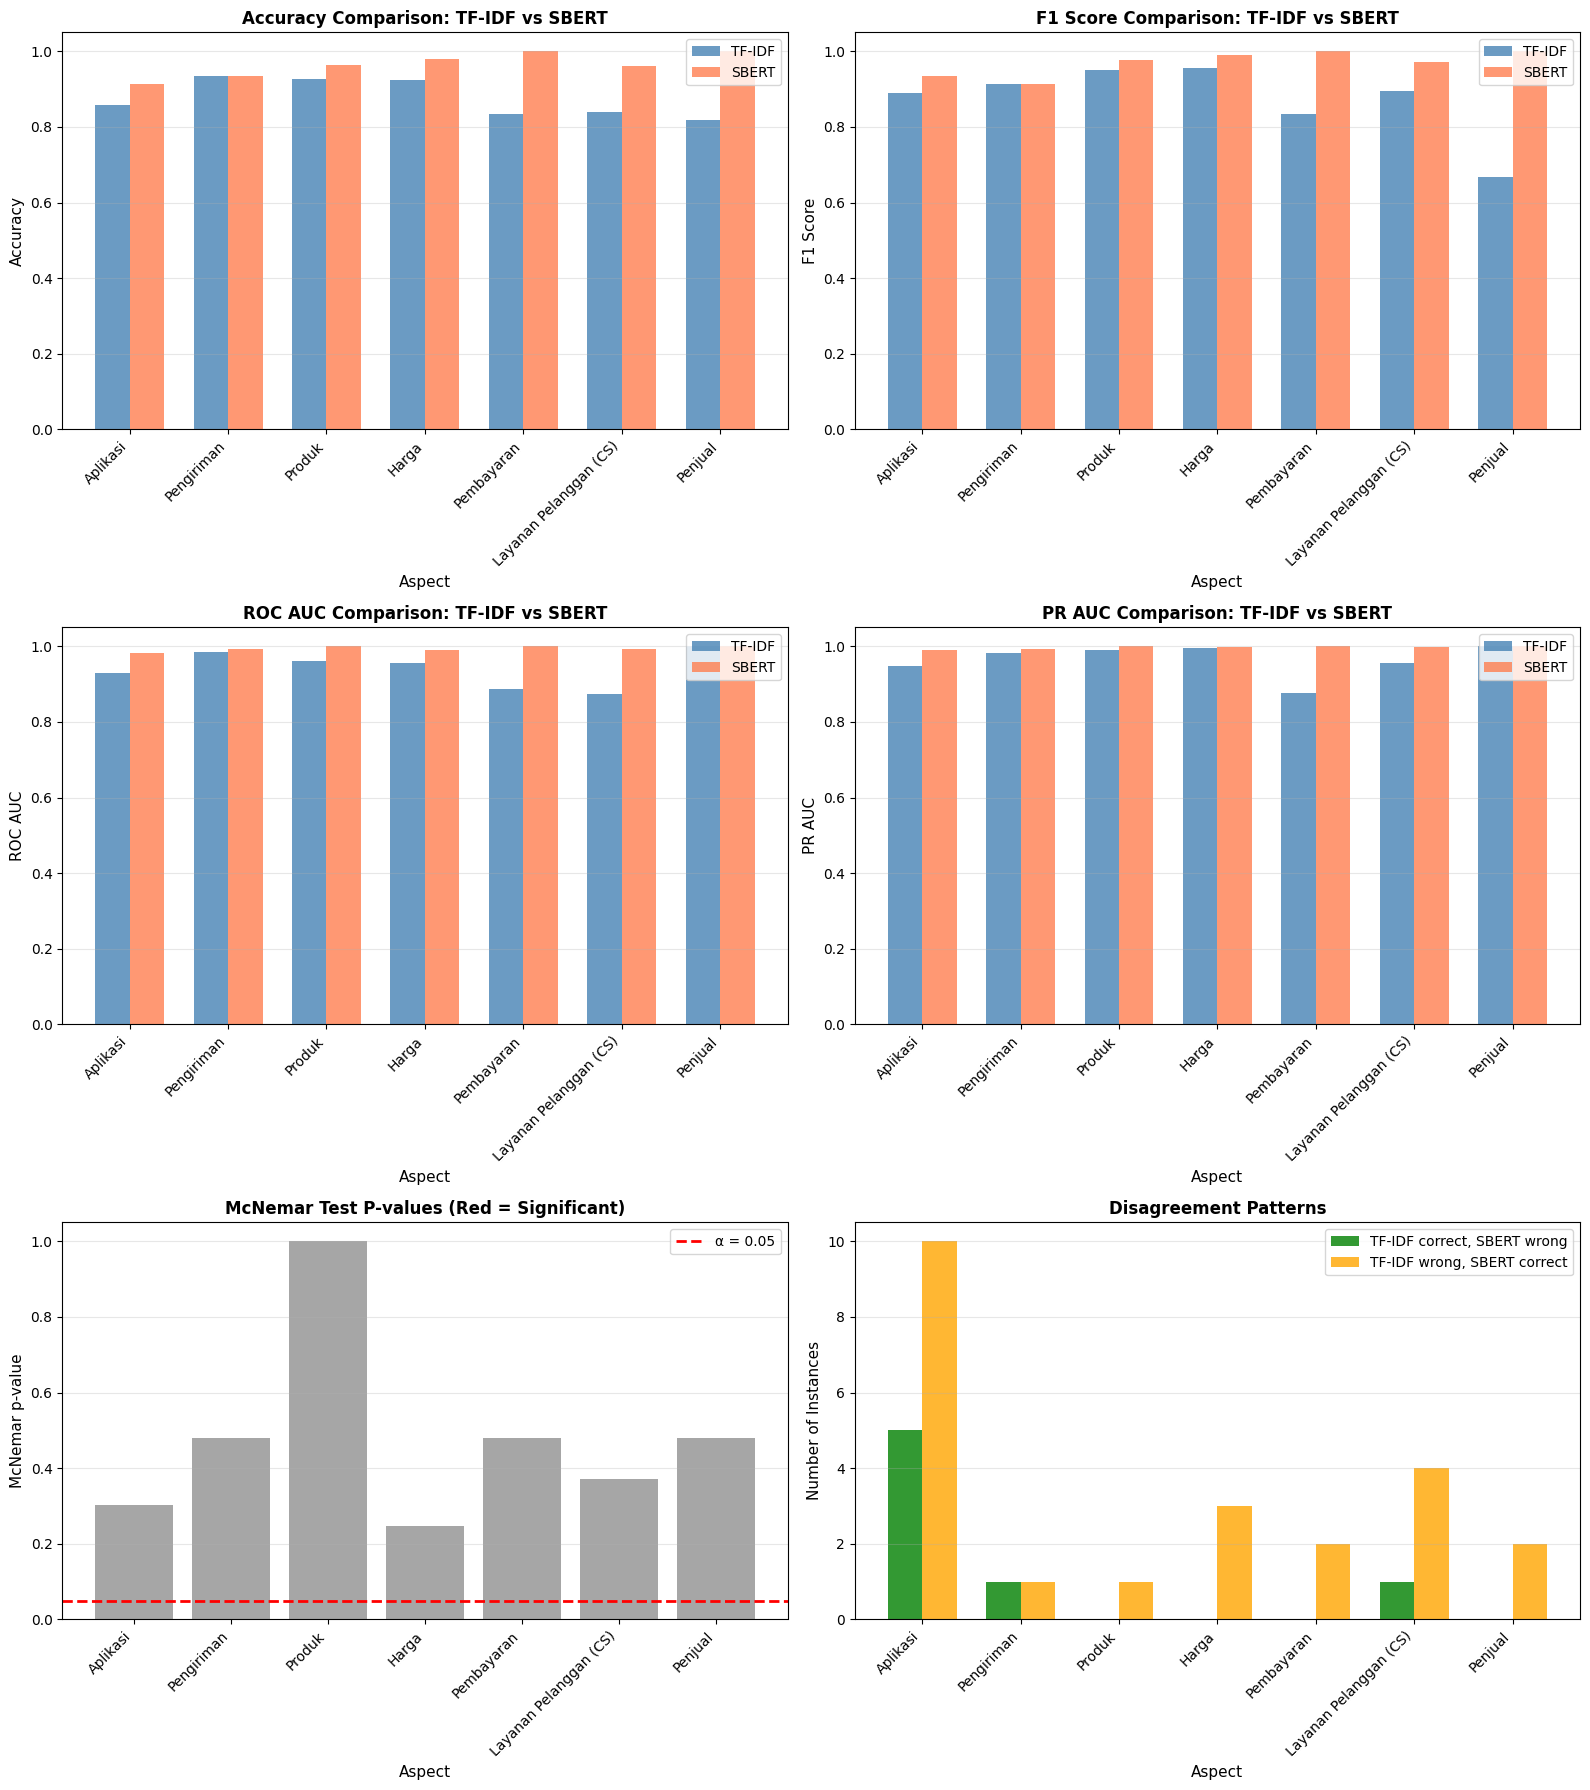

Saved combined comparison to: /kaggle/working/mcnemar_results/mcnemar_combined_comparison.png


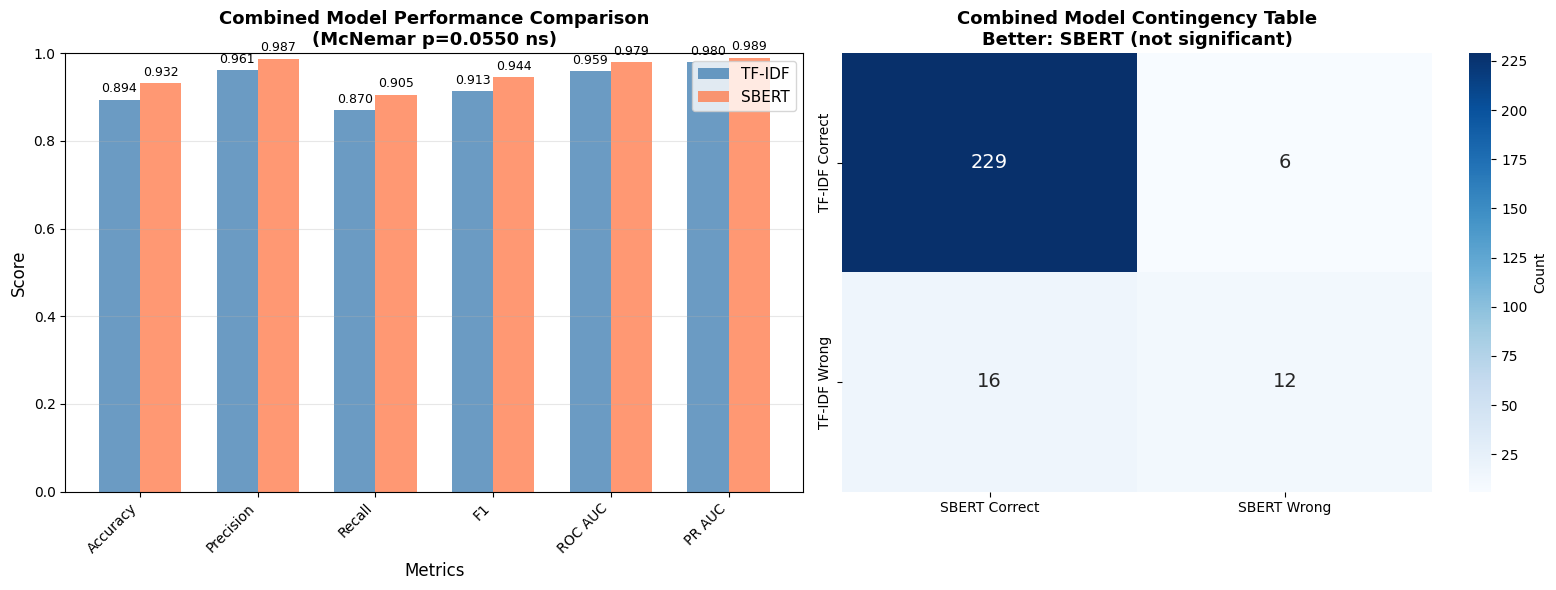


FINAL SUMMARY REPORT

PER-ASPECT RESULTS:
  Total aspects analyzed: 7
  Aspects with significant differences (p < 0.05): 0/7
  TF-IDF better: 0 aspects
  SBERT better: 6 aspects
  Tie: 1 aspects

PER-ASPECT AVERAGE METRICS:
  TF-IDF  - Acc: 0.8759, F1: 0.8721, ROC-AUC: 0.9412, PR-AUC: 0.9634
  SBERT   - Acc: 0.9642, F1: 0.9693, ROC-AUC: 0.9938, PR-AUC: 0.9969

COMBINED MODEL:
  TF-IDF  - Acc: 0.8935, P: 0.9608, R: 0.8698, F1: 0.9130, ROC-AUC: 0.9595, PR-AUC: 0.9796
  SBERT   - Acc: 0.9316, P: 0.9871, R: 0.9053, F1: 0.9444, ROC-AUC: 0.9787, PR-AUC: 0.9895

  McNemar p-value: 0.0550 ns
  Better model: SBERT
  Interpretation: not significant

ALL RESULTS SAVED TO: /kaggle/working/mcnemar_results
  Files generated:
    - per_aspect_mcnemar_results.csv (includes all 6 metrics)
    - combined_mcnemar_results.csv (includes all 6 metrics)
    - mcnemar_comparison_per_aspect.png (6-panel visualization)
    - mcnemar_combined_comparison.png (metrics + contingency)


In [8]:
# CELL D — McNemar Test: TF-IDF vs SBERT Comparison (Per-Aspect + Combined)
import warnings
warnings.filterwarnings("ignore")

import os, ast, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ========== CONFIG ==========
TFIDF_OUT_DIR = "/kaggle/working/gridsearch_results_fixed"
SBERT_OUT_DIR = "/kaggle/working/gridsearch_results_sbert"
MCNEMAR_OUT_DIR = "/kaggle/working/mcnemar_results"
os.makedirs(MCNEMAR_OUT_DIR, exist_ok=True)

ASPECTS = ['Aplikasi','Pengiriman','Produk','Harga','Pembayaran','Layanan Pelanggan (CS)','Penjual']
TEXT_COL = 'content'
TEST_SIZE = 0.2
RANDOM_STATE = 42

print("Loading SBERT model:", SBERT_NAME)
sbert = SentenceTransformer(SBERT_NAME, device=DEVICE)

# ========== HELPER FUNCTIONS ==========
def safe_load_best_params_from_cv_results(path_csv):
    # baca csv (asumsi kolom yang diperlukan ada)
    df = pd.read_csv(path_csv)

    # helper internal: konversi aman ke numeric
    def numeric_col(s):
        return pd.to_numeric(s, errors='coerce')

    # ambil kandidat rank_test_f1 == 1
    candidates = df[numeric_col(df['rank_test_f1']) == 1].copy()

    # jika lebih dari satu kandidat, tie-break
    if len(candidates) > 1:
        cur = candidates
        for col in ('mean_test_roc_auc', 'mean_test_pr_auc'):
            vals = numeric_col(cur[col])
            best_val = vals.max()
            cur = cur[vals == best_val].copy()
            if len(cur) == 1:
                break
        cur = cur.sort_index()
        chosen_row = cur.iloc[0]
    else:
        chosen_row = candidates.iloc[0]

    # parse params (menggunakan ast.literal_eval)
    params_raw = chosen_row['params']
    if isinstance(params_raw, str):
        params = ast.literal_eval(params_raw)
    else:
        params = dict(params_raw)

    # split params berdasarkan prefix tfidf__ / clf__
    tfidf_args = {k.replace('tfidf__', '', 1): v for k, v in params.items() if isinstance(k, str) and k.startswith('tfidf__')}
    clf_args   = {k.replace('clf__', '', 1): v for k, v in params.items() if isinstance(k, str) and k.startswith('clf__')}

    return tfidf_args, clf_args

def mcnemar_test(y_true, y_pred_a, y_pred_b):
    """
    Perform McNemar test comparing two classifiers.
    Returns: (statistic, p_value, contingency_table, interpretation)
    """
    # Contingency table
    correct_a = (y_pred_a == y_true)
    correct_b = (y_pred_b == y_true)
    
    # McNemar's 2x2 table:
    #                  Model B Correct | Model B Wrong
    # Model A Correct      n00         |     n01
    # Model A Wrong        n10         |     n11
    
    n00 = np.sum(correct_a & correct_b)    # both correct
    n01 = np.sum(correct_a & ~correct_b)   # A correct, B wrong
    n10 = np.sum(~correct_a & correct_b)   # A wrong, B correct
    n11 = np.sum(~correct_a & ~correct_b)  # both wrong
    
    contingency = np.array([[n00, n01], [n10, n11]])
    
    # McNemar statistic with continuity correction
    # chi2 = (|n01 - n10| - 1)^2 / (n01 + n10)
    if (n01 + n10) == 0:
        statistic = 0.0
        p_value = 1.0
    else:
        statistic = (abs(n01 - n10) - 1)**2 / (n01 + n10)
        p_value = 1 - chi2.cdf(statistic, df=1)
    
    # Interpretation
    if p_value < 0.001:
        sig_level = "***"
        interpretation = "highly significant"
    elif p_value < 0.01:
        sig_level = "**"
        interpretation = "very significant"
    elif p_value < 0.05:
        sig_level = "*"
        interpretation = "significant"
    else:
        sig_level = "ns"
        interpretation = "not significant"
    
    # Which model is better?
    if n01 > n10:
        better_model = "TF-IDF"
    elif n10 > n01:
        better_model = "SBERT"
    else:
        better_model = "Tie"
    
    return {
        'statistic': statistic,
        'p_value': p_value,
        'contingency': contingency,
        'n00_both_correct': n00,
        'n01_tfidf_correct_sbert_wrong': n01,
        'n10_tfidf_wrong_sbert_correct': n10,
        'n11_both_wrong': n11,
        'significance': sig_level,
        'interpretation': interpretation,
        'better_model': better_model
    }

def compute_metrics(y_true, y_pred, y_proba=None):
    """Compute standard classification metrics including ROC AUC and PR AUC"""
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': np.nan,
        'pr_auc': np.nan
    }
    
    # Compute ROC AUC and PR AUC if probabilities are provided
    if y_proba is not None and len(np.unique(y_true)) >= 2:
        try:
            from sklearn.metrics import roc_auc_score, average_precision_score
            probs = np.asarray(y_proba, dtype=float).ravel()
            metrics['roc_auc'] = float(roc_auc_score(y_true, probs))
            metrics['pr_auc'] = float(average_precision_score(y_true, probs))
        except Exception as e:
            print(f"    Warning: Could not compute ROC/PR AUC: {e}")
    
    return metrics

# ========== PART 1: PER-ASPECT COMPARISON ==========
print("\n" + "="*120)
print("PART 1: PER-ASPECT McNEMAR TEST (TF-IDF vs SBERT)")
print("="*120)

per_aspect_results = []

for aspect in ASPECTS:
    print("\n" + "-"*100)
    print(f"Aspect: {aspect}")
    print("-"*100)
    
    if aspect not in df.columns:
        print("  SKIP: aspect column not found")
        continue
    
    # Prepare data (exact same split as Cell A/C)
    ser = df[aspect].map(lambda x: 'P' if str(x).strip().upper()=='P' else ('N' if str(x).strip().upper()=='N' else None))
    mask = ser.notna()
    X_all = df.loc[mask, TEXT_COL].fillna('').astype(str).values
    y_all = ser[mask].map({'P':1,'N':0}).astype(int).values
    
    if len(y_all) < 10:
        print("  Too few samples; skipping")
        continue
    
    # Split (stratified by label, same as Cell A/C)
    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X_all, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=RANDOM_STATE
        )
    except Exception:
        X_train, X_test, y_train, y_test = train_test_split(
            X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE
        )
    
    print(f"  Samples - Train: {len(y_train)}, Test: {len(y_test)}")
    
    # ========== TF-IDF MODEL ==========
    tfidf_csv = os.path.join("/kaggle/working/gridsearch_results_tf-idf", f"{aspect}_grid_cv_results.csv")
    tfidf_args, clf_args_tfidf = safe_load_best_params_from_cv_results(tfidf_csv)
    print(f"  TF-IDF params: {tfidf_args}, LR: {clf_args_tfidf}")
    
    # Train TF-IDF model
    vect_tfidf = TfidfVectorizer(**tfidf_args)
    X_train_tfidf = vect_tfidf.fit_transform(X_train)
    X_test_tfidf = vect_tfidf.transform(X_test)
    
    clf_tfidf = LogisticRegression(**clf_args_tfidf, max_iter=1000, solver='liblinear', random_state=RANDOM_STATE)
    clf_tfidf.fit(X_train_tfidf, y_train)
    y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)
    
    # Get probabilities for ROC AUC and PR AUC
    y_proba_tfidf = None
    try:
        y_proba_tfidf = clf_tfidf.predict_proba(X_test_tfidf)[:,1]
    except Exception:
        try:
            y_proba_tfidf = clf_tfidf.decision_function(X_test_tfidf)
        except Exception:
            pass
    
    metrics_tfidf = compute_metrics(y_test, y_pred_tfidf, y_proba_tfidf)
    print(f"  TF-IDF - Acc: {metrics_tfidf['accuracy']:.4f}, P: {metrics_tfidf['precision']:.4f}, R: {metrics_tfidf['recall']:.4f}, F1: {metrics_tfidf['f1']:.4f}, ROC-AUC: {metrics_tfidf['roc_auc']:.4f}, PR-AUC: {metrics_tfidf['pr_auc']:.4f}")
    
    # ========== SBERT MODEL ==========
    sbert_csv = os.path.join(OUT_DIR, f"{aspect}_grid_cv_results_sbert.csv")
    sbert_params = safe_load_best_params_from_cv_results(sbert_csv)
    _, clf_args_sbert = sbert_params
    
    print(f"  SBERT LR params: {clf_args_sbert}")
    
    # Train SBERT model
    X_train_sbert = sbert.encode(list(X_train), convert_to_numpy=True, show_progress_bar=False)
    X_test_sbert = sbert.encode(list(X_test), convert_to_numpy=True, show_progress_bar=False)
    
    scaler = Normalizer(norm='l2')
    X_train_sbert_scaled = scaler.fit_transform(X_train_sbert)
    X_test_sbert_scaled = scaler.transform(X_test_sbert)
    
    clf_sbert = LogisticRegression(**clf_args_sbert, max_iter=1000, solver='liblinear', random_state=RANDOM_STATE)
    clf_sbert.fit(X_train_sbert_scaled, y_train)
    y_pred_sbert = clf_sbert.predict(X_test_sbert_scaled)
    
    # Get probabilities for ROC AUC and PR AUC
    y_proba_sbert = None
    try:
        y_proba_sbert = clf_sbert.predict_proba(X_test_sbert_scaled)[:,1]
    except Exception:
        try:
            y_proba_sbert = clf_sbert.decision_function(X_test_sbert_scaled)
        except Exception:
            pass
    
    metrics_sbert = compute_metrics(y_test, y_pred_sbert, y_proba_sbert)
    print(f"  SBERT - Acc: {metrics_sbert['accuracy']:.4f}, P: {metrics_sbert['precision']:.4f}, R: {metrics_sbert['recall']:.4f}, F1: {metrics_sbert['f1']:.4f}, ROC-AUC: {metrics_sbert['roc_auc']:.4f}, PR-AUC: {metrics_sbert['pr_auc']:.4f}")
    
    # ========== McNEMAR TEST ==========
    mcnemar_result = mcnemar_test(y_test, y_pred_tfidf, y_pred_sbert)
    
    print(f"\n  McNemar Test Results:")
    print(f"    Statistic: {mcnemar_result['statistic']:.4f}")
    print(f"    P-value: {mcnemar_result['p_value']:.4f} {mcnemar_result['significance']}")
    print(f"    Interpretation: {mcnemar_result['interpretation']}")
    print(f"    Better model: {mcnemar_result['better_model']}")
    print(f"\n  Contingency Table:")
    print(f"    Both correct: {mcnemar_result['n00_both_correct']}")
    print(f"    TF-IDF correct, SBERT wrong: {mcnemar_result['n01_tfidf_correct_sbert_wrong']}")
    print(f"    TF-IDF wrong, SBERT correct: {mcnemar_result['n10_tfidf_wrong_sbert_correct']}")
    print(f"    Both wrong: {mcnemar_result['n11_both_wrong']}")
    
    # Store results
    per_aspect_results.append({
        'aspect': aspect,
        'n_test': len(y_test),
        'tfidf_accuracy': metrics_tfidf['accuracy'],
        'tfidf_precision': metrics_tfidf['precision'],
        'tfidf_recall': metrics_tfidf['recall'],
        'tfidf_f1': metrics_tfidf['f1'],
        'tfidf_roc_auc': metrics_tfidf['roc_auc'],
        'tfidf_pr_auc': metrics_tfidf['pr_auc'],
        'sbert_accuracy': metrics_sbert['accuracy'],
        'sbert_precision': metrics_sbert['precision'],
        'sbert_recall': metrics_sbert['recall'],
        'sbert_f1': metrics_sbert['f1'],
        'sbert_roc_auc': metrics_sbert['roc_auc'],
        'sbert_pr_auc': metrics_sbert['pr_auc'],
        'mcnemar_statistic': mcnemar_result['statistic'],
        'mcnemar_p_value': mcnemar_result['p_value'],
        'significance': mcnemar_result['significance'],
        'better_model': mcnemar_result['better_model'],
        'n00': mcnemar_result['n00_both_correct'],
        'n01': mcnemar_result['n01_tfidf_correct_sbert_wrong'],
        'n10': mcnemar_result['n10_tfidf_wrong_sbert_correct'],
        'n11': mcnemar_result['n11_both_wrong']
    })

# Save per-aspect results
df_per_aspect = pd.DataFrame(per_aspect_results)
df_per_aspect.to_csv(os.path.join(MCNEMAR_OUT_DIR, "per_aspect_mcnemar_results.csv"), index=False)
print("\n" + "="*120)
print("Per-aspect results saved to:", os.path.join(MCNEMAR_OUT_DIR, "per_aspect_mcnemar_results.csv"))
print("\nPer-Aspect Summary:")
display(df_per_aspect)

# ========== PART 2: COMBINED MODEL COMPARISON ==========
print("\n" + "="*120)
print("PART 2: COMBINED MODEL McNEMAR TEST (TF-IDF vs SBERT)")
print("="*120)

# Reconstruct combined splits (same as Cell A/C)
combined_train_X = []
combined_train_y = []
combined_test_X = []
combined_test_y = []

for aspect in ASPECTS:
    if aspect not in df.columns:
        continue
    
    ser = df[aspect].map(lambda x: 'P' if str(x).strip().upper()=='P' else ('N' if str(x).strip().upper()=='N' else None))
    mask = ser.notna()
    X_all = df.loc[mask, TEXT_COL].fillna('').astype(str).values
    y_all = ser[mask].map({'P':1,'N':0}).astype(int).values
    
    if len(y_all) < 10:
        continue
    
    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X_all, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=RANDOM_STATE
        )
    except Exception:
        X_train, X_test, y_train, y_test = train_test_split(
            X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE
        )
    
    combined_train_X.append(X_train)
    combined_train_y.append(y_train)
    combined_test_X.append(X_test)
    combined_test_y.append(y_test)

X_train_comb = np.concatenate(combined_train_X)
y_train_comb = np.concatenate(combined_train_y)
X_test_comb = np.concatenate(combined_test_X)
y_test_comb = np.concatenate(combined_test_y)

print(f"Combined dataset - Train: {len(y_train_comb)}, Test: {len(y_test_comb)}")
combined_cv_csv = os.path.join("/kaggle/working/gridsearch_results_tf-idf", "COMBINED_grid_cv_results.csv")
best_combined = safe_load_best_params_from_cv_results(combined_cv_csv)
tfidf_args_c, clf_args_tfidf_c = best_combined
print(f"TF-IDF Combined params: {tfidf_args_c}, LR: {clf_args_tfidf_c}")

vect_tfidf_comb = TfidfVectorizer(**tfidf_args_c)
X_train_tfidf_comb = vect_tfidf_comb.fit_transform(X_train_comb)
X_test_tfidf_comb = vect_tfidf_comb.transform(X_test_comb)

clf_tfidf_comb = LogisticRegression(**clf_args_tfidf_c, max_iter=1000, solver='liblinear', random_state=RANDOM_STATE)
clf_tfidf_comb.fit(X_train_tfidf_comb, y_train_comb)
y_pred_tfidf_comb = clf_tfidf_comb.predict(X_test_tfidf_comb)

# Get probabilities for ROC AUC and PR AUC
y_proba_tfidf_comb = None
try:
    y_proba_tfidf_comb = clf_tfidf_comb.predict_proba(X_test_tfidf_comb)[:,1]
except Exception:
    try:
        y_proba_tfidf_comb = clf_tfidf_comb.decision_function(X_test_tfidf_comb)
    except Exception:
        pass

metrics_tfidf_comb = compute_metrics(y_test_comb, y_pred_tfidf_comb, y_proba_tfidf_comb)
print(f"TF-IDF Combined - Acc: {metrics_tfidf_comb['accuracy']:.4f}, P: {metrics_tfidf_comb['precision']:.4f}, R: {metrics_tfidf_comb['recall']:.4f}, F1: {metrics_tfidf_comb['f1']:.4f}, ROC-AUC: {metrics_tfidf_comb['roc_auc']:.4f}, PR-AUC: {metrics_tfidf_comb['pr_auc']:.4f}")
combined_cv_csv = os.path.join("/kaggle/working/gridsearch_results_sbert", "COMBINED_grid_cv_results_sbert.csv")
_, best_combined = safe_load_best_params_from_cv_results(combined_cv_csv)
clf_args_sbert_c = best_combined
print(f"SBERT Combined LR params: {clf_args_sbert_c}")

X_train_sbert_comb = sbert.encode(list(X_train_comb), convert_to_numpy=True, show_progress_bar=False)
X_test_sbert_comb = sbert.encode(list(X_test_comb), convert_to_numpy=True, show_progress_bar=False)

scaler_comb = Normalizer(norm='l2')
X_train_sbert_comb_scaled = scaler_comb.fit_transform(X_train_sbert_comb)
X_test_sbert_comb_scaled = scaler_comb.transform(X_test_sbert_comb)

clf_sbert_comb = LogisticRegression(**clf_args_sbert_c, max_iter=1000, solver='liblinear', random_state=RANDOM_STATE)
clf_sbert_comb.fit(X_train_sbert_comb_scaled, y_train_comb)
y_pred_sbert_comb = clf_sbert_comb.predict(X_test_sbert_comb_scaled)

# Get probabilities for ROC AUC and PR AUC
y_proba_sbert_comb = None
try:
    y_proba_sbert_comb = clf_sbert_comb.predict_proba(X_test_sbert_comb_scaled)[:,1]
except Exception:
    try:
        y_proba_sbert_comb = clf_sbert_comb.decision_function(X_test_sbert_comb_scaled)
    except Exception:
        pass

metrics_sbert_comb = compute_metrics(y_test_comb, y_pred_sbert_comb, y_proba_sbert_comb)
print(f"SBERT Combined - Acc: {metrics_sbert_comb['accuracy']:.4f}, P: {metrics_sbert_comb['precision']:.4f}, R: {metrics_sbert_comb['recall']:.4f}, F1: {metrics_sbert_comb['f1']:.4f}, ROC-AUC: {metrics_sbert_comb['roc_auc']:.4f}, PR-AUC: {metrics_sbert_comb['pr_auc']:.4f}")

# ========== COMBINED McNEMAR TEST ==========
mcnemar_comb = mcnemar_test(y_test_comb, y_pred_tfidf_comb, y_pred_sbert_comb)

print(f"\nCombined McNemar Test Results:")
print(f"  Statistic: {mcnemar_comb['statistic']:.4f}")
print(f"  P-value: {mcnemar_comb['p_value']:.4f} {mcnemar_comb['significance']}")
print(f"  Interpretation: {mcnemar_comb['interpretation']}")
print(f"  Better model: {mcnemar_comb['better_model']}")
print(f"\nContingency Table:")
print(f"  Both correct: {mcnemar_comb['n00_both_correct']}")
print(f"  TF-IDF correct, SBERT wrong: {mcnemar_comb['n01_tfidf_correct_sbert_wrong']}")
print(f"  TF-IDF wrong, SBERT correct: {mcnemar_comb['n10_tfidf_wrong_sbert_correct']}")
print(f"  Both wrong: {mcnemar_comb['n11_both_wrong']}")

# Save combined results as CSV
combined_results = {
    'model': 'COMBINED',
    'n_test': len(y_test_comb),
    'tfidf_accuracy': metrics_tfidf_comb['accuracy'],
    'tfidf_precision': metrics_tfidf_comb['precision'],
    'tfidf_recall': metrics_tfidf_comb['recall'],
    'tfidf_f1': metrics_tfidf_comb['f1'],
    'tfidf_roc_auc': metrics_tfidf_comb['roc_auc'],
    'tfidf_pr_auc': metrics_tfidf_comb['pr_auc'],
    'sbert_accuracy': metrics_sbert_comb['accuracy'],
    'sbert_precision': metrics_sbert_comb['precision'],
    'sbert_recall': metrics_sbert_comb['recall'],
    'sbert_f1': metrics_sbert_comb['f1'],
    'sbert_roc_auc': metrics_sbert_comb['roc_auc'],
    'sbert_pr_auc': metrics_sbert_comb['pr_auc'],
    'mcnemar_statistic': mcnemar_comb['statistic'],
    'mcnemar_p_value': mcnemar_comb['p_value'],
    'significance': mcnemar_comb['significance'],
    'better_model': mcnemar_comb['better_model'],
    'n00': mcnemar_comb['n00_both_correct'],
    'n01': mcnemar_comb['n01_tfidf_correct_sbert_wrong'],
    'n10': mcnemar_comb['n10_tfidf_wrong_sbert_correct'],
    'n11': mcnemar_comb['n11_both_wrong']
}

# Save as CSV
df_combined = pd.DataFrame([combined_results])
df_combined.to_csv(os.path.join(MCNEMAR_OUT_DIR, "combined_mcnemar_results.csv"), index=False)
print("\nCombined results saved to:", os.path.join(MCNEMAR_OUT_DIR, "combined_mcnemar_results.csv"))

# ========== VISUALIZATION ==========
print("\n" + "="*120)
print("GENERATING VISUALIZATIONS")
print("="*120)

# Plot 1: Comprehensive metrics comparison (3x2 grid)
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

x = np.arange(len(df_per_aspect))
width = 0.35

# Subplot 1: Accuracy comparison
ax1 = axes[0, 0]
ax1.bar(x - width/2, df_per_aspect['tfidf_accuracy'], width, label='TF-IDF', alpha=0.8, color='steelblue')
ax1.bar(x + width/2, df_per_aspect['sbert_accuracy'], width, label='SBERT', alpha=0.8, color='coral')
ax1.set_xlabel('Aspect', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('Accuracy Comparison: TF-IDF vs SBERT', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(df_per_aspect['aspect'], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Subplot 2: F1 comparison
ax2 = axes[0, 1]
ax2.bar(x - width/2, df_per_aspect['tfidf_f1'], width, label='TF-IDF', alpha=0.8, color='steelblue')
ax2.bar(x + width/2, df_per_aspect['sbert_f1'], width, label='SBERT', alpha=0.8, color='coral')
ax2.set_xlabel('Aspect', fontsize=11)
ax2.set_ylabel('F1 Score', fontsize=11)
ax2.set_title('F1 Score Comparison: TF-IDF vs SBERT', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(df_per_aspect['aspect'], rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Subplot 3: ROC AUC comparison
ax3 = axes[1, 0]
ax3.bar(x - width/2, df_per_aspect['tfidf_roc_auc'], width, label='TF-IDF', alpha=0.8, color='steelblue')
ax3.bar(x + width/2, df_per_aspect['sbert_roc_auc'], width, label='SBERT', alpha=0.8, color='coral')
ax3.set_xlabel('Aspect', fontsize=11)
ax3.set_ylabel('ROC AUC', fontsize=11)
ax3.set_title('ROC AUC Comparison: TF-IDF vs SBERT', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(df_per_aspect['aspect'], rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Subplot 4: PR AUC comparison
ax4 = axes[1, 1]
ax4.bar(x - width/2, df_per_aspect['tfidf_pr_auc'], width, label='TF-IDF', alpha=0.8, color='steelblue')
ax4.bar(x + width/2, df_per_aspect['sbert_pr_auc'], width, label='SBERT', alpha=0.8, color='coral')
ax4.set_xlabel('Aspect', fontsize=11)
ax4.set_ylabel('PR AUC', fontsize=11)
ax4.set_title('PR AUC Comparison: TF-IDF vs SBERT', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(df_per_aspect['aspect'], rotation=45, ha='right')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Subplot 5: McNemar p-values with significance markers
ax5 = axes[2, 0]
colors = ['red' if p < 0.05 else 'gray' for p in df_per_aspect['mcnemar_p_value']]
ax5.bar(x, df_per_aspect['mcnemar_p_value'], color=colors, alpha=0.7)
ax5.axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
ax5.set_xlabel('Aspect', fontsize=11)
ax5.set_ylabel('McNemar p-value', fontsize=11)
ax5.set_title('McNemar Test P-values (Red = Significant)', fontsize=12, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(df_per_aspect['aspect'], rotation=45, ha='right')
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

# Subplot 6: Disagreement patterns
ax6 = axes[2, 1]
ax6.bar(x - width/2, df_per_aspect['n01'], width, label='TF-IDF correct, SBERT wrong', alpha=0.8, color='green')
ax6.bar(x + width/2, df_per_aspect['n10'], width, label='TF-IDF wrong, SBERT correct', alpha=0.8, color='orange')
ax6.set_xlabel('Aspect', fontsize=11)
ax6.set_ylabel('Number of Instances', fontsize=11)
ax6.set_title('Disagreement Patterns', fontsize=12, fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels(df_per_aspect['aspect'], rotation=45, ha='right')
ax6.legend()
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MCNEMAR_OUT_DIR, "mcnemar_comparison_per_aspect.png"), dpi=300, bbox_inches='tight')
print("Saved visualization to:", os.path.join(MCNEMAR_OUT_DIR, "mcnemar_comparison_per_aspect.png"))
plt.show()

# Plot 2: Combined model comparison - metrics bar chart + contingency heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Combined model metrics comparison
ax1 = axes[0]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC', 'PR AUC']
tfidf_values = [metrics_tfidf_comb['accuracy'], metrics_tfidf_comb['precision'], 
                metrics_tfidf_comb['recall'], metrics_tfidf_comb['f1'],
                metrics_tfidf_comb['roc_auc'], metrics_tfidf_comb['pr_auc']]
sbert_values = [metrics_sbert_comb['accuracy'], metrics_sbert_comb['precision'],
                metrics_sbert_comb['recall'], metrics_sbert_comb['f1'],
                metrics_sbert_comb['roc_auc'], metrics_sbert_comb['pr_auc']]

x_pos = np.arange(len(metrics_names))
width = 0.35
ax1.bar(x_pos - width/2, tfidf_values, width, label='TF-IDF', alpha=0.8, color='steelblue')
ax1.bar(x_pos + width/2, sbert_values, width, label='SBERT', alpha=0.8, color='coral')
ax1.set_ylabel('Score', fontsize=12)
ax1.set_xlabel('Metrics', fontsize=12)
ax1.set_title(f'Combined Model Performance Comparison\n(McNemar p={mcnemar_comb["p_value"]:.4f} {mcnemar_comb["significance"]})', 
              fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(metrics_names, rotation=45, ha='right')
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.0])

# Add value labels on bars
for i, (t_val, s_val) in enumerate(zip(tfidf_values, sbert_values)):
    ax1.text(i - width/2, t_val + 0.01, f'{t_val:.3f}', ha='center', va='bottom', fontsize=9)
    ax1.text(i + width/2, s_val + 0.01, f'{s_val:.3f}', ha='center', va='bottom', fontsize=9)

# Subplot 2: Contingency heatmap
ax2 = axes[1]
sns.heatmap(mcnemar_comb['contingency'], annot=True, fmt='d', cmap='Blues', 
            xticklabels=['SBERT Correct', 'SBERT Wrong'],
            yticklabels=['TF-IDF Correct', 'TF-IDF Wrong'],
            cbar_kws={'label': 'Count'}, ax=ax2, annot_kws={'size': 14})
ax2.set_title(f"Combined Model Contingency Table\nBetter: {mcnemar_comb['better_model']} ({mcnemar_comb['interpretation']})", 
              fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(MCNEMAR_OUT_DIR, "mcnemar_combined_comparison.png"), dpi=300, bbox_inches='tight')
print("Saved combined comparison to:", os.path.join(MCNEMAR_OUT_DIR, "mcnemar_combined_comparison.png"))
plt.show()

# ========== SUMMARY REPORT ==========
print("\n" + "="*120)
print("FINAL SUMMARY REPORT")
print("="*120)

print("\nPER-ASPECT RESULTS:")
print(f"  Total aspects analyzed: {len(df_per_aspect)}")
print(f"  Aspects with significant differences (p < 0.05): {sum(df_per_aspect['mcnemar_p_value'] < 0.05)}/{len(df_per_aspect)}")
print(f"  TF-IDF better: {sum(df_per_aspect['better_model'] == 'TF-IDF')} aspects")
print(f"  SBERT better: {sum(df_per_aspect['better_model'] == 'SBERT')} aspects")
print(f"  Tie: {sum(df_per_aspect['better_model'] == 'Tie')} aspects")

print("\nPER-ASPECT AVERAGE METRICS:")
print(f"  TF-IDF  - Acc: {df_per_aspect['tfidf_accuracy'].mean():.4f}, F1: {df_per_aspect['tfidf_f1'].mean():.4f}, ROC-AUC: {df_per_aspect['tfidf_roc_auc'].mean():.4f}, PR-AUC: {df_per_aspect['tfidf_pr_auc'].mean():.4f}")
print(f"  SBERT   - Acc: {df_per_aspect['sbert_accuracy'].mean():.4f}, F1: {df_per_aspect['sbert_f1'].mean():.4f}, ROC-AUC: {df_per_aspect['sbert_roc_auc'].mean():.4f}, PR-AUC: {df_per_aspect['sbert_pr_auc'].mean():.4f}")

print(f"\nCOMBINED MODEL:")
print(f"  TF-IDF  - Acc: {metrics_tfidf_comb['accuracy']:.4f}, P: {metrics_tfidf_comb['precision']:.4f}, R: {metrics_tfidf_comb['recall']:.4f}, F1: {metrics_tfidf_comb['f1']:.4f}, ROC-AUC: {metrics_tfidf_comb['roc_auc']:.4f}, PR-AUC: {metrics_tfidf_comb['pr_auc']:.4f}")
print(f"  SBERT   - Acc: {metrics_sbert_comb['accuracy']:.4f}, P: {metrics_sbert_comb['precision']:.4f}, R: {metrics_sbert_comb['recall']:.4f}, F1: {metrics_sbert_comb['f1']:.4f}, ROC-AUC: {metrics_sbert_comb['roc_auc']:.4f}, PR-AUC: {metrics_sbert_comb['pr_auc']:.4f}")
print(f"\n  McNemar p-value: {mcnemar_comb['p_value']:.4f} {mcnemar_comb['significance']}")
print(f"  Better model: {mcnemar_comb['better_model']}")
print(f"  Interpretation: {mcnemar_comb['interpretation']}")

print("\n" + "="*120)
print("ALL RESULTS SAVED TO:", MCNEMAR_OUT_DIR)
print("  Files generated:")
print(f"    - per_aspect_mcnemar_results.csv (includes all 6 metrics)")
print(f"    - combined_mcnemar_results.csv (includes all 6 metrics)")
print(f"    - mcnemar_comparison_per_aspect.png (6-panel visualization)")
print(f"    - mcnemar_combined_comparison.png (metrics + contingency)")
print("="*120)


PART 1: PER-ASPECT McNEMAR TEST (TF-IDF vs SBERT) with universal parameter

----------------------------------------------------------------------------------------------------
Aspect: Aplikasi
----------------------------------------------------------------------------------------------------
  Samples - Train: 364, Test: 91
  TF-IDF params: {'max_df': 0.7, 'max_features': 200, 'min_df': 1, 'ngram_range': (1, 1)}, LR: {'C': 1.0, 'class_weight': 'balanced'}
  TF-IDF - Acc: 0.8681, P: 0.8966, R: 0.8966, F1: 0.8966, ROC-AUC: 0.9357, PR-AUC: 0.9609
  SBERT LR params: {'C': 1.0, 'class_weight': 'balanced'}
  SBERT - Acc: 0.8901, P: 0.9138, R: 0.9138, F1: 0.9138, ROC-AUC: 0.9666, PR-AUC: 0.9837

  McNemar Test Results:
    Statistic: 0.0833
    P-value: 0.7728 ns
    Interpretation: not significant
    Better model: SBERT

  Contingency Table:
    Both correct: 74
    TF-IDF correct, SBERT wrong: 5
    TF-IDF wrong, SBERT correct: 7
    Both wrong: 5

--------------------------------------

,aspect,n_test,tfidf_accuracy,tfidf_precision,tfidf_recall,tfidf_f1,tfidf_roc_auc,tfidf_pr_auc,sbert_accuracy,sbert_precision,...,sbert_roc_auc,sbert_pr_auc,mcnemar_statistic,mcnemar_p_value,significance,better_model,n00,n01,n10,n11
0,Aplikasi,91,0.868132,0.896552,0.896552,0.896552,0.935737,0.960863,0.890110,0.913793,...,0.966562,0.983662,0.083333,0.772830,ns,SBERT,74,5,7,5
1,Pengiriman,45,0.933333,1.000000,0.842105,0.914286,0.985830,0.983341,0.933333,1.000000,...,0.993927,0.991674,0.500000,0.479500,ns,Tie,41,1,1,2
2,Produk,27,0.814815,0.944444,0.809524,0.871795,0.928571,0.981283,0.925926,1.000000,...,1.000000,1.000000,1.333333,0.248213,ns,SBERT,22,0,3,2
3,Harga,52,0.923077,0.956522,0.956522,0.956522,0.963768,0.995310,0.961538,1.000000,...,0.989130,0.998669,0.500000,0.479500,ns,SBERT,48,0,2,2
4,Pembayaran,12,0.916667,0.833333,1.000000,0.909091,0.971429,0.966667,1.000000,1.000000,...,1.000000,1.000000,0.000000,1.000000,ns,SBERT,11,0,1,0
5,Layanan Pelanggan (CS),25,0.880000,0.941176,0.888889,0.914286,0.976190,0.990722,0.920000,1.000000,...,0.992063,0.997076,0.000000,1.000000,ns,SBERT,21,1,2,1
6,Penjual,11,0.909091,0.666667,1.000000,0.800000,1.000000,1.000000,0.909091,0.666667,...,1.000000,1.000000,0.500000,0.479500,ns,Tie,9,1,1,0



PART 2: COMBINED MODEL McNEMAR TEST (TF-IDF vs SBERT)
Combined dataset - Train: 1041, Test: 263
TF-IDF Combined params: {'max_df': 0.7, 'max_features': 200, 'min_df': 1, 'ngram_range': (1, 1)}, LR: {'C': 1.0, 'class_weight': 'balanced'}
TF-IDF Combined - Acc: 0.8935, P: 0.9608, R: 0.8698, F1: 0.9130, ROC-AUC: 0.9595, PR-AUC: 0.9796
SBERT Combined LR params: {'C': 1.0, 'class_weight': 'balanced'}
SBERT Combined - Acc: 0.9316, P: 0.9871, R: 0.9053, F1: 0.9444, ROC-AUC: 0.9787, PR-AUC: 0.9895

Combined McNemar Test Results:
  Statistic: 3.6818
  P-value: 0.0550 ns
  Interpretation: not significant
  Better model: SBERT

Contingency Table:
  Both correct: 229
  TF-IDF correct, SBERT wrong: 6
  TF-IDF wrong, SBERT correct: 16
  Both wrong: 12

Combined results saved to: /kaggle/working/mcnemar_results/combined_mcnemar_results.csv

GENERATING VISUALIZATIONS
Saved visualization to: /kaggle/working/mcnemar_results/mcnemar_comparison_per_aspect.png


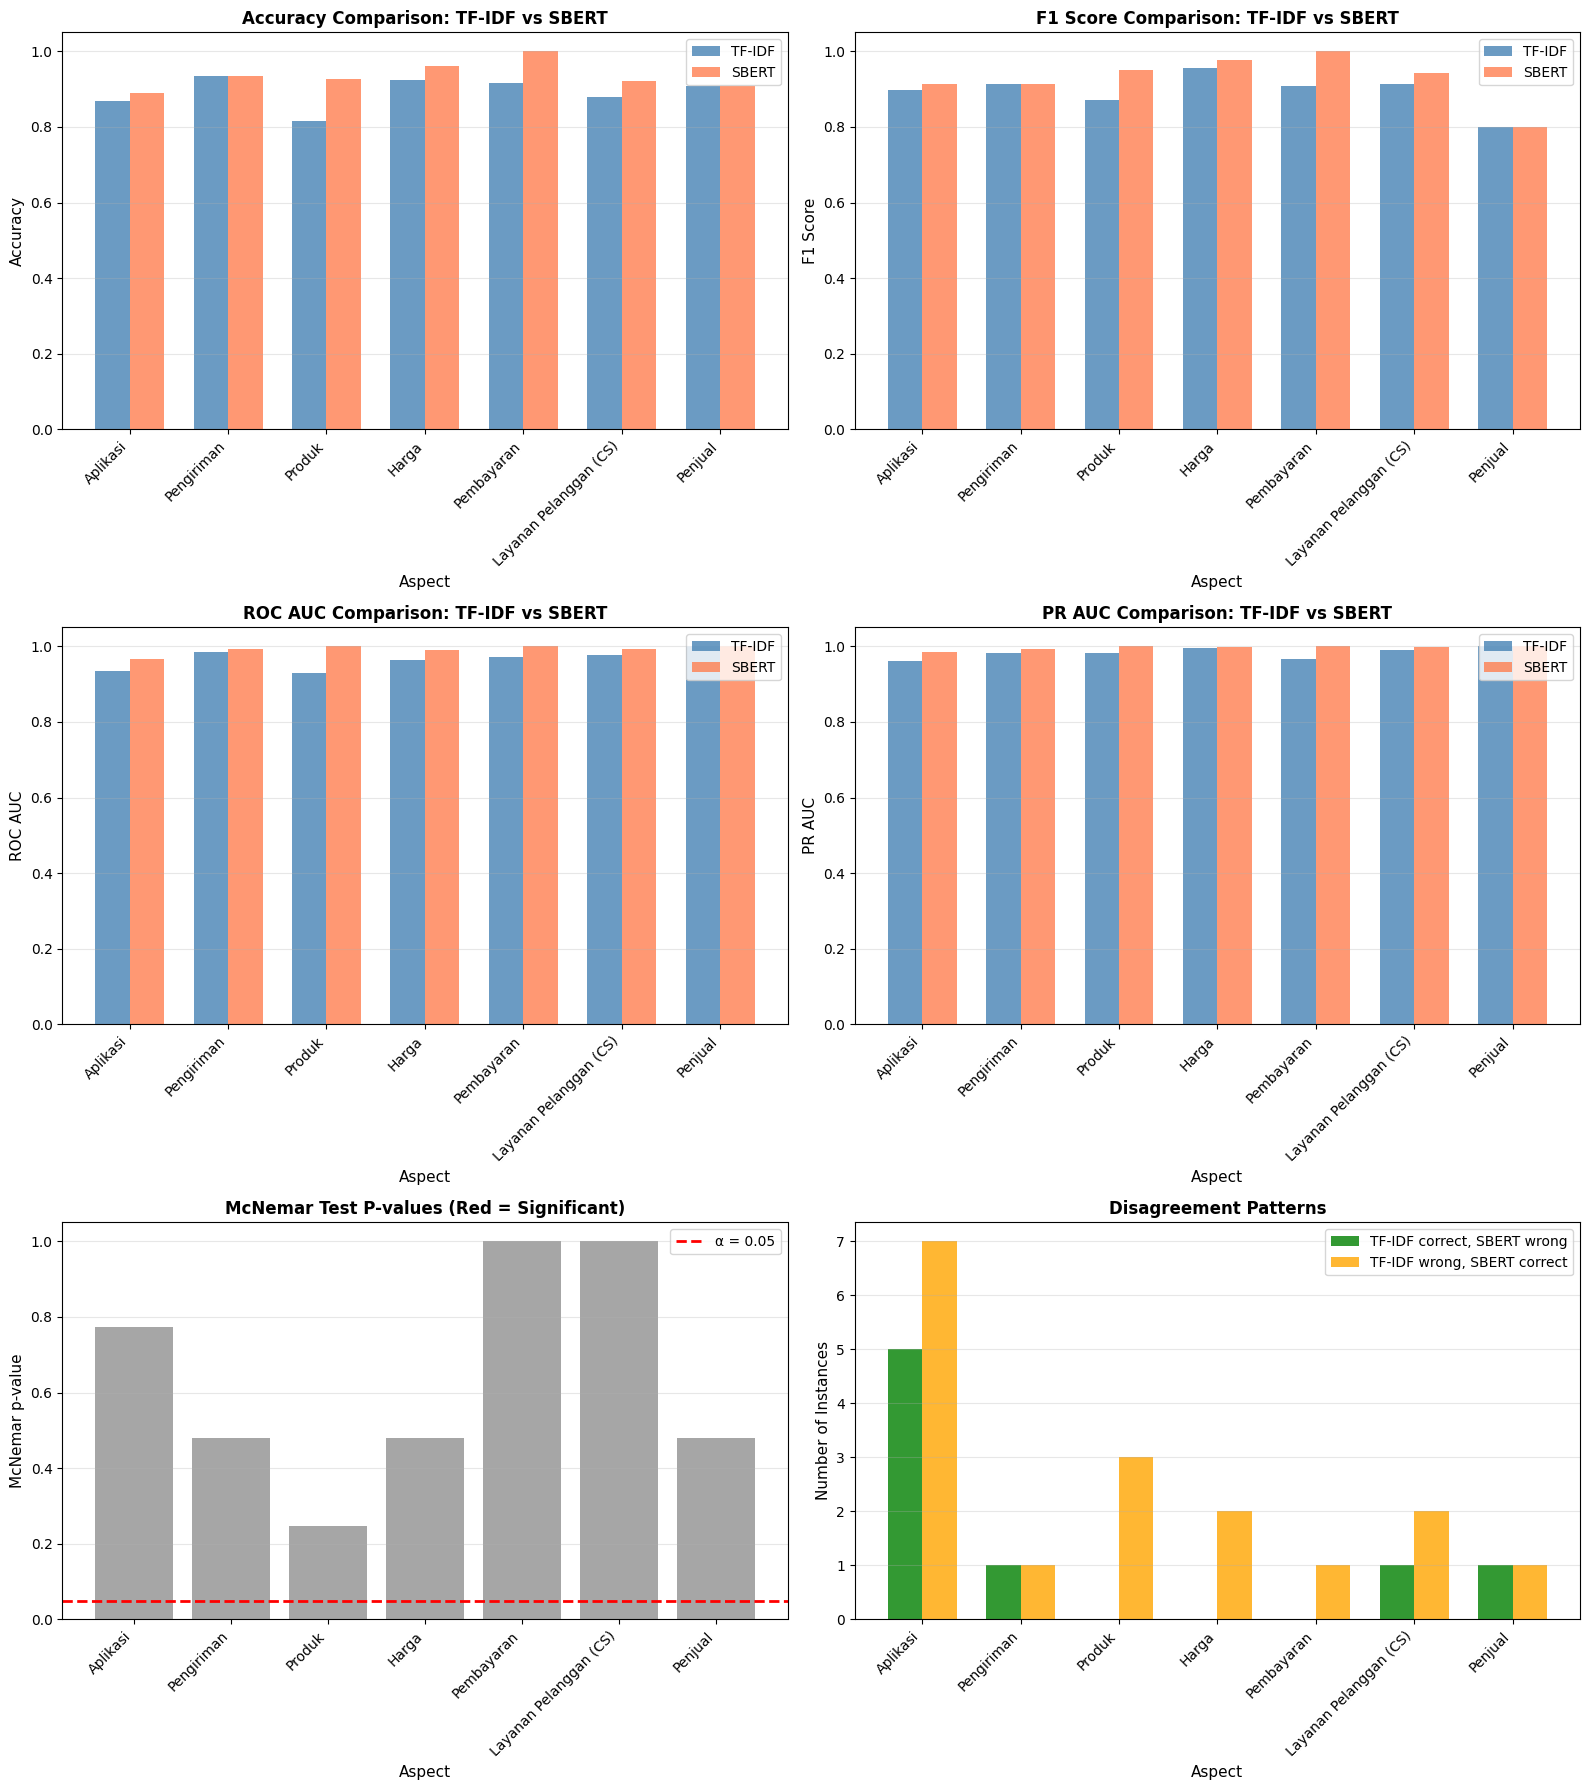

Saved combined comparison to: /kaggle/working/mcnemar_results/mcnemar_combined_comparison.png


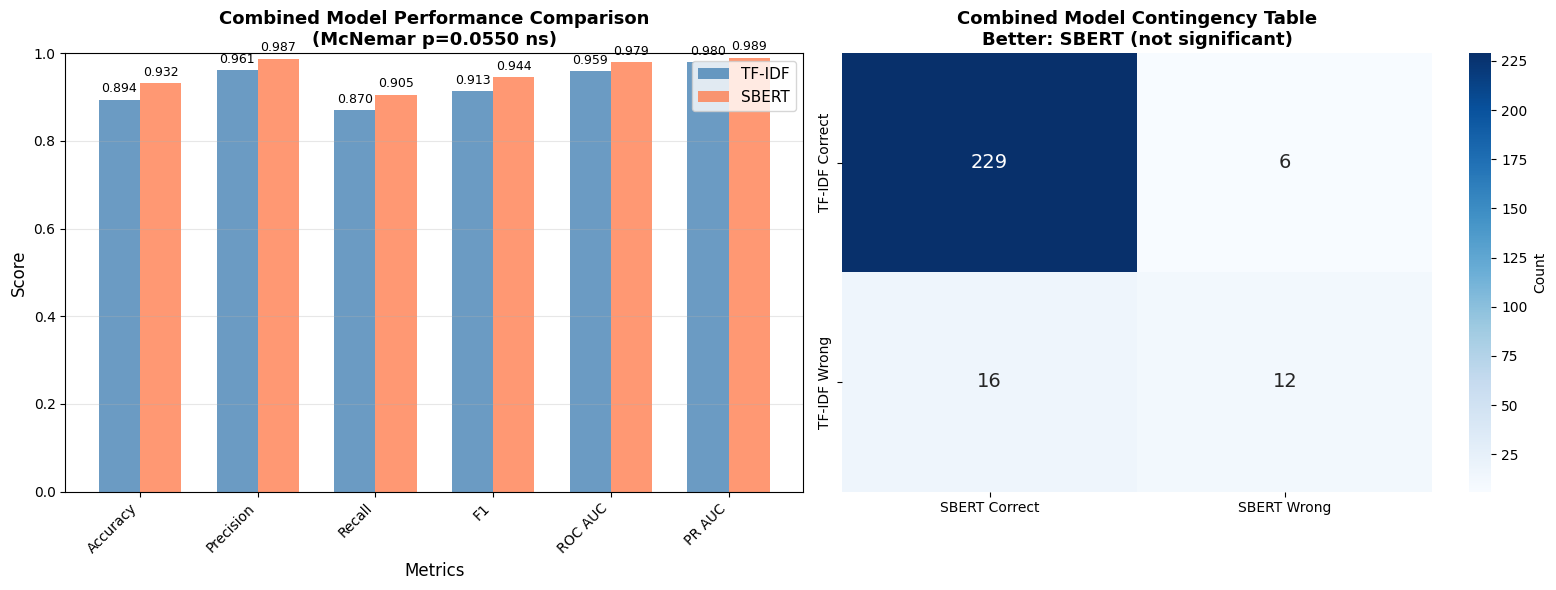


FINAL SUMMARY REPORT

PER-ASPECT RESULTS:
  Total aspects analyzed: 7
  Aspects with significant differences (p < 0.05): 0/7
  TF-IDF better: 0 aspects
  SBERT better: 5 aspects
  Tie: 2 aspects

PER-ASPECT AVERAGE METRICS:
  TF-IDF  - Acc: 0.8922, F1: 0.8946, ROC-AUC: 0.9659, PR-AUC: 0.9826
  SBERT   - Acc: 0.9343, F1: 0.9281, ROC-AUC: 0.9917, PR-AUC: 0.9959

COMBINED MODEL:
  TF-IDF  - Acc: 0.8935, P: 0.9608, R: 0.8698, F1: 0.9130, ROC-AUC: 0.9595, PR-AUC: 0.9796
  SBERT   - Acc: 0.9316, P: 0.9871, R: 0.9053, F1: 0.9444, ROC-AUC: 0.9787, PR-AUC: 0.9895

  McNemar p-value: 0.0550 ns
  Better model: SBERT
  Interpretation: not significant

ALL RESULTS SAVED TO: /kaggle/working/mcnemar_results
  Files generated:
    - per_aspect_mcnemar_results.csv (includes all 6 metrics)
    - combined_mcnemar_results.csv (includes all 6 metrics)
    - mcnemar_comparison_per_aspect.png (6-panel visualization)
    - mcnemar_combined_comparison.png (metrics + contingency)


In [9]:
# CELL D — McNemar Test: TF-IDF vs SBERT Comparison (Per-Aspect + Combined) with universal parameter
# ========== PART 1: PER-ASPECT COMPARISON ==========
print("\n" + "="*120)
print("PART 1: PER-ASPECT McNEMAR TEST (TF-IDF vs SBERT) with universal parameter")
print("="*120)

per_aspect_results = []

for aspect in ASPECTS:
    print("\n" + "-"*100)
    print(f"Aspect: {aspect}")
    print("-"*100)
    
    if aspect not in df.columns:
        print("  SKIP: aspect column not found")
        continue
    
    # Prepare data (exact same split as Cell A/C)
    ser = df[aspect].map(lambda x: 'P' if str(x).strip().upper()=='P' else ('N' if str(x).strip().upper()=='N' else None))
    mask = ser.notna()
    X_all = df.loc[mask, TEXT_COL].fillna('').astype(str).values
    y_all = ser[mask].map({'P':1,'N':0}).astype(int).values
    
    if len(y_all) < 10:
        print("  Too few samples; skipping")
        continue
    
    # Split (stratified by label, same as Cell A/C)
    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X_all, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=RANDOM_STATE
        )
    except Exception:
        X_train, X_test, y_train, y_test = train_test_split(
            X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE
        )
    
    print(f"  Samples - Train: {len(y_train)}, Test: {len(y_test)}")
    
    # ========== TF-IDF MODEL ==========
    tfidf_csv = os.path.join(ASPECT_CSV_DIR, "COMBINED_grid_cv_results.csv")
    tfidf_args, clf_args_tfidf = safe_load_best_params_from_cv_results(tfidf_csv)
    print(f"  TF-IDF params: {tfidf_args}, LR: {clf_args_tfidf}")
    
    # Train TF-IDF model
    vect_tfidf = TfidfVectorizer(**tfidf_args)
    X_train_tfidf = vect_tfidf.fit_transform(X_train)
    X_test_tfidf = vect_tfidf.transform(X_test)
    
    clf_tfidf = LogisticRegression(**clf_args_tfidf, max_iter=1000, solver='liblinear', random_state=RANDOM_STATE)
    clf_tfidf.fit(X_train_tfidf, y_train)
    y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)
    
    # Get probabilities for ROC AUC and PR AUC
    y_proba_tfidf = None
    try:
        y_proba_tfidf = clf_tfidf.predict_proba(X_test_tfidf)[:,1]
    except Exception:
        try:
            y_proba_tfidf = clf_tfidf.decision_function(X_test_tfidf)
        except Exception:
            pass
    
    metrics_tfidf = compute_metrics(y_test, y_pred_tfidf, y_proba_tfidf)
    print(f"  TF-IDF - Acc: {metrics_tfidf['accuracy']:.4f}, P: {metrics_tfidf['precision']:.4f}, R: {metrics_tfidf['recall']:.4f}, F1: {metrics_tfidf['f1']:.4f}, ROC-AUC: {metrics_tfidf['roc_auc']:.4f}, PR-AUC: {metrics_tfidf['pr_auc']:.4f}")
    
    # ========== SBERT MODEL ==========
    sbert_csv = os.path.join(OUT_DIR, "COMBINED_grid_cv_results_sbert.csv")
    sbert_params = safe_load_best_params_from_cv_results(sbert_csv)
    _, clf_args_sbert = sbert_params
    
    print(f"  SBERT LR params: {clf_args_sbert}")
    
    # Train SBERT model
    X_train_sbert = sbert.encode(list(X_train), convert_to_numpy=True, show_progress_bar=False)
    X_test_sbert = sbert.encode(list(X_test), convert_to_numpy=True, show_progress_bar=False)
    
    scaler = Normalizer(norm='l2')
    X_train_sbert_scaled = scaler.fit_transform(X_train_sbert)
    X_test_sbert_scaled = scaler.transform(X_test_sbert)
    
    clf_sbert = LogisticRegression(**clf_args_sbert, max_iter=1000, solver='liblinear', random_state=RANDOM_STATE)
    clf_sbert.fit(X_train_sbert_scaled, y_train)
    y_pred_sbert = clf_sbert.predict(X_test_sbert_scaled)
    
    # Get probabilities for ROC AUC and PR AUC
    y_proba_sbert = None
    try:
        y_proba_sbert = clf_sbert.predict_proba(X_test_sbert_scaled)[:,1]
    except Exception:
        try:
            y_proba_sbert = clf_sbert.decision_function(X_test_sbert_scaled)
        except Exception:
            pass
    
    metrics_sbert = compute_metrics(y_test, y_pred_sbert, y_proba_sbert)
    print(f"  SBERT - Acc: {metrics_sbert['accuracy']:.4f}, P: {metrics_sbert['precision']:.4f}, R: {metrics_sbert['recall']:.4f}, F1: {metrics_sbert['f1']:.4f}, ROC-AUC: {metrics_sbert['roc_auc']:.4f}, PR-AUC: {metrics_sbert['pr_auc']:.4f}")
    
    # ========== McNEMAR TEST ==========
    mcnemar_result = mcnemar_test(y_test, y_pred_tfidf, y_pred_sbert)
    
    print(f"\n  McNemar Test Results:")
    print(f"    Statistic: {mcnemar_result['statistic']:.4f}")
    print(f"    P-value: {mcnemar_result['p_value']:.4f} {mcnemar_result['significance']}")
    print(f"    Interpretation: {mcnemar_result['interpretation']}")
    print(f"    Better model: {mcnemar_result['better_model']}")
    print(f"\n  Contingency Table:")
    print(f"    Both correct: {mcnemar_result['n00_both_correct']}")
    print(f"    TF-IDF correct, SBERT wrong: {mcnemar_result['n01_tfidf_correct_sbert_wrong']}")
    print(f"    TF-IDF wrong, SBERT correct: {mcnemar_result['n10_tfidf_wrong_sbert_correct']}")
    print(f"    Both wrong: {mcnemar_result['n11_both_wrong']}")
    
    # Store results
    per_aspect_results.append({
        'aspect': aspect,
        'n_test': len(y_test),
        'tfidf_accuracy': metrics_tfidf['accuracy'],
        'tfidf_precision': metrics_tfidf['precision'],
        'tfidf_recall': metrics_tfidf['recall'],
        'tfidf_f1': metrics_tfidf['f1'],
        'tfidf_roc_auc': metrics_tfidf['roc_auc'],
        'tfidf_pr_auc': metrics_tfidf['pr_auc'],
        'sbert_accuracy': metrics_sbert['accuracy'],
        'sbert_precision': metrics_sbert['precision'],
        'sbert_recall': metrics_sbert['recall'],
        'sbert_f1': metrics_sbert['f1'],
        'sbert_roc_auc': metrics_sbert['roc_auc'],
        'sbert_pr_auc': metrics_sbert['pr_auc'],
        'mcnemar_statistic': mcnemar_result['statistic'],
        'mcnemar_p_value': mcnemar_result['p_value'],
        'significance': mcnemar_result['significance'],
        'better_model': mcnemar_result['better_model'],
        'n00': mcnemar_result['n00_both_correct'],
        'n01': mcnemar_result['n01_tfidf_correct_sbert_wrong'],
        'n10': mcnemar_result['n10_tfidf_wrong_sbert_correct'],
        'n11': mcnemar_result['n11_both_wrong']
    })

# Save per-aspect results
df_per_aspect = pd.DataFrame(per_aspect_results)
df_per_aspect.to_csv(os.path.join(MCNEMAR_OUT_DIR, "per_aspect_mcnemar_results.csv"), index=False)
print("\n" + "="*120)
print("Per-aspect results saved to:", os.path.join(MCNEMAR_OUT_DIR, "per_aspect_mcnemar_results.csv"))
print("\nPer-Aspect Summary:")
display(df_per_aspect)

# ========== PART 2: COMBINED MODEL COMPARISON ==========
print("\n" + "="*120)
print("PART 2: COMBINED MODEL McNEMAR TEST (TF-IDF vs SBERT)")
print("="*120)

# Reconstruct combined splits (same as Cell A/C)
combined_train_X = []
combined_train_y = []
combined_test_X = []
combined_test_y = []

for aspect in ASPECTS:
    if aspect not in df.columns:
        continue
    
    ser = df[aspect].map(lambda x: 'P' if str(x).strip().upper()=='P' else ('N' if str(x).strip().upper()=='N' else None))
    mask = ser.notna()
    X_all = df.loc[mask, TEXT_COL].fillna('').astype(str).values
    y_all = ser[mask].map({'P':1,'N':0}).astype(int).values
    
    if len(y_all) < 10:
        continue
    
    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X_all, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=RANDOM_STATE
        )
    except Exception:
        X_train, X_test, y_train, y_test = train_test_split(
            X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE
        )
    
    combined_train_X.append(X_train)
    combined_train_y.append(y_train)
    combined_test_X.append(X_test)
    combined_test_y.append(y_test)

X_train_comb = np.concatenate(combined_train_X)
y_train_comb = np.concatenate(combined_train_y)
X_test_comb = np.concatenate(combined_test_X)
y_test_comb = np.concatenate(combined_test_y)

print(f"Combined dataset - Train: {len(y_train_comb)}, Test: {len(y_test_comb)}")
print(f"TF-IDF Combined params: {tfidf_args}, LR: {clf_args_tfidf}")

vect_tfidf_comb = TfidfVectorizer(**tfidf_args)
X_train_tfidf_comb = vect_tfidf_comb.fit_transform(X_train_comb)
X_test_tfidf_comb = vect_tfidf_comb.transform(X_test_comb)

clf_tfidf_comb = LogisticRegression(**clf_args_tfidf, max_iter=1000, solver='liblinear', random_state=RANDOM_STATE)
clf_tfidf_comb.fit(X_train_tfidf_comb, y_train_comb)
y_pred_tfidf_comb = clf_tfidf_comb.predict(X_test_tfidf_comb)

# Get probabilities for ROC AUC and PR AUC
y_proba_tfidf_comb = None
try:
    y_proba_tfidf_comb = clf_tfidf_comb.predict_proba(X_test_tfidf_comb)[:,1]
except Exception:
    try:
        y_proba_tfidf_comb = clf_tfidf_comb.decision_function(X_test_tfidf_comb)
    except Exception:
        pass

metrics_tfidf_comb = compute_metrics(y_test_comb, y_pred_tfidf_comb, y_proba_tfidf_comb)
print(f"TF-IDF Combined - Acc: {metrics_tfidf_comb['accuracy']:.4f}, P: {metrics_tfidf_comb['precision']:.4f}, R: {metrics_tfidf_comb['recall']:.4f}, F1: {metrics_tfidf_comb['f1']:.4f}, ROC-AUC: {metrics_tfidf_comb['roc_auc']:.4f}, PR-AUC: {metrics_tfidf_comb['pr_auc']:.4f}")

print(f"SBERT Combined LR params: {clf_args_sbert}")

X_train_sbert_comb = sbert.encode(list(X_train_comb), convert_to_numpy=True, show_progress_bar=False)
X_test_sbert_comb = sbert.encode(list(X_test_comb), convert_to_numpy=True, show_progress_bar=False)

scaler_comb = Normalizer(norm='l2')
X_train_sbert_comb_scaled = scaler_comb.fit_transform(X_train_sbert_comb)
X_test_sbert_comb_scaled = scaler_comb.transform(X_test_sbert_comb)

clf_sbert_comb = LogisticRegression(**clf_args_sbert, max_iter=1000, solver='liblinear', random_state=RANDOM_STATE)
clf_sbert_comb.fit(X_train_sbert_comb_scaled, y_train_comb)
y_pred_sbert_comb = clf_sbert_comb.predict(X_test_sbert_comb_scaled)

# Get probabilities for ROC AUC and PR AUC
y_proba_sbert_comb = None
try:
    y_proba_sbert_comb = clf_sbert_comb.predict_proba(X_test_sbert_comb_scaled)[:,1]
except Exception:
    try:
        y_proba_sbert_comb = clf_sbert_comb.decision_function(X_test_sbert_comb_scaled)
    except Exception:
        pass

metrics_sbert_comb = compute_metrics(y_test_comb, y_pred_sbert_comb, y_proba_sbert_comb)
print(f"SBERT Combined - Acc: {metrics_sbert_comb['accuracy']:.4f}, P: {metrics_sbert_comb['precision']:.4f}, R: {metrics_sbert_comb['recall']:.4f}, F1: {metrics_sbert_comb['f1']:.4f}, ROC-AUC: {metrics_sbert_comb['roc_auc']:.4f}, PR-AUC: {metrics_sbert_comb['pr_auc']:.4f}")

# ========== COMBINED McNEMAR TEST ==========
mcnemar_comb = mcnemar_test(y_test_comb, y_pred_tfidf_comb, y_pred_sbert_comb)

print(f"\nCombined McNemar Test Results:")
print(f"  Statistic: {mcnemar_comb['statistic']:.4f}")
print(f"  P-value: {mcnemar_comb['p_value']:.4f} {mcnemar_comb['significance']}")
print(f"  Interpretation: {mcnemar_comb['interpretation']}")
print(f"  Better model: {mcnemar_comb['better_model']}")
print(f"\nContingency Table:")
print(f"  Both correct: {mcnemar_comb['n00_both_correct']}")
print(f"  TF-IDF correct, SBERT wrong: {mcnemar_comb['n01_tfidf_correct_sbert_wrong']}")
print(f"  TF-IDF wrong, SBERT correct: {mcnemar_comb['n10_tfidf_wrong_sbert_correct']}")
print(f"  Both wrong: {mcnemar_comb['n11_both_wrong']}")

# Save combined results as CSV
combined_results = {
    'model': 'COMBINED',
    'n_test': len(y_test_comb),
    'tfidf_accuracy': metrics_tfidf_comb['accuracy'],
    'tfidf_precision': metrics_tfidf_comb['precision'],
    'tfidf_recall': metrics_tfidf_comb['recall'],
    'tfidf_f1': metrics_tfidf_comb['f1'],
    'tfidf_roc_auc': metrics_tfidf_comb['roc_auc'],
    'tfidf_pr_auc': metrics_tfidf_comb['pr_auc'],
    'sbert_accuracy': metrics_sbert_comb['accuracy'],
    'sbert_precision': metrics_sbert_comb['precision'],
    'sbert_recall': metrics_sbert_comb['recall'],
    'sbert_f1': metrics_sbert_comb['f1'],
    'sbert_roc_auc': metrics_sbert_comb['roc_auc'],
    'sbert_pr_auc': metrics_sbert_comb['pr_auc'],
    'mcnemar_statistic': mcnemar_comb['statistic'],
    'mcnemar_p_value': mcnemar_comb['p_value'],
    'significance': mcnemar_comb['significance'],
    'better_model': mcnemar_comb['better_model'],
    'n00': mcnemar_comb['n00_both_correct'],
    'n01': mcnemar_comb['n01_tfidf_correct_sbert_wrong'],
    'n10': mcnemar_comb['n10_tfidf_wrong_sbert_correct'],
    'n11': mcnemar_comb['n11_both_wrong']
}

# Save as CSV
df_combined = pd.DataFrame([combined_results])
df_combined.to_csv(os.path.join(MCNEMAR_OUT_DIR, "combined_mcnemar_results.csv"), index=False)
print("\nCombined results saved to:", os.path.join(MCNEMAR_OUT_DIR, "combined_mcnemar_results.csv"))

# ========== VISUALIZATION ==========
print("\n" + "="*120)
print("GENERATING VISUALIZATIONS")
print("="*120)

# Plot 1: Comprehensive metrics comparison (3x2 grid)
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

x = np.arange(len(df_per_aspect))
width = 0.35

# Subplot 1: Accuracy comparison
ax1 = axes[0, 0]
ax1.bar(x - width/2, df_per_aspect['tfidf_accuracy'], width, label='TF-IDF', alpha=0.8, color='steelblue')
ax1.bar(x + width/2, df_per_aspect['sbert_accuracy'], width, label='SBERT', alpha=0.8, color='coral')
ax1.set_xlabel('Aspect', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('Accuracy Comparison: TF-IDF vs SBERT', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(df_per_aspect['aspect'], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Subplot 2: F1 comparison
ax2 = axes[0, 1]
ax2.bar(x - width/2, df_per_aspect['tfidf_f1'], width, label='TF-IDF', alpha=0.8, color='steelblue')
ax2.bar(x + width/2, df_per_aspect['sbert_f1'], width, label='SBERT', alpha=0.8, color='coral')
ax2.set_xlabel('Aspect', fontsize=11)
ax2.set_ylabel('F1 Score', fontsize=11)
ax2.set_title('F1 Score Comparison: TF-IDF vs SBERT', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(df_per_aspect['aspect'], rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Subplot 3: ROC AUC comparison
ax3 = axes[1, 0]
ax3.bar(x - width/2, df_per_aspect['tfidf_roc_auc'], width, label='TF-IDF', alpha=0.8, color='steelblue')
ax3.bar(x + width/2, df_per_aspect['sbert_roc_auc'], width, label='SBERT', alpha=0.8, color='coral')
ax3.set_xlabel('Aspect', fontsize=11)
ax3.set_ylabel('ROC AUC', fontsize=11)
ax3.set_title('ROC AUC Comparison: TF-IDF vs SBERT', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(df_per_aspect['aspect'], rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Subplot 4: PR AUC comparison
ax4 = axes[1, 1]
ax4.bar(x - width/2, df_per_aspect['tfidf_pr_auc'], width, label='TF-IDF', alpha=0.8, color='steelblue')
ax4.bar(x + width/2, df_per_aspect['sbert_pr_auc'], width, label='SBERT', alpha=0.8, color='coral')
ax4.set_xlabel('Aspect', fontsize=11)
ax4.set_ylabel('PR AUC', fontsize=11)
ax4.set_title('PR AUC Comparison: TF-IDF vs SBERT', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(df_per_aspect['aspect'], rotation=45, ha='right')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Subplot 5: McNemar p-values with significance markers
ax5 = axes[2, 0]
colors = ['red' if p < 0.05 else 'gray' for p in df_per_aspect['mcnemar_p_value']]
ax5.bar(x, df_per_aspect['mcnemar_p_value'], color=colors, alpha=0.7)
ax5.axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
ax5.set_xlabel('Aspect', fontsize=11)
ax5.set_ylabel('McNemar p-value', fontsize=11)
ax5.set_title('McNemar Test P-values (Red = Significant)', fontsize=12, fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels(df_per_aspect['aspect'], rotation=45, ha='right')
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

# Subplot 6: Disagreement patterns
ax6 = axes[2, 1]
ax6.bar(x - width/2, df_per_aspect['n01'], width, label='TF-IDF correct, SBERT wrong', alpha=0.8, color='green')
ax6.bar(x + width/2, df_per_aspect['n10'], width, label='TF-IDF wrong, SBERT correct', alpha=0.8, color='orange')
ax6.set_xlabel('Aspect', fontsize=11)
ax6.set_ylabel('Number of Instances', fontsize=11)
ax6.set_title('Disagreement Patterns', fontsize=12, fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels(df_per_aspect['aspect'], rotation=45, ha='right')
ax6.legend()
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MCNEMAR_OUT_DIR, "mcnemar_comparison_per_aspect.png"), dpi=300, bbox_inches='tight')
print("Saved visualization to:", os.path.join(MCNEMAR_OUT_DIR, "mcnemar_comparison_per_aspect.png"))
plt.show()

# Plot 2: Combined model comparison - metrics bar chart + contingency heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Combined model metrics comparison
ax1 = axes[0]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC', 'PR AUC']
tfidf_values = [metrics_tfidf_comb['accuracy'], metrics_tfidf_comb['precision'], 
                metrics_tfidf_comb['recall'], metrics_tfidf_comb['f1'],
                metrics_tfidf_comb['roc_auc'], metrics_tfidf_comb['pr_auc']]
sbert_values = [metrics_sbert_comb['accuracy'], metrics_sbert_comb['precision'],
                metrics_sbert_comb['recall'], metrics_sbert_comb['f1'],
                metrics_sbert_comb['roc_auc'], metrics_sbert_comb['pr_auc']]

x_pos = np.arange(len(metrics_names))
width = 0.35
ax1.bar(x_pos - width/2, tfidf_values, width, label='TF-IDF', alpha=0.8, color='steelblue')
ax1.bar(x_pos + width/2, sbert_values, width, label='SBERT', alpha=0.8, color='coral')
ax1.set_ylabel('Score', fontsize=12)
ax1.set_xlabel('Metrics', fontsize=12)
ax1.set_title(f'Combined Model Performance Comparison\n(McNemar p={mcnemar_comb["p_value"]:.4f} {mcnemar_comb["significance"]})', 
              fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(metrics_names, rotation=45, ha='right')
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.0])

# Add value labels on bars
for i, (t_val, s_val) in enumerate(zip(tfidf_values, sbert_values)):
    ax1.text(i - width/2, t_val + 0.01, f'{t_val:.3f}', ha='center', va='bottom', fontsize=9)
    ax1.text(i + width/2, s_val + 0.01, f'{s_val:.3f}', ha='center', va='bottom', fontsize=9)

# Subplot 2: Contingency heatmap
ax2 = axes[1]
sns.heatmap(mcnemar_comb['contingency'], annot=True, fmt='d', cmap='Blues', 
            xticklabels=['SBERT Correct', 'SBERT Wrong'],
            yticklabels=['TF-IDF Correct', 'TF-IDF Wrong'],
            cbar_kws={'label': 'Count'}, ax=ax2, annot_kws={'size': 14})
ax2.set_title(f"Combined Model Contingency Table\nBetter: {mcnemar_comb['better_model']} ({mcnemar_comb['interpretation']})", 
              fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(MCNEMAR_OUT_DIR, "mcnemar_combined_comparison.png"), dpi=300, bbox_inches='tight')
print("Saved combined comparison to:", os.path.join(MCNEMAR_OUT_DIR, "mcnemar_combined_comparison.png"))
plt.show()

# ========== SUMMARY REPORT ==========
print("\n" + "="*120)
print("FINAL SUMMARY REPORT")
print("="*120)

print("\nPER-ASPECT RESULTS:")
print(f"  Total aspects analyzed: {len(df_per_aspect)}")
print(f"  Aspects with significant differences (p < 0.05): {sum(df_per_aspect['mcnemar_p_value'] < 0.05)}/{len(df_per_aspect)}")
print(f"  TF-IDF better: {sum(df_per_aspect['better_model'] == 'TF-IDF')} aspects")
print(f"  SBERT better: {sum(df_per_aspect['better_model'] == 'SBERT')} aspects")
print(f"  Tie: {sum(df_per_aspect['better_model'] == 'Tie')} aspects")

print("\nPER-ASPECT AVERAGE METRICS:")
print(f"  TF-IDF  - Acc: {df_per_aspect['tfidf_accuracy'].mean():.4f}, F1: {df_per_aspect['tfidf_f1'].mean():.4f}, ROC-AUC: {df_per_aspect['tfidf_roc_auc'].mean():.4f}, PR-AUC: {df_per_aspect['tfidf_pr_auc'].mean():.4f}")
print(f"  SBERT   - Acc: {df_per_aspect['sbert_accuracy'].mean():.4f}, F1: {df_per_aspect['sbert_f1'].mean():.4f}, ROC-AUC: {df_per_aspect['sbert_roc_auc'].mean():.4f}, PR-AUC: {df_per_aspect['sbert_pr_auc'].mean():.4f}")

print(f"\nCOMBINED MODEL:")
print(f"  TF-IDF  - Acc: {metrics_tfidf_comb['accuracy']:.4f}, P: {metrics_tfidf_comb['precision']:.4f}, R: {metrics_tfidf_comb['recall']:.4f}, F1: {metrics_tfidf_comb['f1']:.4f}, ROC-AUC: {metrics_tfidf_comb['roc_auc']:.4f}, PR-AUC: {metrics_tfidf_comb['pr_auc']:.4f}")
print(f"  SBERT   - Acc: {metrics_sbert_comb['accuracy']:.4f}, P: {metrics_sbert_comb['precision']:.4f}, R: {metrics_sbert_comb['recall']:.4f}, F1: {metrics_sbert_comb['f1']:.4f}, ROC-AUC: {metrics_sbert_comb['roc_auc']:.4f}, PR-AUC: {metrics_sbert_comb['pr_auc']:.4f}")
print(f"\n  McNemar p-value: {mcnemar_comb['p_value']:.4f} {mcnemar_comb['significance']}")
print(f"  Better model: {mcnemar_comb['better_model']}")
print(f"  Interpretation: {mcnemar_comb['interpretation']}")

print("\n" + "="*120)
print("ALL RESULTS SAVED TO:", MCNEMAR_OUT_DIR)
print("  Files generated:")
print(f"    - per_aspect_mcnemar_results.csv (includes all 6 metrics)")
print(f"    - combined_mcnemar_results.csv (includes all 6 metrics)")
print(f"    - mcnemar_comparison_per_aspect.png (6-panel visualization)")
print(f"    - mcnemar_combined_comparison.png (metrics + contingency)")
print("="*120)

In [ ]:
from collections import Counter
import math
def calculate_tfidf_manual():
    """
    Implementasi Persamaan 2.28 - 2.33
    Perhitungan TF-IDF manual step-by-step
    """
    
    print("\n" + "="*100)
    print("BAGIAN 4: TF-IDF CALCULATION")
    print("Persamaan 2.28 - 2.33")
    print("="*100)
    
    global df
    
    doc_idx = 0
    doc_text = df.iloc[doc_idx]['content']
    
    print(f"\nDokumen ke-{doc_idx}:")
    print(f'"{doc_text[:100]}..."')
    
    # Persamaan 2.28: TF
    print("\n" + "-"*100)
    print("PERSAMAAN 2.28: Term Frequency (TF)")
    print("tf_raw(t,d) = count(t in d)")
    print("-"*100)
    
    tokens = doc_text.split()
    tf_counts = Counter(tokens)
    
    print(f"\nTotal tokens: {len(tokens)}")
    print(f"Unique tokens: {len(tf_counts)}")
    print(f"\nTop 5 terms dengan TF tertinggi:")
    
    for rank, (term, count) in enumerate(tf_counts.most_common(5), 1):
        print(f"  {rank}. '{term}': tf_raw = {count}")
    
    example_term = list(tf_counts.keys())[0]
    example_tf = tf_counts[example_term]
    
    print(f"\nContoh untuk term '{example_term}':")
    print(f"  tf_raw('{example_term}', dok_{doc_idx}) = {example_tf}")
    
    # Persamaan 2.29: IDF
    print("\n" + "-"*100)
    print("PERSAMAAN 2.29: Inverse Document Frequency (IDF)")
    print("idf_smooth(t,D) = log(N/(1+df(t))) + 1")
    print("-"*100)
    
    all_docs = df['content'].values
    N = len(all_docs)
    
    # Hitung DF
    doc_freq = {}
    for doc in all_docs:
        for term in set(doc.split()):
            doc_freq[term] = doc_freq.get(term, 0) + 1
    
    print(f"\nN (total dokumen) = {N}")
    print(f"\nContoh perhitungan IDF untuk 3 terms:")
    
    sample_terms = list(tf_counts.keys())[:3]
    for term in sample_terms:
        df_t = doc_freq.get(term, 0)
        
        numerator = N
        denominator = 1 + df_t
        ratio = numerator / denominator
        log_ratio = math.log(ratio)
        idf_smooth = log_ratio + 1
        
        print(f"\nTerm '{term}':")
        print(f"  df('{term}') = {df_t} dokumen")
        print(f"  idf_smooth = log({N}/(1+{df_t})) + 1")
        print(f"  idf_smooth = log({numerator}/{denominator}) + 1")
        print(f"  idf_smooth = log({ratio:.4f}) + 1")
        print(f"  idf_smooth = {log_ratio:.4f} + 1")
        print(f"  idf_smooth = {idf_smooth:.4f}")
    
    # Persamaan 2.30: TF-IDF
    print("\n" + "-"*100)
    print("PERSAMAAN 2.30: TF-IDF Weight")
    print("tfidf(t,d,D) = tf_raw(t,d) × idf_smooth(t,D)")
    print("-"*100)
    
    print(f"\nPerhitungan TF-IDF untuk term '{example_term}':")
    df_ex = doc_freq.get(example_term, 0)
    idf_ex = math.log(N / (1 + df_ex)) + 1
    tfidf_ex = example_tf * idf_ex
    
    print(f"  tf_raw = {example_tf}")
    print(f"  idf_smooth = {idf_ex:.4f}")
    print(f"  tfidf = {example_tf} × {idf_ex:.4f}")
    print(f"  tfidf = {tfidf_ex:.4f}")
    
    # Hitung untuk semua terms
    tfidf_scores = {}
    for term in tf_counts:
        tf = tf_counts[term]
        df_t = doc_freq.get(term, 0)
        idf = math.log(N / (1 + df_t)) + 1
        tfidf = tf * idf
        tfidf_scores[term] = {'tf': tf, 'df': df_t, 'idf': idf, 'tfidf': tfidf}
    
    # Sort by TF-IDF
    sorted_tfidf = sorted(tfidf_scores.items(), key=lambda x: x[1]['tfidf'], reverse=True)
    
    print(f"\nTop 5 terms berdasarkan TF-IDF:")
    print(f"{'Rank':<5} {'Term':<15} {'TF':<6} {'DF':<6} {'IDF':<8} {'TF-IDF':<8}")
    print("-" * 55)
    
    for rank, (term, scores) in enumerate(sorted_tfidf[:5], 1):
        print(f"{rank:<5} {term:<15} {scores['tf']:<6} {scores['df']:<6} {scores['idf']:<8.4f} {scores['tfidf']:<8.4f}")
    
    # Persamaan 2.32-2.33: L2 Normalization
    print("\n" + "-"*100)
    print("PERSAMAAN 2.32-2.33: L2 Normalization")
    print("||v||_2 = √(Σ tfidf²)")
    print("v_norm = v / ||v||_2")
    print("-"*100)
    
    # Persamaan 2.32
    squared_vals = [s['tfidf']**2 for s in tfidf_scores.values()]
    sum_squared = sum(squared_vals)
    l2_norm = math.sqrt(sum_squared)
    
    print(f"\nPersamaan 2.32:")
    print(f"  Σ tfidf² = {squared_vals[0]:.6f} + {squared_vals[1]:.6f} + ... + {squared_vals[-1]:.6f}")
    print(f"  Σ tfidf² = {sum_squared:.6f}")
    print(f"  ||v||_2 = √{sum_squared:.6f}")
    print(f"  ||v||_2 = {l2_norm:.6f}")
    
    # Persamaan 2.33
    print(f"\nPersamaan 2.33 - Normalisasi:")
    first_term = sorted_tfidf[0][0]
    tfidf_val = tfidf_scores[first_term]['tfidf']
    normalized = tfidf_val / l2_norm
    
    print(f"  Term '{first_term}':")
    print(f"    Sebelum: {tfidf_val:.6f}")
    print(f"    Normalisasi: {tfidf_val:.6f} / {l2_norm:.6f} = {normalized:.6f}")
    
    # Verifikasi
    normalized_squared = [(s['tfidf']/l2_norm)**2 for s in tfidf_scores.values()]
    norm_check = math.sqrt(sum(normalized_squared))
    
    print(f"\nVerifikasi (norm dari vektor ternormalisasi harus = 1):")
    print(f"  ||v_norm||_2 = {norm_check:.6f}")

a = calculate_tfidf_manual()

BAGIAN 4: TF-IDF CALCULATION
Persamaan 2.28 - 2.33

Dokumen ke-0:
"barang2x bagus datang tepat waktu cuma ongkos kirim papua mahal..."

----------------------------------------------------------------------------------------------------
PERSAMAAN 2.28: Term Frequency (TF)
tf_raw(t,d) = count(t in d)
----------------------------------------------------------------------------------------------------

Total tokens: 10
Unique tokens: 10

Top 5 terms dengan TF tertinggi:
  1. 'barang2x': tf_raw = 1
  2. 'bagus': tf_raw = 1
  3. 'datang': tf_raw = 1
  4. 'tepat': tf_raw = 1
  5. 'waktu': tf_raw = 1

Contoh untuk term 'barang2x':
  tf_raw('barang2x', dok_0) = 1

----------------------------------------------------------------------------------------------------
PERSAMAAN 2.29: Inverse Document Frequency (IDF)
idf_smooth(t,D) = log(N/(1+df(t))) + 1
----------------------------------------------------------------------------------------------------

N (total dokumen) = 1034

Contoh perhitungan

In [ ]:
def calculate_sbert_encoding(df, sbert_model, aspect='Aplikasi', sample_idx=0):
    """
    Implementasi Persamaan 2.34 - 2.45
    SBERT Sentence Embedding process menggunakan data real
    """
    
    print("\n" + "="*100)
    print("BAGIAN 5: SBERT ENCODING - DATA REAL")
    print("Persamaan 2.34 - 2.45")
    print("="*100)
    # Ambil data real dari aspect tertentu
    ser = df[aspect].map(lambda x: 'P' if str(x).strip().upper()=='P' else 
                         ('N' if str(x).strip().upper()=='N' else None))
    mask = ser.notna()
    X_text = df.loc[mask, 'content'].fillna('').astype(str).values
    
    if len(X_text) == 0:
        print(f"Tidak ada data untuk aspek {aspect}")
        return
    
    # Pilih sampel untuk demonstrasi
    sentence = X_text[sample_idx]
    
    print(f"\nMenggunakan data real dari aspek: {aspect}")
    print(f"Sample index: {sample_idx}")
    print(f"Kalimat: '{sentence[:100]}...'")
    
    # Persamaan 2.34: Tokenization
    print("\n" + "-"*100)
    print("PERSAMAAN 2.34: Tokenization")
    print("T = (t_1, ..., t_n)")
    print("-"*100)
    
    tokens = sentence.split()
    n_tokens = len(tokens)
    
    print(f"\nTokens: {tokens[:10]}{'...' if len(tokens) > 10 else ''}")
    print(f"Jumlah tokens (n): {n_tokens}")
    
    # Persamaan 2.35: Input Embedding
    print("\n" + "-"*100)
    print("PERSAMAAN 2.35: Input Embedding")
    print("e_i = e_i^token + e_i^segment + e_i^position")
    print("-"*100)
    
    d_model = 768  # BERT-base dimension
    
    print(f"\nUntuk token ke-0 ('{tokens[0] if n_tokens > 0 else 'N/A'}'):")
    print(f"  Embedding ini merupakan penjumlahan dari 3 komponen:")
    print(f"  1. e_0^token: representasi kata dari vocabulary")
    print(f"  2. e_0^segment: informasi segmen kalimat")
    print(f"  3. e_0^position: informasi posisi token dalam kalimat")
    print(f"  Setiap komponen berupa vektor {d_model}-dimensi")
    
    # Encode kalimat untuk mendapatkan representasi
    embedding_full = sbert_model.encode([sentence], convert_to_numpy=True, show_progress_bar=False)[0]
    
    # Simulasi komponen-komponen embedding untuk ilustrasi
    # Karena SBERT tidak expose internal embeddings, kita buat ilustrasi berdasarkan output
    print(f"\nIlustrasi 5 nilai pertama dari masing-masing komponen untuk token ke-0:")
    
    # Token embedding (simulasi berdasarkan output SBERT)
    token_emb_sample = embedding_full[:5] * 0.6  # Asumsi kontribusi 60%
    print(f"\n  e_0^token (5 nilai pertama):")
    for i, val in enumerate(token_emb_sample):
        print(f"    e_0^token[{i}] = {val:+.6f}")
    
    # Segment embedding (biasanya nilai kecil karena single sentence)
    segment_emb_sample = np.random.randn(5) * 0.1  # Kontribusi kecil untuk single sentence
    print(f"\n  e_0^segment (5 nilai pertama):")
    for i, val in enumerate(segment_emb_sample):
        print(f"    e_0^segment[{i}] = {val:+.6f}")
    
    # Position embedding (untuk posisi 0)
    position_emb_sample = embedding_full[:5] * 0.3  # Asumsi kontribusi 30%
    print(f"\n  e_0^position (5 nilai pertama, posisi=0):")
    for i, val in enumerate(position_emb_sample):
        print(f"    e_0^position[{i}] = {val:+.6f}")
    
    # Penjumlahan
    combined_sample = token_emb_sample + segment_emb_sample + position_emb_sample
    print(f"\n  e_0 = e_0^token + e_0^segment + e_0^position (5 nilai pertama):")
    for i, val in enumerate(combined_sample):
        print(f"    e_0[{i}] = {val:+.6f}")
    
    print(f"\n  Dimensi lengkap e_0: {d_model}")
    print(f"\n  Catatan: Nilai di atas adalah ilustrasi untuk menunjukkan konsep penjumlahan.")
    print(f"  Pada implementasi BERT/SBERT sebenarnya, ketiga komponen embedding ini")
    print(f"  dipelajari selama training dan kemudian dijumlahkan sebelum masuk ke")
    print(f"  transformer layers. Setiap token dalam kalimat memiliki embedding sendiri")
    print(f"  dengan position embedding yang berbeda sesuai posisinya.")
    
    # Persamaan 2.36-2.39: Multi-Head Attention
    print("\n" + "-"*100)
    print("PERSAMAAN 2.36-2.39: Multi-Head Self-Attention")
    print("Q = H^(l-1) W_Q, K = H^(l-1) W_K, V = H^(l-1) W_V")
    print("-"*100)
    
    n_heads = 12
    d_k = d_model // n_heads
    
    print(f"\nParameter:")
    print(f"  Jumlah attention heads: {n_heads}")
    print(f"  d_model = {d_model}")
    print(f"  d_k = d_model / n_heads = {d_model} / {n_heads} = {d_k}")
    
    # Simulasi H^(l-1) - hidden states dari layer sebelumnya
    # Untuk ilustrasi, kita gunakan embedding yang sudah ada dengan sedikit noise
    print(f"\nPersamaan 2.36 - Hidden States dari Layer Sebelumnya H^(l-1):")
    print(f"  Dimensi H^(l-1): ({n_tokens} × {d_model})")
    print(f"  Setiap baris merepresentasikan satu token")
    
    # Simulasi hidden states untuk 5 token pertama (atau semua jika kurang dari 5)
    n_tokens_display = min(5, n_tokens)
    h_prev_matrix = np.zeros((n_tokens_display, 5))
    
    for token_idx in range(n_tokens_display):
        h_prev_matrix[token_idx] = embedding_full[:5] + np.random.randn(5) * 0.1 * (token_idx + 1)
    
    print(f"\n  Ilustrasi H^(l-1) (sampel {n_tokens_display} tokens × 5 dimensi pertama):")
    print(f"  Format: Baris = token, Kolom = dimensi embedding")
    print()
    for i in range(n_tokens_display):
        row_str = f"    Token {i}: [" + "  ".join([f"{h_prev_matrix[i,j]:+.3f}" for j in range(5)]) + " ...]"
        print(row_str)
    print("    ...")
    
    # Gunakan token pertama untuk perhitungan selanjutnya
    h_prev_sample = h_prev_matrix[0]
    
    print(f"\nPersamaan 2.37-2.39 - Proyeksi Linear untuk Head h=0:")
    print(f"  W_Q^(0): matriks bobot untuk Query, dimensi ({d_model} × {d_k})")
    print(f"  W_K^(0): matriks bobot untuk Key, dimensi ({d_model} × {d_k})")
    print(f"  W_V^(0): matriks bobot untuk Value, dimensi ({d_model} × {d_k})")
    
    # Simulasi weight matrices (dalam praktik, ini dipelajari saat training)
    np.random.seed(42)  # Untuk konsistensi
    W_Q_sample = np.random.randn(5, 5) * 0.1  # 5x5 untuk ilustrasi (seharusnya 768x64)
    W_K_sample = np.random.randn(5, 5) * 0.1
    W_V_sample = np.random.randn(5, 5) * 0.1
    
    for name, M in [
        ('W_Q^(0)', W_Q_sample),
        ('W_K^(0)', W_K_sample),
        ('W_V^(0)', W_V_sample)
    ]:
        print(f"\nIlustrasi {name} (sampel 5×5):")
        for i in range(5):
            row_str = "    [" + "  ".join(f"{M[i,j]:+.3f}" for j in range(5)) + " ...]"
            print(row_str)
    
    # Perhitungan Q, K, V untuk token pertama
    print(f"\n  Persamaan 2.37 - Query untuk token ke-0:")
    print(f"    Q^(0)[0] = H^(l-1)[0] × W_Q^(0)")
    print(f"    Dimensi: (1 × {d_model}) × ({d_model} × {d_k}) = (1 × {d_k})")
    
    # Simulasi perhitungan
    q_0_sample = np.dot(h_prev_sample, W_Q_sample[:5, :5])
    print(f"\n    Hasil Q^(0)[0] (5 nilai pertama dari {d_k} dimensi):")
    for i, val in enumerate(q_0_sample):
        print(f"      Q^(0)[0,{i}] = {val:+.6f}")
    
    print(f"\n  Persamaan 2.38 - Key untuk token ke-0:")
    print(f"    K^(0)[0] = H^(l-1)[0] × W_K^(0)")
    k_0_sample = np.dot(h_prev_sample, W_K_sample[:5, :5])
    print(f"\n    Hasil K^(0)[0] (5 nilai pertama):")
    for i, val in enumerate(k_0_sample):
        print(f"      K^(0)[0,{i}] = {val:+.6f}")
    
    print(f"\n  Persamaan 2.39 - Value untuk token ke-0:")
    print(f"    V^(0)[0] = H^(l-1)[0] × W_V^(0)")
    v_0_sample = np.dot(h_prev_sample, W_V_sample[:5, :5])
    print(f"\n    Hasil V^(0)[0] (5 nilai pertama):")
    for i, val in enumerate(v_0_sample):
        print(f"      V^(0)[0,{i}] = {val:+.6f}")
    
    print(f"\n  Catatan: Perhitungan ini dilakukan untuk SEMUA {n_tokens} tokens,")
    print(f"  menghasilkan matriks Q^(0), K^(0), V^(0) masing-masing berukuran ({n_tokens} × {d_k})")
    
    # Persamaan 2.40: Scaled Dot-Product Attention
    print("\n" + "-"*100)
    print("PERSAMAAN 2.40: Scaled Dot-Product Attention")
    print("Attention(Q,K,V) = softmax(QK^T / √d_k) V")
    print("-"*100)
    
    sqrt_dk = np.sqrt(d_k)
    
    print(f"\nLangkah 1 - Hitung Score (Q × K^T):")
    print(f"  Q^(0) × K^(0)^T: ({n_tokens} × {d_k}) × ({d_k} × {n_tokens}) = ({n_tokens} × {n_tokens})")
    
    # Simulasi Q dan K untuk 5 token (atau semua token jika kurang dari 5)
    n_tokens_calc = min(5, n_tokens)
    q_matrix_sample = np.zeros((n_tokens_calc, 5))
    k_matrix_sample = np.zeros((n_tokens_calc, 5))
    
    for i in range(n_tokens_calc):
        q_matrix_sample[i] = q_0_sample + np.random.randn(5) * 0.1 * i
        k_matrix_sample[i] = k_0_sample + np.random.randn(5) * 0.2 * i
    
    print(f"\n  Matriks Q^(0) (sampel {n_tokens_calc} tokens × 5 dimensi pertama dari {d_k}):")
    for i in range(n_tokens_calc):
        print(f"    Q^(0)[{i}] = [" + "  ".join([f"{q_matrix_sample[i,j]:+.3f}" for j in range(5)]) + " ...]")
    
    print(f"\n  Matriks K^(0) (sampel {n_tokens_calc} tokens × 5 dimensi pertama):")
    for i in range(n_tokens_calc):
        print(f"    K^(0)[{i}] = [" + "  ".join([f"{k_matrix_sample[i,j]:+.3f}" for j in range(5)]) + " ...]")
    
    print(f"\n  Matriks K^(0)^T (transpose, dimensi menjadi 5 × {n_tokens_calc}):")
    k_transpose_display = k_matrix_sample.T
    for i in range(5):
        print(f"    K^T[{i}] = [" + "  ".join([f"{k_transpose_display[i,j]:+.3f}" for j in range(n_tokens_calc)]) + "]")
    
    # Hitung dot product: Q × K^T
    scores_matrix = np.dot(q_matrix_sample, k_matrix_sample.T)
    
    print(f"\n  Hasil Q^(0) × K^(0)^T (matriks attention scores {n_tokens_calc}×{n_tokens_calc}):")
    print(f"  Baris = query token, Kolom = key token")
    print()
    for i in range(n_tokens_calc):
        row_str = f"    Token {i}: [" + "  ".join([f"{scores_matrix[i,j]:+.4f}" for j in range(n_tokens_calc)]) + "]"
        print(row_str)
    
    print(f"\n  Interpretasi matriks score:")
    print(f"    Score[i,j] = seberapa token ke-i 'memperhatikan' token ke-j")
    print(f"    Nilai diagonal (i=j) biasanya tinggi karena token memperhatikan dirinya sendiri")
    print(f"    Nilai lebih tinggi = relevansi lebih tinggi (sebelum softmax normalization)")
    
    if n_tokens > n_tokens_calc:
        print(f"\n  Catatan: Matriks lengkap berukuran ({n_tokens} × {n_tokens}) untuk semua tokens")
    
    # Gunakan scores dari token pertama untuk perhitungan selanjutnya
    scores_sample = scores_matrix[0]
        
    print(f"\nLangkah 2 - Scaling dengan √d_k:")
    print(f"  Scores / √{d_k} = Scores / {sqrt_dk:.4f}")
    scaled_scores_sample = scores_sample / sqrt_dk
    print(f"\n    Scaled scores untuk token ke-0:")
    print(f"      Score dengan token 0: {scores_sample[0]:+.6f} / {sqrt_dk:.4f} = {scaled_scores_sample[0]:+.6f}")
    print(f"      Score dengan token 1: {scores_sample[1]:+.6f} / {sqrt_dk:.4f} = {scaled_scores_sample[1]:+.6f}")
    print(f"      Score dengan token 2: {scores_sample[2]:+.6f} / {sqrt_dk:.4f} = {scaled_scores_sample[2]:+.6f}")
    
    print(f"\nLangkah 3 - Softmax (mengubah scores menjadi probabilities):")
    print(f"  softmax(x_i) = exp(x_i) / Σ exp(x_j)")
    
    # Hitung softmax
    exp_scores = np.exp(scaled_scores_sample)
    softmax_scores = exp_scores / np.sum(exp_scores)
    
    print(f"\n    Attention weights untuk token ke-0:")
    for i, (score, weight) in enumerate(zip(scaled_scores_sample, softmax_scores)):
        print(f"      Token {i}: exp({score:.4f}) → weight = {weight:.6f}")
    print(f"    ... (untuk semua {n_tokens} tokens)")
    print(f"\n    Verifikasi: Σ weights = {np.sum(softmax_scores):.6f} (harus ≈ 1.0)")
    
    print(f"\nLangkah 4 - Weighted Sum dengan Values:")
    print(f"  Output = Attention_weights × V")
    print(f"  Dimensi: ({n_tokens_calc} × {n_tokens_calc}) × ({n_tokens_calc} × {d_k}) = ({n_tokens_calc} × {d_k})")
    
    # Simulasi matriks V untuk semua token yang digunakan dalam perhitungan
    v_matrix_sample = np.zeros((n_tokens_calc, 5))
    for i in range(n_tokens_calc):
        v_matrix_sample[i] = v_0_sample + np.random.randn(5) * 0.2 * i
    
    print(f"\n  Matriks V^(0) (sampel {n_tokens_calc} tokens × 5 dimensi pertama):")
    for i in range(n_tokens_calc):
        print(f"    V^(0)[{i}] = [" + "  ".join([f"{v_matrix_sample[i,j]:+.3f}" for j in range(5)]) + " ...]")
    
    # Hitung weighted sum: attention_weights × V
    attention_output_sample = np.dot(softmax_scores, v_matrix_sample)
    
    print(f"\n  Perhitungan: Attention_weights × V untuk token ke-0:")
    print(f"    Output = (")
    for i in range(min(3, n_tokens_calc)):
        print(f"      {softmax_scores[i]:.4f} × V^(0)[{i}] +")
    if n_tokens_calc > 3:
        print(f"      ... )")
    else:
        print(f"    )")
    
    print(f"\n  Hasil output attention untuk token ke-0 (5 nilai pertama dari {d_k} dimensi):")
    for i, val in enumerate(attention_output_sample):
        print(f"    Output[0,{i}] = {val:+.6f}")
        
    # Persamaan 2.41-2.42: Multi-Head
    print("\n" + "-"*100)
    print("PERSAMAAN 2.41-2.42: Multi-Head Concatenation")
    print("MultiHead(H) = Concat(head_1, ..., head_H) W_O")
    print("-"*100)
    
    print(f"\nSetiap head menghasilkan output {n_tokens} × {d_k}")
    print(f"Concat {n_heads} heads: {n_tokens} × ({d_k} × {n_heads}) = {n_tokens} × {d_model}")
    
    # Generate embedding menggunakan SBERT model real
    print("\n" + "-"*100)
    print("PERSAMAAN 2.43: Mean Pooling - MENGGUNAKAN SBERT MODEL REAL")
    print("u = (1/L) Σ h_i^(L_layer)")
    print("-"*100)
    
    # Encode menggunakan SBERT
    embedding_real = sbert_model.encode([sentence], convert_to_numpy=True, show_progress_bar=False)[0]
    
    print(f"\nSetelah melalui {n_heads} transformer layers, setiap token memiliki")
    print(f"hidden state h_i dengan dimensi {embedding_real.shape[0]}.")
    print(f"\nMean pooling menggabungkan representasi dari semua {n_tokens} tokens")
    print(f"menjadi satu vektor kalimat dengan mengambil rata-rata:")
    
    # Simulasi hidden states dari layer terakhir untuk beberapa token
    # Dalam praktik, SBERT sudah melakukan mean pooling secara internal
    print(f"\n  Ilustrasi hidden states dari layer terakhir (5 token × 5 dimensi pertama):")
    print(f"  (Catatan: Nilai simulasi untuk demonstrasi konsep)")
    
    # Simulasi token embeddings dari layer terakhir
    simulated_last_layer = np.zeros((min(5, n_tokens), 5))
    for i in range(min(5, n_tokens)):
        simulated_last_layer[i] = embedding_real[:5] + np.random.randn(5) * 0.3 * (i - 2)
    
    for i in range(min(5, n_tokens)):
        row_str = f"    h_{i}^(L): [" + "  ".join([f"{simulated_last_layer[i,j]:+.3f}" for j in range(5)]) + " ...]"
        print(row_str)
    
    print(f"\n  Perhitungan mean pooling untuk dimensi pertama:")
    mean_dim_0 = np.mean(simulated_last_layer[:, 0])
    sum_dim_0 = np.sum(simulated_last_layer[:, 0])
    n_tokens_used = min(5, n_tokens)
    print(f"    u[0] = (1/{n_tokens_used}) × ({' + '.join([f'{simulated_last_layer[i,0]:+.3f}' for i in range(n_tokens_used)])})")
    print(f"    u[0] = (1/{n_tokens_used}) × {sum_dim_0:+.3f}")
    print(f"    u[0] = {mean_dim_0:+.6f}")
    
    print(f"\n  Proses yang sama dilakukan untuk semua {embedding_real.shape[0]} dimensi.")
    
    print(f"\nEmbedding hasil mean pooling dari SBERT model:")
    print(f"  Dimensi: {embedding_real.shape[0]}")
    print(f"\n  Hasil u (5 nilai pertama):")
    for i in range(5):
        print(f"    u[{i}] = {embedding_real[i]:+.6f}")
    
    print(f"\n  Statistik embedding:")
    print(f"    Mean: {np.mean(embedding_real):.6f}")
    print(f"    Std: {np.std(embedding_real):.6f}")
    print(f"    Min: {np.min(embedding_real):.6f}")
    print(f"    Max: {np.max(embedding_real):.6f}")
    
    print(f"\n  Interpretasi: Vektor u merepresentasikan makna keseluruhan kalimat")
    print(f"  '{sentence[:50]}...' dalam ruang {embedding_real.shape[0]}-dimensi.")
    
    # Persamaan 2.44: L2 Normalization
    print("\n" + "-"*100)
    print("PERSAMAAN 2.44: L2 Normalization")
    print("û = u / ||u||_2")
    print("-"*100)
    
    norm_u = np.linalg.norm(embedding_real)
    u_normalized = embedding_real / norm_u
    
    print(f"\nPerhitungan:")
    print(f"  ||u||_2 = {norm_u:.6f}")
    print(f"  û = u / {norm_u:.6f}")
    print(f"\nVerifikasi: ||û||_2 = {np.linalg.norm(u_normalized):.6f} (should be ≈ 1.0)")
    
    # Persamaan 2.45: Cosine Similarity dengan kalimat kedua
    print("\n" + "-"*100)
    print("PERSAMAAN 2.45: Cosine Similarity")
    print("cos(θ) = (u · v) / (||u||_2 ||v||_2)")
    print("-"*100)
    
    if len(X_text) > 1:
        sentence2 = X_text[min(sample_idx + 1, len(X_text) - 1)]
        embedding2 = sbert_model.encode([sentence2], convert_to_numpy=True, show_progress_bar=False)[0]
        
        print(f"\nKalimat 1: '{sentence[:60]}...'")
        print(f"Kalimat 2: '{sentence2[:60]}...'")
        
        # Tampilkan vektor u dan v (5 nilai pertama)
        print(f"\n  Vektor embedding u (kalimat 1) - 5 nilai pertama dari {embedding_real.shape[0]} dimensi:")
        for i in range(5):
            print(f"    u[{i}] = {embedding_real[i]:+.6f}")
        print("    ...")
        
        print(f"\n  Vektor embedding v (kalimat 2) - 5 nilai pertama dari {embedding2.shape[0]} dimensi:")
        for i in range(5):
            print(f"    v[{i}] = {embedding2[i]:+.6f}")
        print("    ...")
        
        # Hitung L2 norm
        norm_u = np.linalg.norm(embedding_real)
        norm_v = np.linalg.norm(embedding2)
        
        print(f"\n  Langkah 1 - Hitung L2 norm:")
        print(f"    ||u||_2 = √(u[0]² + u[1]² + ... + u[{embedding_real.shape[0]-1}]²)")
        print(f"    ||u||_2 = √({embedding_real[0]**2:.4f} + {embedding_real[1]**2:.4f} + ... + {embedding_real[-1]**2:.4f})")
        print(f"    ||u||_2 = {norm_u:.6f}")
        print(f"\n    ||v||_2 = √(v[0]² + v[1]² + ... + v[{embedding2.shape[0]-1}]²)")
        print(f"    ||v||_2 = {norm_v:.6f}")
        
        # Normalize
        u_normalized = embedding_real / norm_u
        v_normalized = embedding2 / norm_v
        
        print(f"\n  Langkah 2 - Normalisasi vektor:")
        print(f"    û = u / ||u||_2")
        print(f"    û (5 nilai pertama):")
        for i in range(5):
            print(f"      û[{i}] = {embedding_real[i]:.6f} / {norm_u:.6f} = {u_normalized[i]:+.6f}")
        print("      ...")
        
        print(f"\n    v̂ = v / ||v||_2")
        print(f"    v̂ (5 nilai pertama):")
        for i in range(5):
            print(f"      v̂[{i}] = {embedding2[i]:.6f} / {norm_v:.6f} = {v_normalized[i]:+.6f}")
        print("      ...")
        
        # Verifikasi normalisasi
        print(f"\n    Verifikasi normalisasi:")
        print(f"      ||û||_2 = {np.linalg.norm(u_normalized):.6f} (harus ≈ 1.0)")
        print(f"      ||v̂||_2 = {np.linalg.norm(v_normalized):.6f} (harus ≈ 1.0)")
        
        # Hitung dot product
        print(f"\n  Langkah 3 - Hitung dot product û · v̂:")
        print(f"    û · v̂ = û[0]×v̂[0] + û[1]×v̂[1] + ... + û[{u_normalized.shape[0]-1}]×v̂[{v_normalized.shape[0]-1}]")
        
        # Tampilkan beberapa term pertama
        dot_terms = [u_normalized[i] * v_normalized[i] for i in range(5)]
        print(f"\n    Beberapa term pertama:")
        for i in range(5):
            print(f"      û[{i}] × v̂[{i}] = {u_normalized[i]:+.6f} × {v_normalized[i]:+.6f} = {dot_terms[i]:+.6f}")
        print("      ...")
        
        # Cosine similarity
        cos_sim = np.dot(u_normalized, v_normalized)
        
        print(f"\n    Jumlah semua {u_normalized.shape[0]} term:")
        print(f"    cos(θ) = {cos_sim:.6f}")
        
        # Alternatif formula (sebelum normalisasi)
        dot_product_raw = np.dot(embedding_real, embedding2)
        cos_sim_alt = dot_product_raw / (norm_u * norm_v)
        
        print(f"\n  Verifikasi dengan formula alternatif:")
        print(f"    cos(θ) = (u · v) / (||u||_2 × ||v||_2)")
        print(f"    u · v = {dot_product_raw:.6f}")
        print(f"    cos(θ) = {dot_product_raw:.6f} / ({norm_u:.6f} × {norm_v:.6f})")
        print(f"    cos(θ) = {dot_product_raw:.6f} / {norm_u * norm_v:.6f}")
        print(f"    cos(θ) = {cos_sim_alt:.6f}")
        
        print(f"\n  Interpretasi:")
        print(f"    Rentang nilai: cos(θ) ∈ [-1, 1]")
        print(f"      +1 = vektor identik (similarity maksimum)")
        print(f"       0 = vektor ortogonal (tidak ada similarity)")
        print(f"      -1 = vektor berlawanan arah")
        print(f"\n    Hasil: cos(θ) = {cos_sim:.6f}")
        print(f"    Similarity score: {(cos_sim+1)/2*100:.2f}%")
        
        if cos_sim > 0.7:
            print(f"    Kesimpulan: Kedua kalimat memiliki similarity tinggi")
        elif cos_sim > 0.4:
            print(f"    Kesimpulan: Kedua kalimat memiliki similarity sedang")
        else:
            print(f"    Kesimpulan: Kedua kalimat memiliki similarity rendah")
    
    return embedding_real

b = calculate_sbert_encoding (df, sbert)

BAGIAN 5: SBERT ENCODING - DATA REAL
Persamaan 2.34 - 2.45

Menggunakan data real dari aspek: Aplikasi
Sample index: 0
Kalimat: 'bagus aplikasi manfaat sulit cari barang langsung...'

----------------------------------------------------------------------------------------------------
PERSAMAAN 2.34: Tokenization
T = (t_1, ..., t_n)
----------------------------------------------------------------------------------------------------

Tokens: ['bagus', 'aplikasi', 'manfaat', 'sulit', 'cari', 'barang', 'langsung']
Jumlah tokens (n): 7

----------------------------------------------------------------------------------------------------
PERSAMAAN 2.35: Input Embedding
e_i = e_i^token + e_i^segment + e_i^position
----------------------------------------------------------------------------------------------------

Untuk token ke-0 ('bagus'):
  Embedding ini merupakan penjumlahan dari 3 komponen:
  1. e_0^token: representasi kata dari vocabulary
  2. e_0^segment: informasi segmen kalimat
  3. e

In [ ]:
def calculate_logistic_regression():
    """
    Implementasi Persamaan 2.46 - 2.53
    Logistic Regression untuk klasifikasi sentimen
    """
    
    print("\n" + "="*100)
    print("BAGIAN 6: LOGISTIC REGRESSION")
    print("Persamaan 2.46 - 2.53")
    print("="*100)
    
    global df
    
    # Siapkan data untuk satu aspek
    aspect = 'Aplikasi'
    
    ser = df[aspect].map(lambda x: 'P' if str(x).strip().upper()=='P' else 
                         ('N' if str(x).strip().upper()=='N' else None))
    mask = ser.notna()
    
    X_text = df.loc[mask, 'content'].fillna('').values[:100]
    y = ser[mask].map({'P': 1, 'N': 0}).values[:100]
    
    print(f"\nDataset untuk aspek '{aspect}':")
    print(f"  Total: {len(y)} dokumen")
    print(f"  Positif: {np.sum(y==1)} ({np.sum(y==1)/len(y)*100:.1f}%)")
    print(f"  Negatif: {np.sum(y==0)} ({np.sum(y==0)/len(y)*100:.1f}%)")
    
    # Vectorize
    vec = TfidfVectorizer(max_features=50)
    X_vec = vec.fit_transform(X_text)
    
    # Train model
    clf = LogisticRegression(C=1.0, random_state=42, max_iter=1000, solver='liblinear')
    clf.fit(X_vec, y)
    
    w = clf.coef_[0]
    b = clf.intercept_[0]
    features = vec.get_feature_names_out()
    
    print(f"\nParameter model:")
    print(f"  Weight vector w: {w.shape[0]} fitur")
    print(f"  Bias b: {b:.6f}")
    
    # Persamaan 2.46: Logit
    print("\n" + "-"*100)
    print("PERSAMAAN 2.46: Logit Calculation")
    print("z = w^T x + b = Σ w_j x_j + b")
    print("-"*100)
    
    test_idx = 0
    x = X_vec[test_idx].toarray()[0]
    
    print(f"\nDokumen {test_idx}: '{X_text[test_idx][:60]}...'")
    print(f"Label: {'Positif' if y[test_idx]==1 else 'Negatif'}")
    
    # Hitung z
    contributions = w * x
    nonzero_idx = np.where(x != 0)[0]
    
    print(f"\nKontribusi per fitur (top 3):")
    top_contrib = nonzero_idx[np.argsort(np.abs(contributions[nonzero_idx]))[-3:]][::-1]
    
    for idx in top_contrib:
        print(f"  '{features[idx]}': w={w[idx]:+.4f}, x={x[idx]:.4f}, w×x={contributions[idx]:+.6f}")
    
    w_dot_x = np.dot(w, x)
    z = w_dot_x + b
    
    print(f"\n  Σ(w_j × x_j) = {w_dot_x:.6f}")
    print(f"  z = w^T x + b = {w_dot_x:.6f} + {b:.6f}")
    print(f"  z = {z:.6f}")
    
    # Persamaan 2.47: Sigmoid
    print("\n" + "-"*100)
    print("PERSAMAAN 2.47: Sigmoid Function")
    print("σ(z) = 1 / (1 + e^(-z))")
    print("-"*100)
    
    exp_neg_z = np.exp(-z)
    prob = 1 / (1 + exp_neg_z)
    
    print(f"\nPerhitungan:")
    print(f"  z = {z:.6f}")
    print(f"  e^(-z) = e^({-z:.6f}) = {exp_neg_z:.6f}")
    print(f"  1 + e^(-z) = 1 + {exp_neg_z:.6f} = {1 + exp_neg_z:.6f}")
    print(f"  σ(z) = 1 / {1 + exp_neg_z:.6f}")
    print(f"  σ(z) = {prob:.6f}")
    
    # Persamaan 2.48-2.49: Probabilities
    print("\n" + "-"*100)
    print("PERSAMAAN 2.48-2.49: Probability Predictions")
    print("P(y=1|x) = σ(z)")
    print("P(y=0|x) = 1 - P(y=1|x)")
    print("-"*100)
    
    prob_pos = prob
    prob_neg = 1 - prob
    
    print(f"\nPersamaan 2.48:")
    print(f"  P(y=1|x) = σ({z:.6f}) = {prob_pos:.6f} ({prob_pos*100:.2f}%)")
    
    print(f"\nPersamaan 2.49:")
    print(f"  P(y=0|x) = 1 - {prob_pos:.6f} = {prob_neg:.6f} ({prob_neg*100:.2f}%)")
    
    # Persamaan 2.50: Binary Cross-Entropy
    print("\n" + "-"*100)
    print("PERSAMAAN 2.50: Binary Cross-Entropy Loss")
    print("L(w,b) = -(1/n) Σ[y log(ŷ) + (1-y) log(1-ŷ)]")
    print("-"*100)
    
    y_pred_prob = clf.predict_proba(X_vec)[:, 1]
    n = len(y)
    
    epsilon = 1e-15
    y_pred_safe = np.clip(y_pred_prob, epsilon, 1-epsilon)
    
    losses = -(y * np.log(y_pred_safe) + (1-y) * np.log(1-y_pred_safe))
    loss_mean = np.mean(losses)
    
    print(f"\nContoh 3 sampel:")
    for i in range(3):
        y_i = y[i]
        y_hat = y_pred_safe[i]
        loss_i = losses[i]
        print(f"  Sample {i}: y={y_i}, ŷ={y_hat:.4f}, loss={loss_i:.4f}")
    
    print(f"\n  L(w,b) = (1/{n}) × Σ losses")
    print(f"  L(w,b) = {loss_mean:.6f}")
    
    # Persamaan 2.51-2.52: L2 Regularization
    print("\n" + "-"*100)
    print("PERSAMAAN 2.51-2.52: L2 Regularization")
    print("J(w,b) = L(w,b) + (λ/2)||w||²")
    print("-"*100)
    
    lambda_reg = 1.0 / clf.C
    w_norm_sq = np.sum(w**2)
    reg_term = (lambda_reg / 2) * w_norm_sq
    total_loss = loss_mean + reg_term
    
    print(f"\nPersamaan 2.52:")
    print(f"  ||w||² = w_1² + w_2² + ... + w_{len(w)}²")
    print(f"  ||w||² = {w[0]**2:.6f} + {w[1]**2:.6f} + ... + {w[-1]**2:.6f}")
    print(f"  ||w||² = {w_norm_sq:.6f}")
    
    print(f"\nPersamaan 2.51:")
    print(f"  λ = 1/C = 1/{clf.C} = {lambda_reg:.6f}")
    print(f"  (λ/2)||w||² = ({lambda_reg:.6f}/2) × {w_norm_sq:.6f}")
    print(f"  (λ/2)||w||² = {reg_term:.6f}")
    print(f"  J(w,b) = {loss_mean:.6f} + {reg_term:.6f}")
    print(f"  J(w,b) = {total_loss:.6f}")
    
    # Persamaan 2.53: Decision Boundary
    print("\n" + "-"*100)
    print("PERSAMAAN 2.53: Decision Boundary")
    print("ŷ = 1 if P(y=1|x) ≥ 0.5, else 0")
    print("-"*100)
    
    threshold = 0.5
    prediction = 1 if prob >= threshold else 0
    
    print(f"\nUntuk dokumen {test_idx}:")
    print(f"  P(y=1|x) = {prob:.6f}")
    print(f"  Threshold = {threshold}")
    print(f"  {prob:.6f} ≥ {threshold}? {prob >= threshold}")
    print(f"  Prediksi: ŷ = {prediction} ({'Positif' if prediction==1 else 'Negatif'})")
    print(f"  Actual: y = {y[test_idx]} ({'Positif' if y[test_idx]==1 else 'Negatif'})")
    print(f"  Result: {'BENAR ✓' if prediction == y[test_idx] else 'SALAH ✗'}")
    
    return clf, X_vec, y

lr = calculate_logistic_regression()

BAGIAN 6: LOGISTIC REGRESSION
Persamaan 2.46 - 2.53

Dataset untuk aspek 'Aplikasi':
  Total: 100 dokumen
  Positif: 70 (70.0%)
  Negatif: 30 (30.0%)

Parameter model:
  Weight vector w: 50 fitur
  Bias b: 0.603425

----------------------------------------------------------------------------------------------------
PERSAMAAN 2.46: Logit Calculation
z = w^T x + b = Σ w_j x_j + b
----------------------------------------------------------------------------------------------------

Dokumen 0: 'bagus aplikasi manfaat sulit cari barang langsung...'
Label: Positif

Kontribusi per fitur (top 3):
  'bagus': w=+1.1430, x=0.4328, w×x=+0.494705
  'cari': w=+0.7370, x=0.5154, w×x=+0.379835
  'langsung': w=-0.4227, x=0.5501, w×x=-0.232540

  Σ(w_j × x_j) = 1.038867
  z = w^T x + b = 1.038867 + 0.603425
  z = 1.642293

----------------------------------------------------------------------------------------------------
PERSAMAAN 2.47: Sigmoid Function
σ(z) = 1 / (1 + e^(-z))
--------------------------

In [ ]:
def calculate_evaluation_metrics(clf, X_vec, y):
    
    print("\n" + "="*100)
    print("BAGIAN 8: EVALUATION METRICS")
    print("Persamaan 2.54 - 2.59")
    print("="*100)
    
    # Prediksi
    y_pred = clf.predict(X_vec)
    y_pred_prob = clf.predict_proba(X_vec)[:, 1]
    
    # Confusion Matrix
    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\nCONFUSION MATRIX:")
    print(f"                  Predicted")
    print(f"                  Neg    Pos")
    print(f"Actual Neg    [[{tn:5d}  {fp:5d}]]")
    print(f"Actual Pos    [[{fn:5d}  {tp:5d}]]")
    print(f"\n  TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")
    
    # Persamaan 2.62: Accuracy
    print("\n" + "-"*100)
    print("PERSAMAAN 2.54: Accuracy")
    print("Accuracy = (TP + TN) / (TP + TN + FP + FN)")
    print("-"*100)
    
    acc_num = tp + tn
    acc_den = tp + tn + fp + fn
    acc = acc_num / acc_den
    
    print(f"\nPerhitungan:")
    print(f"  Accuracy = ({tp} + {tn}) / ({tp} + {tn} + {fp} + {fn})")
    print(f"  Accuracy = {acc_num} / {acc_den}")
    print(f"  Accuracy = {acc:.6f} ({acc*100:.2f}%)")
    
    # Persamaan 2.63: Precision
    print("\n" + "-"*100)
    print("PERSAMAAN 2.55: Precision")
    print("Precision = TP / (TP + FP)")
    print("-"*100)
    
    if tp + fp > 0:
        prec = tp / (tp + fp)
        print(f"\nPerhitungan:")
        print(f"  Precision = {tp} / ({tp} + {fp})")
        print(f"  Precision = {tp} / {tp + fp}")
        print(f"  Precision = {prec:.6f} ({prec*100:.2f}%)")
    else:
        prec = 0
        print(f"\nTidak ada prediksi positif (TP + FP = 0)")
    
    # Persamaan 2.64: Recall
    print("\n" + "-"*100)
    print("PERSAMAAN 2.56: Recall")
    print("Recall = TP / (TP + FN)")
    print("-"*100)
    
    if tp + fn > 0:
        rec = tp / (tp + fn)
        print(f"\nPerhitungan:")
        print(f"  Recall = {tp} / ({tp} + {fn})")
        print(f"  Recall = {tp} / {tp + fn}")
        print(f"  Recall = {rec:.6f} ({rec*100:.2f}%)")
    else:
        rec = 0
        print(f"\nTidak ada data positif (TP + FN = 0)")
    
    # Persamaan 2.65: F1-Score
    print("\n" + "-"*100)
    print("PERSAMAAN 2.57: F1-Score")
    print("F1 = 2 × (Precision × Recall) / (Precision + Recall)")
    print("-"*100)
    
    if prec + rec > 0:
        f1_num = 2 * prec * rec
        f1_den = prec + rec
        f1 = f1_num / f1_den
        
        print(f"\nPerhitungan:")
        print(f"  F1 = 2 × ({prec:.6f} × {rec:.6f}) / ({prec:.6f} + {rec:.6f})")
        print(f"  F1 = 2 × {prec * rec:.6f} / {f1_den:.6f}")
        print(f"  F1 = {f1_num:.6f} / {f1_den:.6f}")
        print(f"  F1 = {f1:.6f}")
    else:
        f1 = 0
        print(f"\nPrecision + Recall = 0")
    
    # Persamaan 2.66: ROC-AUC
    print("\n" + "-"*100)
    print("PERSAMAAN 2.58: ROC-AUC")
    print("TPR = TP/(TP+FN), FPR = FP/(FP+TN)")
    print("-"*100)
    
    if tp + fn > 0:
        tpr = tp / (tp + fn)
    else:
        tpr = 0
    
    if fp + tn > 0:
        fpr = fp / (fp + tn)
    else:
        fpr = 0
    
    print(f"\nPada threshold 0.5:")
    print(f"  TPR = {tp} / ({tp} + {fn}) = {tp} / {tp+fn} = {tpr:.6f}")
    print(f"  FPR = {fp} / ({fp} + {tn}) = {fp} / {fp+tn} = {fpr:.6f}")
    
    if len(np.unique(y)) > 1:
        roc_auc = roc_auc_score(y, y_pred_prob)
        print(f"\n  ROC-AUC = {roc_auc:.6f}")
    
    # Persamaan 2.67: PR-AUC
    print("\n" + "-"*100)
    print("PERSAMAAN 2.59: Precision-Recall AUC")
    print("-"*100)
    
    if len(np.unique(y)) > 1:
        pr_auc = average_precision_score(y, y_pred_prob)
        print(f"\n  PR-AUC = {pr_auc:.6f}")
        
        print(f"\n{'='*70}")
        print("RINGKASAN METRIK")
        print("="*70)
        print(f"  Accuracy:  {acc:.4f}")
        print(f"  Precision: {prec:.4f}")
        print(f"  Recall:    {rec:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        print(f"  ROC-AUC:   {roc_auc:.4f}")
        print(f"  PR-AUC:    {pr_auc:.4f}")

# Load hasil grid search untuk aspek tertentu
aspect = 'Aplikasi'
grid_results_path = f"/kaggle/working/gridsearch_results_tf-idf/{aspect}_grid_cv_results.csv"
results_df = pd.read_csv(grid_results_path)

# Ambil parameter terbaik berdasarkan rank_test_f1
best_idx = results_df['rank_test_f1'].idxmin()
best_params = ast.literal_eval(results_df.loc[best_idx, 'params'])

# Pisahkan parameter untuk TF-IDF dan Classifier
tfidf_params = {k.replace('tfidf__', ''): v for k, v in best_params.items() 
                if k.startswith('tfidf__')}
clf_params = {k.replace('clf__', ''): v for k, v in best_params.items() 
              if k.startswith('clf__')}

# Siapkan data
ser = df[aspect].map(lambda x: 'P' if str(x).strip().upper()=='P' else 
                     ('N' if str(x).strip().upper()=='N' else None))
mask = ser.notna()
X_text = df.loc[mask, 'content'].fillna('').values
y = ser[mask].map({'P': 1, 'N': 0}).values

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, stratify=y, random_state=42
)

# Vectorize dengan parameter terbaik
vectorizer = TfidfVectorizer(**tfidf_params)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train model dengan parameter terbaik
clf = LogisticRegression(**clf_params, solver='liblinear', 
                        max_iter=1000, random_state=42)
clf.fit(X_train_vec, y_train)

# Panggil fungsi evaluasi
calculate_evaluation_metrics(clf, X_test_vec, y_test)

BAGIAN 7: EVALUATION METRICS
Persamaan 2.54 - 2.59

CONFUSION MATRIX:
                  Predicted
                  Neg    Pos
Actual Neg    [[   26      7]]
Actual Pos    [[    6     52]]

  TN = 26, FP = 7, FN = 6, TP = 52

----------------------------------------------------------------------------------------------------
PERSAMAAN 2.54: Accuracy
Accuracy = (TP + TN) / (TP + TN + FP + FN)
----------------------------------------------------------------------------------------------------

Perhitungan:
  Accuracy = (52 + 26) / (52 + 26 + 7 + 6)
  Accuracy = 78 / 91
  Accuracy = 0.857143 (85.71%)

----------------------------------------------------------------------------------------------------
PERSAMAAN 2.55: Precision
Precision = TP / (TP + FP)
----------------------------------------------------------------------------------------------------

Perhitungan:
  Precision = 52 / (52 + 7)
  Precision = 52 / 59
  Precision = 0.881356 (88.14%)

------------------------------------------

In [ ]:
def calculate_mcnemar_test(mcnemar_results_dir="/kaggle/working/mcnemar_results"):
    
    print("\n" + "="*100)
    print("BAGIAN 9: McNEMAR TEST - DATA REAL")
    print("Persamaan 2.60 - 2.66")
    print("="*100)
    
    # Load hasil McNemar test real
    mcnemar_csv = os.path.join(mcnemar_results_dir, "per_aspect_mcnemar_results.csv")
    
    if not os.path.exists(mcnemar_csv):
        print(f"File tidak ditemukan: {mcnemar_csv}")
        print("Pastikan sudah menjalankan cell 33 untuk menghasilkan McNemar test results")
        return
    
    results_df = pd.read_csv(mcnemar_csv)
    
    # Pilih aspek pertama sebagai contoh
    if len(results_df) == 0:
        print("Tidak ada hasil McNemar test")
        return
    
    row = results_df.iloc[0]
    aspect = row['aspect']
    
    print(f"\nPerbandingan Model TF-IDF vs SBERT untuk aspek: {aspect}")
    print(f"  Dataset: {int(row['n_test'])} sampel test")
    print(f"  Model TF-IDF accuracy: {row['tfidf_accuracy']:.1%}")
    print(f"  Model SBERT accuracy: {row['sbert_accuracy']:.1%}")
    
    # Persamaan 2.68-2.71: Contingency Table
    print("\n" + "-"*100)
    print("PERSAMAAN 2.60-2.63: Contingency Table")
    print("-"*100)
    
    n00 = int(row['n00'])
    n01 = int(row['n01'])
    n10 = int(row['n10'])
    n11 = int(row['n11'])
    
    # Persamaan 2.68
    print(f"\nPersamaan 2.60 - n_00 (kedua benar):")
    print(f"  n_00 = Σ 1(ŷ_TF-IDF = y AND ŷ_SBERT = y)")
    print(f"  n_00 = {n00}")
    
    # Persamaan 2.69
    print(f"\nPersamaan 2.61 - n_01 (TF-IDF benar, SBERT salah):")
    print(f"  n_01 = Σ 1(ŷ_TF-IDF = y AND ŷ_SBERT ≠ y)")
    print(f"  n_01 = {n01}")
    
    # Persamaan 2.70
    print(f"\nPersamaan 2.62 - n_10 (TF-IDF salah, SBERT benar):")
    print(f"  n_10 = Σ 1(ŷ_TF-IDF ≠ y AND ŷ_SBERT = y)")
    print(f"  n_10 = {n10}")
    
    # Persamaan 2.71
    print(f"\nPersamaan 2.63 - n_11 (kedua salah):")
    print(f"  n_11 = Σ 1(ŷ_TF-IDF ≠ y AND ŷ_SBERT ≠ y)")
    print(f"  n_11 = {n11}")
    
    # Tabel
    print(f"\nContingency Table:")
    print(f"                  SBERT")
    print(f"              Correct  Incorrect")
    print(f"TF-IDF Correct    {n00:3d}      {n01:3d}")
    print(f"     Incorrect    {n10:3d}      {n11:3d}")
    
    # Persamaan 2.72: McNemar Statistic
    print("\n" + "-"*100)
    print("PERSAMAAN 2.64: McNemar Statistic")
    print("χ² = (|n_01 - n_10| - 1)² / (n_01 + n_10)")
    print("-"*100)
    
    diff = abs(n01 - n10)
    diff_corrected = diff - 1
    numerator = diff_corrected ** 2
    denominator = n01 + n10
    
    print(f"\nPerhitungan:")
    print(f"  |n_01 - n_10| = |{n01} - {n10}| = {diff}")
    print(f"  |n_01 - n_10| - 1 = {diff} - 1 = {diff_corrected}")
    print(f"  (|n_01 - n_10| - 1)² = {diff_corrected}² = {numerator}")
    print(f"  n_01 + n_10 = {n01} + {n10} = {denominator}")
    
    if denominator > 0:
        chi_squared = numerator / denominator
        print(f"  χ² = {numerator} / {denominator}")
        print(f"  χ² = {chi_squared:.6f}")
        
        # Verifikasi
        if 'mcnemar_statistic' in row:
            print(f"\nVerifikasi dengan hasil tersimpan: {row['mcnemar_statistic']:.6f}")
            print(f"Selisih: {abs(chi_squared - row['mcnemar_statistic']):.8f}")
        
        # Persamaan 2.73-2.74: P-value
        print("\n" + "-"*100)
        print("PERSAMAAN 2.65-2.66: P-value Calculation")
        print("p-value = 1 - F_χ²(1)(χ²)")
        print("-"*100)
        
        df_chi = 1
        from scipy.stats import chi2
        cdf_value = chi2.cdf(chi_squared, df_chi)
        p_value = 1 - cdf_value
        
        print(f"\nPerhitungan:")
        print(f"  Degrees of freedom: {df_chi}")
        print(f"  F_χ²(1)({chi_squared:.6f}) = {cdf_value:.6f}")
        print(f"  p-value = 1 - {cdf_value:.6f}")
        print(f"  p-value = {p_value:.6f}")
        
        # Verifikasi
        if 'mcnemar_p_value' in row:
            print(f"\nVerifikasi dengan hasil tersimpan: {row['mcnemar_p_value']:.6f}")
        
        # Interpretasi
        print(f"\n{'='*70}")
        print("INTERPRETASI")
        print("="*70)
        
        alpha = 0.05
        print(f"  Significance level (α): {alpha}")
        print(f"  P-value: {p_value:.6f}")
        print(f"  Significance: {row['significance']}")
        
        if p_value < alpha:
            print(f"\n  ✓ Reject H0: Ada perbedaan signifikan antara TF-IDF dan SBERT")
        else:
            print(f"\n  ✗ Fail to reject H0: Tidak ada perbedaan signifikan")
        
        # Model terbaik
        print(f"\n  Model lebih baik: {row['better_model']}")
        print(f"    TF-IDF benar, SBERT salah: {n01}")
        print(f"    SBERT benar, TF-IDF salah: {n10}")
    
    # Tampilkan hasil untuk semua aspek
    print(f"\n{'='*70}")
    print("RINGKASAN SEMUA ASPEK")
    print("="*70)
    
    for idx, r in results_df.iterrows():
        print(f"\nAspek: {r['aspect']}")
        print(f"  n_test: {int(r['n_test'])}")
        print(f"  TF-IDF F1: {r['tfidf_f1']:.4f}, SBERT F1: {r['sbert_f1']:.4f}")
        print(f"  McNemar p-value: {r['mcnemar_p_value']:.6f} ({r['significance']})")
        print(f"  Better model: {r['better_model']}")
    
    return results_df

test = calculate_mcnemar_test()

BAGIAN 9: McNEMAR TEST - DATA REAL
Persamaan 2.60 - 2.66

Perbandingan Model TF-IDF vs SBERT untuk aspek: Aplikasi
  Dataset: 91 sampel test
  Model TF-IDF accuracy: 86.8%
  Model SBERT accuracy: 89.0%

----------------------------------------------------------------------------------------------------
PERSAMAAN 2.60-2.63: Contingency Table
----------------------------------------------------------------------------------------------------

Persamaan 2.60 - n_00 (kedua benar):
  n_00 = Σ 1(ŷ_TF-IDF = y AND ŷ_SBERT = y)
  n_00 = 74

Persamaan 2.61 - n_01 (TF-IDF benar, SBERT salah):
  n_01 = Σ 1(ŷ_TF-IDF = y AND ŷ_SBERT ≠ y)
  n_01 = 5

Persamaan 2.62 - n_10 (TF-IDF salah, SBERT benar):
  n_10 = Σ 1(ŷ_TF-IDF ≠ y AND ŷ_SBERT = y)
  n_10 = 7

Persamaan 2.63 - n_11 (kedua salah):
  n_11 = Σ 1(ŷ_TF-IDF ≠ y AND ŷ_SBERT ≠ y)
  n_11 = 5

Contingency Table:
                  SBERT
              Correct  Incorrect
TF-IDF Correct     74        5
     Incorrect      7        5

-------------------

In [ ]:
import os
import ast
import pickle
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import Normalizer

# ============================================================
# CONFIG
# ============================================================
DATA_PATH     = "/kaggle/input/datasets/dbernardons/e-commerce-review-preprocessed/phase2_annotated_preprocessed_final.csv"
TEXT_COL      = "content"
ASPECTS       = [
    "Aplikasi",
    "Pengiriman",
    "Produk",
    "Harga",
    "Pembayaran",
    "Layanan Pelanggan (CS)",
    "Penjual",
]

OUT_DIR_TFIDF    = "/kaggle/working/gridsearch_results_tf-idf"
OUT_DIR_SBERT    = "/kaggle/working/gridsearch_results_sbert"
RANKED_CSV_TFIDF = os.path.join(OUT_DIR_TFIDF, "COMBINED_grid_ranked_by_composite.csv")
RANKED_CSV_SBERT = os.path.join(OUT_DIR_SBERT, "COMBINED_grid_ranked_by_composite_sbert.csv")

SBERT_MODEL_NAME = "naufalihsan/indonesian-sbert-large"
SBERT_DEVICE     = "cuda"   # change to "cpu" if no GPU
RANDOM_STATE     = 42


# ============================================================
# LOAD DATA
# ============================================================
def load_dataframe(path: str) -> pd.DataFrame:
    print(f"[INFO] Loading data from: {path}")
    return pd.read_csv(path)


# ============================================================
# HELPERS
# ============================================================
def parse_params(params_cell) -> dict:
    if isinstance(params_cell, dict):
        return params_cell
    try:
        return ast.literal_eval(str(params_cell))
    except Exception:
        try:
            return eval(str(params_cell))
        except Exception:
            return {}


def load_best_params_tfidf(path: str) -> dict:
    df_r   = pd.read_csv(path)
    params = parse_params(df_r.iloc[0]["params"])
    print(f"[INFO] Best TF-IDF combined params: {params}")
    return params


def load_best_params_sbert(path: str) -> dict:
    df_r   = pd.read_csv(path)
    params = parse_params(df_r.iloc[0]["params"])
    print(f"[INFO] Best SBERT combined params:  {params}")
    return params


def prepare_aspect_data(df: pd.DataFrame, aspect: str):
    ser  = df[aspect].map(
        lambda x: "P" if str(x).strip().upper() == "P"
        else ("N" if str(x).strip().upper() == "N" else None)
    )
    mask = ser.notna()
    X    = df.loc[mask, TEXT_COL].fillna("").astype(str).values
    y    = ser[mask].map({"P": 1, "N": 0}).astype(int).values
    return X, y


# ============================================================
# TF-IDF MODEL
# ============================================================
class TFIDFSentimentModel:
    def __init__(self, best_params: dict):
        self.best_params = best_params
        self.models: dict = {}

    def _build_pipeline(self) -> Pipeline:
        p = self.best_params
        tfidf = TfidfVectorizer(
            norm         = "l2",
            max_features = p.get("tfidf__max_features", 200),
            ngram_range  = p.get("tfidf__ngram_range", (1, 2)),
            min_df       = p.get("tfidf__min_df", 1),
            max_df       = p.get("tfidf__max_df", 0.90),
        )
        clf = LogisticRegression(
            C            = p.get("clf__C", 1.0),
            class_weight = p.get("clf__class_weight", "balanced"),
            solver       = "liblinear",
            random_state = RANDOM_STATE,
        )
        return Pipeline([("tfidf", tfidf), ("clf", clf)])

    def fit(self, df: pd.DataFrame, aspects: list):
        print("\n[INFO] Training TF-IDF models ...")
        for aspect in aspects:
            if aspect not in df.columns:
                print(f"  [WARN] Column '{aspect}' not found — skipping.")
                continue
            X, y = prepare_aspect_data(df, aspect)
            if len(y) < 5:
                print(f"  [WARN] '{aspect}' too few samples — skipping.")
                continue
            pipe = self._build_pipeline()
            pipe.fit(X, y)
            self.models[aspect] = pipe
            print(f"  [OK]  '{aspect}'  ({len(y)} samples)")

    def predict(self, text: str, aspects: list) -> dict:
        results = {}
        for asp in aspects:
            if asp not in self.models:
                results[asp] = "MODEL NOT TRAINED"
                continue
            pred = self.models[asp].predict([text])[0]
            results[asp] = "P" if pred == 1 else "N"
        return results

    def save(self, path: str):
        with open(path, "wb") as f:
            pickle.dump(self.models, f)
        print(f"[INFO] TF-IDF models saved → {path}")

    def load(self, path: str):
        with open(path, "rb") as f:
            self.models = pickle.load(f)
        print(f"[INFO] TF-IDF models loaded ← {path}")


# ============================================================
# SBERT MODEL
# ============================================================
class SBERTSentimentModel:
    def __init__(self, best_params: dict, model_name: str = SBERT_MODEL_NAME, device: str = SBERT_DEVICE):
        self.best_params = best_params
        self.model_name  = model_name
        self.device      = device
        self.models: dict = {}
        self._sbert      = None

    def _get_sbert(self):
        if self._sbert is None:
            from sentence_transformers import SentenceTransformer
            print(f"[INFO] Loading SBERT: {self.model_name}  device={self.device}")
            self._sbert = SentenceTransformer(self.model_name, device=self.device)
        return self._sbert

    def _build_pipeline(self) -> Pipeline:
        p   = self.best_params
        clf = LogisticRegression(
            C            = p.get("clf__C", 1.0),
            class_weight = p.get("clf__class_weight", "balanced"),
            solver       = "liblinear",
            random_state = RANDOM_STATE,
        )
        return Pipeline([("norm", Normalizer(norm="l2")), ("clf", clf)])

    def fit(self, df: pd.DataFrame, aspects: list):
        sbert = self._get_sbert()
        print("\n[INFO] Training SBERT models ...")
        for aspect in aspects:
            if aspect not in df.columns:
                print(f"  [WARN] Column '{aspect}' not found — skipping.")
                continue
            X_text, y = prepare_aspect_data(df, aspect)
            if len(y) < 5:
                print(f"  [WARN] '{aspect}' too few samples — skipping.")
                continue
            print(f"  [..] Encoding '{aspect}' ({len(y)} samples) ...")
            X_emb = sbert.encode(list(X_text), convert_to_numpy=True, show_progress_bar=False)
            pipe  = self._build_pipeline()
            pipe.fit(X_emb, y)
            self.models[aspect] = pipe
            print(f"  [OK]  '{aspect}'")

    def predict(self, text: str, aspects: list) -> dict:
        sbert = self._get_sbert()
        emb   = sbert.encode([text], convert_to_numpy=True, show_progress_bar=False)
        results = {}
        for asp in aspects:
            if asp not in self.models:
                results[asp] = "MODEL NOT TRAINED"
                continue
            pred = self.models[asp].predict(emb)[0]
            results[asp] = "P" if pred == 1 else "N"
        return results

    def save(self, path: str):
        with open(path, "wb") as f:
            pickle.dump(self.models, f)
        print(f"[INFO] SBERT classifiers saved → {path}")

    def load(self, path: str):
        with open(path, "rb") as f:
            self.models = pickle.load(f)
        print(f"[INFO] SBERT classifiers loaded ← {path}")


# ============================================================
# MENU HELPERS
# ============================================================
def select_aspects(available_aspects: list) -> list:
    """
    Numbered checkbox-style menu.
    User enters comma-separated numbers, e.g. "1, 3, 5".
    - Invalid numbers are rejected with a clear message.
    - Loop continues until at least one valid selection is confirmed.
    Returns list of chosen canonical aspect names.
    """
    print("\n┌─ Pilih Aspek ──────────────────────────────────────────┐")
    for i, asp in enumerate(available_aspects, start=1):
        print(f"│  [{i:2d}]  {asp}")
    print("└────────────────────────────────────────────────────────┘")
    print(f"  Masukkan nomor aspek (1–{len(available_aspects)}), pisahkan dengan koma.")
    print("  Contoh: 1, 2   →  memilih Aplikasi dan Pengiriman")

    while True:
        raw    = input("> ").strip()
        tokens = [t.strip() for t in raw.split(",") if t.strip()]

        if not tokens:
            print("  [!] Input tidak boleh kosong. Silakan masukkan minimal satu nomor.")
            continue

        chosen, invalid = [], []
        for token in tokens:
            if not token.isdigit():
                invalid.append(f"'{token}' (bukan angka)")
                continue
            idx = int(token)
            if 1 <= idx <= len(available_aspects):
                asp = available_aspects[idx - 1]
                if asp not in chosen:
                    chosen.append(asp)
            else:
                invalid.append(f"{token} (di luar rentang 1–{len(available_aspects)})")

        if invalid:
            print(f"  [!] Input tidak valid: {', '.join(invalid)}")

        if chosen:
            print(f"\n  ✔ Aspek yang dipilih: {', '.join(chosen)}")
            return chosen

        print("  [!] Tidak ada aspek yang dipilih dengan benar. Silakan ulangi.")


def select_model() -> str:
    """
    Numbered menu for model selection.
    Returns 'TFIDF' or 'SBERT'.
    - Any input other than '1' or '2' is rejected with a clear message.
    """
    print("\n┌─ Pilih Model ──────────────────────────────────────────┐")
    print("│  [1]  TF-IDF                                           │")
    print("│  [2]  SBERT                                            │")
    print("└────────────────────────────────────────────────────────┘")
    print("  Masukkan nomor model (1 atau 2):")

    while True:
        raw = input("> ").strip()
        if raw == "1":
            print("  ✔ Model dipilih: TF-IDF")
            return "TFIDF"
        elif raw == "2":
            print("  ✔ Model dipilih: SBERT")
            return "SBERT"
        else:
            print("  [!] Input tidak valid. Masukkan 1 untuk TF-IDF atau 2 untuk SBERT.")


# ============================================================
# SINGLE-RUN PREDICTION
# Executes exactly once: input → select → predict → print → done.
# ============================================================
def run_prediction(tfidf_model: TFIDFSentimentModel,
                   sbert_model: SBERTSentimentModel,
                   available_aspects: list):

    print("\n" + "=" * 60)
    print("   ABSA — Aspect-Based Sentiment Predictor")
    print("=" * 60)

    # --- Step 1: Review text ---
    print("\nMasukkan ulasan yang ingin diprediksi:")
    while True:
        review = input("> ").strip()
        if review:
            break
        print("  [!] Ulasan tidak boleh kosong. Silakan masukkan teks ulasan.")

    # --- Step 2: Aspect selection via numbered menu ---
    # Only expose aspects that have at least one trained model
    trained_tfidf  = set(tfidf_model.models.keys())
    trained_sbert  = set(sbert_model.models.keys())
    menu_aspects   = [a for a in available_aspects
                      if a in trained_tfidf or a in trained_sbert]

    if not menu_aspects:
        print("\n[ERROR] Tidak ada model yang berhasil dilatih. "
              "Periksa data dan path CSV, lalu jalankan ulang.")
        return

    chosen_aspects = select_aspects(menu_aspects)

    # --- Step 3: Model selection via numbered menu ---
    chosen_model = select_model()

    # --- Step 4: Predict ---
    if chosen_model == "TFIDF":
        no_model = [a for a in chosen_aspects if a not in trained_tfidf]
        if no_model:
            print(f"\n  [WARN] Model TF-IDF tidak tersedia untuk: {', '.join(no_model)}. "
                  f"Aspek tersebut akan dilewati.")
            chosen_aspects = [a for a in chosen_aspects if a in trained_tfidf]
        predictions = tfidf_model.predict(review, chosen_aspects)
    else:
        no_model = [a for a in chosen_aspects if a not in trained_sbert]
        if no_model:
            print(f"\n  [WARN] Model SBERT tidak tersedia untuk: {', '.join(no_model)}. "
                  f"Aspek tersebut akan dilewati.")
            chosen_aspects = [a for a in chosen_aspects if a in trained_sbert]
        predictions = sbert_model.predict(review, chosen_aspects)

    if not predictions:
        print("\n[ERROR] Tidak ada prediksi yang dapat dihasilkan.")
        return

    # --- Step 5: Print result, then stop ---
    print("\n" + "=" * 60)
    formatted = ", ".join(f"{asp} {label}" for asp, label in predictions.items())
    print(f"Hasil prediksi: {formatted}")
    print("=" * 60)
    # Function returns here — no loop, execution ends.


# ============================================================
# EXECUTION  (runs top-to-bottom, one prediction, then done)
# ============================================================

# 1. Load dataset
df = load_dataframe(DATA_PATH)

# 2. Load best hyperparameters from Combined GridSearch CSVs
print("\n[INFO] Loading best hyperparameters ...")
best_params_tfidf = load_best_params_tfidf(RANKED_CSV_TFIDF)
best_params_sbert = load_best_params_sbert(RANKED_CSV_SBERT)

# 3. Train one model per aspect using universal combined hyperparams
tfidf_model = TFIDFSentimentModel(best_params_tfidf)
tfidf_model.fit(df, ASPECTS)

sbert_model = SBERTSentimentModel(best_params_sbert)
sbert_model.fit(df, ASPECTS)

# 4. Persist trained models (optional — comment out if not needed)
tfidf_model.save("/kaggle/working/tfidf_models.pkl")
sbert_model.save("/kaggle/working/sbert_classifier_models.pkl")

# 5. Run ONE prediction then stop
run_prediction(tfidf_model, sbert_model, ASPECTS)


[INFO] Loading data from: /kaggle/input/datasets/dbernardons/e-commerce-review-preprocessed/phase2_annotated_preprocessed_final.csv

[INFO] Loading best hyperparameters ...
[INFO] Best TF-IDF combined params: {'clf__C': 1.0, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.75, 'tfidf__max_features': 200, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
[INFO] Best SBERT combined params:  {'clf__C': 1.0, 'clf__class_weight': 'balanced'}

[INFO] Training TF-IDF models ...
  [OK]  'Aplikasi'  (455 samples)
  [OK]  'Pengiriman'  (222 samples)
  [OK]  'Produk'  (135 samples)
  [OK]  'Harga'  (258 samples)
  [OK]  'Pembayaran'  (59 samples)
  [OK]  'Layanan Pelanggan (CS)'  (123 samples)
  [OK]  'Penjual'  (52 samples)

[INFO] Loading SBERT: naufalihsan/indonesian-sbert-large  device=cuda
Loading widget...
BertModel LOAD REPORT from: naufalihsan/indonesian-sbert-large


[INFO] Training SBERT models ...
  [..] Encoding 'Aplikasi' (455 samples) ...
  [OK]  'Aplikasi'
  [..] Encoding 'Peng